# Paper Plots — varying the number of foreground modes

Companion to `paper_plots_c_v2.ipynb`.

In `paper_plots_c_v2.ipynb` the three test cases differ in **where** the
systematic modes sit in delay–fringe-rate space (`nm_list_arr`).  Here every
case uses the **same** systematic-mode locations — the Case II values,
`[(10, 0), (11, 0), (12, 0), (13, 0)]` — and the cases differ **only** in the
number of foreground modes `Nfgmodes` given to the Gibbs sampler.

Every analysis step of `paper_plots_c_v2.ipynb` is reproduced here, generalised
to an arbitrary number of cases (`Ncases = len(run_version_arr)`, ≥ 2).

### What changes relative to `paper_plots_c_v2.ipynb`

| | v2 | this notebook |
|---|---|---|
| Cases distinguished by | systematic-mode location | `Nfgmodes` |
| `nm_list` | one list per case | **one shared list** (Case II) |
| `sys_modes_operator` | rebuilt per case | built **once**, shared |
| Number of cases | hard-coded 3 | `Ncases`, arbitrary |
| Sample statistics | full `[Niter, Ntimes, Nfreqs]` arrays | Welford / sum-of-products online estimators |
| Sample loops | one single-case loop + one all-cases loop | **one** loop; single-case quantities are an index into the per-case lists |

### Degenerate panels

Because the true sky, the true gain and the systematic-mode locations are
identical for every case, all *input* quantities (true EoR, true FG, true
systematics, true data) are case-independent.  Only quantities derived from the
**samples** differ between cases.  Figure 2 has therefore been re-cast: instead
of showing the (identical) true data once per case it shows the shared inputs
once, followed by the *recovered* data model for each `Nfgmodes`.

## Imports

In [1]:
import os
import sys
import time

_notebook_start = time.time()

import numpy as np
import scipy
from scipy import signal
from scipy.fft import fft, fftshift

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib import ticker
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, LogNorm
from matplotlib.lines import Line2D
from matplotlib.ticker import LogFormatterSciNotation, FormatStrFormatter, FuncFormatter
from mpl_toolkits.axes_grid1 import ImageGrid, make_axes_locatable

import corner
import cmcrameri.cm as cmc
import emcee
import hera_sim
from tqdm import tqdm

from astropy import constants
from astropy import units as u
from astropy.units import Quantity

from pyuvdata import UVData
from uvtools.dspec import gen_window
from uvtools.utils import FFT, fourier_freqs

from plotting_codes.functions import covariance_from_pspec, fourier_operator, data_dly_fr
from plotting_functions import plot_waterfalls

sys.path.append('../hydra-pspec-systematic/')
from hydra_pspec.sys_solver import sys_modes
from hydra_pspec.utils import form_pseudo_stokes_vis

basis_vector_type was not defined, defaulting to azimuth and zenith_angle.


## Configuration

Set all user-facing parameters here.

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
result_dir  = '/nvme2/scratch/sohini/hydra-pspec-systematic/paper_plots/sim_data/'  # results for all cases
parent_dir  = '/nvme2/scratch/sohini/hydra-pspec-systematic/'                        # repo root
fig_dir     = '/nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures/nfgmodes'    # output directory

SAVE_FIGS = True    # write PDFs to fig_dir
USE_MMAP  = True    # memory-map the large sample arrays (gcr-eor.npy, fg-amps.npy)

# ── Test cases: SAME systematic modes, DIFFERENT Nfgmodes ─────────────────────
# EDIT these to match the run sub-folders of `result_dir`.  The
# "Available runs" cell below lists what is actually on disk together with the
# Nfgmodes recorded in each run's fgmodes.npy — use it to fill this in.
run_version_arr = [
    '8fg_caseii_100k',
    'high_dl_fr_0',
]

# Number of foreground modes per case.  `None` = read it from that run's
# fgmodes.npy (recommended).  An explicit integer smaller than the number of
# columns in fgmodes.npy uses only the leading `Nfgmodes` modes.
Nfgmodes_arr = [None] * len(run_version_arr)

Ncases = len(run_version_arr)
assert Ncases >= 2, 'this notebook compares two or more Nfgmodes cases'

# ── Systematic modes — identical for every case (Case II of paper_plots_c_v2) ─
nm_list     = [(10, 0), (11, 0), (12, 0), (13, 0)]
nm_list_arr = [nm_list] * Ncases          # kept for compatibility with v2 code
dl_inds     = [nm[0] for nm in nm_list]   # delay indices, shared by all cases
Nsysmodes   = len(nm_list)

# ── Single-case selection (for the single-case figures) ──────────────────────
case_idx = 0   # index into run_version_arr

# ── Data dimensions ───────────────────────────────────────────────────────────
Ntimes = 80   # number of LST samples
Nfreqs = 60   # number of frequency channels

# ── Run parameters ────────────────────────────────────────────────────────────
Niter            = 100000  # number of Gibbs iterations to use (clipped to what is on disk)
conf_interval    = 95      # confidence interval for DPS plots (%)
Nburn            = 10000      # burn-in samples discarded before the DPS statistics
fg_amp_time_idx  = -3      # LST index of the FG amplitudes used for the correlation matrix

# ── True systematic amplitudes ────────────────────────────────────────────────
sys_amps_true = np.array([1. + 4j, 2 + 3j, 3. + 2j, 4. + 1j])

# ── Noise ─────────────────────────────────────────────────────────────────────
noise_ps_val = 0.0004  # noise power spectrum rms

if SAVE_FIGS:
    os.makedirs(fig_dir, exist_ok=True)

## Helper functions

In [3]:
def calc_ps(s):
    """Delay power spectrum. Uses inverse FFT for correct normalisation."""
    axes = (1,)
    sk = np.fft.ifftshift(s, axes=axes)
    sk = np.fft.fftn(sk, axes=axes)
    sk = np.fft.fftshift(sk, axes=axes)
    Nobs, Nfreqs_ = sk.shape
    return np.mean(sk * sk.conj(), axis=0).real / Nfreqs_


def corner_plot(
    samples,
    labels=None,
    truths=None,
    burn=10,
    thin=1,
    fig=None,
    truths_label="Truth",
    extra_truths=None,
    extra_color="tab:green",
    extra_truths_label="Truth B",
    title=None,
    legend_loc="best",
    nsigma=3,
    color="C0",
    case_label=None,
):
    S = samples[burn::thin]
    ndim = S.shape[1]
    levels = [1 - np.exp(-0.5 * n**2) for n in range(1, nsigma + 1)]
    if nsigma == 3:
        quantiles = [0.00135, 0.50, 0.99865]
    elif nsigma == 2:
        quantiles = [0.02275, 0.50, 0.97725]
    elif nsigma == 1:
        quantiles = [0.15865, 0.50, 0.84135]
    else:
        raise ValueError("nsigma must be 1, 2, or 3.")
    fig = corner.corner(
        S,
        labels=labels,
        truths=truths,
        truth_color="tab:red",
        title_kwargs={"fontsize": 30},
        label_kwargs={"fontsize": 35},
        quantiles=[],
        levels=levels,
        fig=fig,
        show_titles=True,
        title_fmt=".3g",
        bins=100,
        smooth=2.0,
        color=color,
    )
    if extra_truths is not None:
        corner.overplot_lines(fig, extra_truths, color=extra_color, linewidth=1.6)
        corner.overplot_points(fig, [extra_truths], color=extra_color, marker="s", ms=5)
    axes = np.array(fig.axes).reshape(ndim, ndim)

    # ── Clean up tick overlap ─────────────────────────────────────────────
    for ii in range(ndim):
        for jj in range(ndim):
            if jj > ii:
                continue  # skip upper triangle (empty)
            ax = axes[ii, jj]
            ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3, prune='both'))
            ax.tick_params(axis='x', labelsize=25, labelrotation=0)
            ax.tick_params(axis='y', labelsize=25, labelrotation=0)
            if ii != jj:  # off-diagonal: also fix y-axis
                ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=3, prune='both'))
                ax.yaxis.set_label_coords(-0.4, 0.5)  # push y-label left a bit

    ax0 = axes[0, -1]
    ax0.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    # Get handles from any previous call
    existing_handles = []
    if ax0.get_legend() is not None:
        existing_handles = list(ax0.get_legend().legend_handles)

    # Now build new handles and combine
    new_handles = []
    if truths is not None:
        new_handles.append(Line2D([0], [0], color="tab:red", lw=1.6, label=truths_label))
    if extra_truths is not None:
        new_handles.append(Line2D([0], [0], color=extra_color, lw=1.6, label=extra_truths_label))
    if case_label is not None:
        new_handles.append(Line2D([0], [0], color=color, lw=1.6, label=case_label))

    all_handles = existing_handles + new_handles
    if all_handles:
        ax0.legend(handles=all_handles, loc=legend_loc, frameon=False)

    # Set the super-title and adjust layout
    if title:
        fig.suptitle(title, y=0.98)
        fig.tight_layout(rect=(0, 0, 1, 0.96))
    else:
        fig.tight_layout()
    return fig


def plot_crosscor_pearson(data1, data2):
    """Element-wise Pearson r along the sample axis (axis 0)."""
    d1 = data1.reshape(data1.shape[0], -1)
    d2 = data2.reshape(data2.shape[0], -1)
    d1 = d1 - d1.mean(axis=0)
    d2 = d2 - d2.mean(axis=0)
    numerator   = np.sum(d1 * d2, axis=0)
    denominator = np.sqrt(np.sum(d1**2, axis=0) * np.sum(d2**2, axis=0))
    return (numerator / denominator).reshape(data1.shape[1:])


def cov_to_corr(cov):
    """Convert a covariance matrix to a correlation matrix."""
    sigma = np.sqrt(np.diag(cov))           # (N,) standard deviations
    corr = cov / np.outer(sigma, sigma)     # corr[i,j] = cov[i,j] / (sigma[i]*sigma[j])
    return corr


def compute_dlfr(data, freqs, times, windows=None, freq_window_kwargs=None, time_window_kwargs=None):
    """
    Apply a 2D Fourier transform to visibility data to produce delay–fringe-rate data.

    Parameters
    ----------
    data : ndarray, shape=(Ntimes, Nfreqs)
        Visibility data in units of Jy.
    freqs : ndarray, shape=(Nfreqs,)
        Observed frequencies in Hz.
    times : ndarray, shape=(Ntimes,)
        Observed times (only ``times.size`` is used).
    windows : str or sequence of str, optional
        Taper window(s) passed to ``uvtools.dspec.gen_window``. A single
        string applies the same taper along both axes. Default: no taper (boxcar).

    Returns
    -------
    data_fr_dly : ndarray, shape=(Ntimes, Nfreqs)
        Visibility data in delay–fringe-rate space.
    """
    freq_window_kwargs = freq_window_kwargs or {}
    time_window_kwargs = time_window_kwargs or {}

    time_window = gen_window(windows, times.size, **time_window_kwargs)[:, None]
    freq_window = gen_window(windows, freqs.size, **freq_window_kwargs)[None, :]

    data_fr_dly = FFT(FFT(data * time_window, axis=0) * freq_window, axis=1)

    return data_fr_dly


class OnlineMoments:
    """
    Welford online mean/variance for complex arrays.

    ``std`` reproduces ``np.std(samples, axis=0)`` (population, ddof=0), i.e.
    ``sqrt(mean(|x - mu|^2))``, without ever holding the samples in memory.
    """

    def __init__(self, shape):
        self.n    = 0
        self.mean = np.zeros(shape, dtype='complex')
        self.M2   = np.zeros(shape, dtype='float64')

    def update(self, x):
        self.n += 1
        delta = x - self.mean
        self.mean = self.mean + delta / self.n
        self.M2 += (delta.conj() * (x - self.mean)).real

    @property
    def var(self):
        return self.M2 / self.n

    @property
    def std(self):
        return np.sqrt(self.var)


class OnlinePearson:
    """
    Element-wise Pearson r accumulated online with the stable (Welford
    co-moment) update.

    ``r`` reproduces ``plot_crosscor_pearson(x_samples, y_samples)`` — including
    its un-conjugated complex convention — without ever storing the samples.

    The naive "sum of squares minus square of sums" accumulator is *not* used:
    it cancels catastrophically when the sample scatter is small compared with
    the sample mean, which is exactly the regime of the foreground and gain
    samples here.  The centred update below keeps full precision.
    """

    def __init__(self, shape):
        self.n   = 0
        self.mx  = np.zeros(shape, dtype='complex')
        self.my  = np.zeros(shape, dtype='complex')
        self.Cxx = np.zeros(shape, dtype='complex')
        self.Cyy = np.zeros(shape, dtype='complex')
        self.Cxy = np.zeros(shape, dtype='complex')

    def update(self, x, y):
        self.n += 1
        dx = x - self.mx                  # deviations from the previous means
        dy = y - self.my
        self.mx = self.mx + dx / self.n
        self.my = self.my + dy / self.n
        self.Cxx += dx * (x - self.mx)    # (old deviation) x (new deviation)
        self.Cyy += dy * (y - self.my)
        self.Cxy += dx * (y - self.my)

    @property
    def r(self):
        return self.Cxy / np.sqrt(self.Cxx * self.Cyy)


def fourier_mode_2d(freqs_Hz, times_sec, modes, box=None):
    """
    Construct a set of 2D Fourier modes from a list of wavenumber integers,
    to form an incomplete set of 2D Fourier modes.

    Parameters
    ----------
    freqs_Hz (array_like):
        Frequency array, in Hz. Should be ordered.

    times_sec (array_like):
        Time array, in hours. Should be ordered.

    modes (list of tuple of int):
        List of mode integer pairs to include in operator.

    box (tuple of tuple):
        NOT IMPLEMENTED
    """
    Nfreqs, Ntimes = freqs_Hz.size, times_sec.size

    # Get grid spacing in expected units
    dfreq = (freqs_Hz[1] - freqs_Hz[0])
    dtime = (times_sec[1] - times_sec[0])

    # Get FFT wavenumbers
    kfreq = np.fft.fftfreq(Nfreqs, d=dfreq)  # sec
    ktime = np.fft.fftfreq(Ntimes, d=dtime)  # Hz

    # Get FFT mode integers
    nfreq = (np.fft.fftfreq(Nfreqs) * Nfreqs).astype(int)
    ntime = (np.fft.fftfreq(Ntimes) * Ntimes).astype(int)

    # Frequency/time grids with respect to origin
    f = freqs_Hz - freqs_Hz[0]
    t = times_sec - times_sec[0]

    basis_fns = np.zeros((len(modes), Nfreqs, Ntimes), dtype=np.complex128)
    for i, mode in enumerate(modes):
        nf, nt = mode
        assert isinstance(nf, int), "modes must only contain pairs of integers"
        assert isinstance(nt, int), "modes must only contain pairs of integers"
        assert nf in nfreq, "Delay mode nf=%d not in available range (%d -- %d)." \
            % (nf, nfreq.min(), nfreq.max())
        assert nt in ntime, "Fringe rate mode nt=%d not in available range (%d -- %d)." \
            % (nt, ntime.min(), ntime.max())

        idx_f = np.where(nfreq == nf)[0][0]
        idx_t = np.where(ntime == nt)[0][0]

        basis_fns[i] = np.exp(2.*np.pi*1.j * (  kfreq[idx_f] * f[:, np.newaxis]
                                              + ktime[idx_t] * t[np.newaxis, :] ) ) \
                     / np.sqrt(Nfreqs * Ntimes)

    return basis_fns, kfreq * 1e9, ktime * 1e3


def save_fig(name, dpi=300):
    """Save the current figure into `fig_dir` when SAVE_FIGS is set."""
    if SAVE_FIGS:
        path = os.path.join(fig_dir, name)
        plt.savefig(path, bbox_inches='tight', dpi=dpi)
        print(f'  saved {path}')
    else:
        print(f'  (SAVE_FIGS=False, not writing {name})')

### Self-test of the online estimators

Verifies that `OnlineMoments` and `OnlinePearson` reproduce the direct
(all-samples-in-memory) calculation before they are used on the real data.

In [4]:
_rng = np.random.default_rng(0)
_x = _rng.normal(size=(200, 5, 4)) + 1j * _rng.normal(size=(200, 5, 4))
_y = _rng.normal(size=(200, 5, 4)) + 1j * _rng.normal(size=(200, 5, 4))

_m = OnlineMoments((5, 4))
_p = OnlinePearson((5, 4))
for _k in range(_x.shape[0]):
    _m.update(_x[_k])
    _p.update(_x[_k], _y[_k])

assert np.allclose(_m.mean, _x.mean(axis=0)),        'OnlineMoments.mean mismatch'
assert np.allclose(_m.std,  np.std(_x, axis=0)),     'OnlineMoments.std mismatch'
assert np.allclose(_p.r,    plot_crosscor_pearson(_x, _y)), 'OnlinePearson.r mismatch'
print('Online estimators reproduce the direct calculation.')
del _rng, _x, _y, _m, _p, _k

Online estimators reproduce the direct calculation.


## Available runs

Lists the run sub-folders of `result_dir` with the `Nfgmodes` recorded in each
`fgmodes.npy`, so `run_version_arr` above can be filled in correctly.

In [5]:
_required = ['fgmodes.npy', 'fg-amps.npy', 'gcr-eor.npy', 'b-sys.npy', 'dps-eor.npy',
             'ln-post.npy', 'eor_true.npy', 'fg_true.npy', 'gain_true.npy']

if os.path.isdir(result_dir):
    print(f'Runs found in {result_dir}:\n')
    print(f'  {"run":<34s} {"Nfgmodes":>8s}   missing files')
    for _d in sorted(os.listdir(result_dir)):
        _p = os.path.join(result_dir, _d)
        if not os.path.isdir(_p):
            continue
        try:
            _shp = np.load(os.path.join(_p, 'fgmodes.npy'), mmap_mode='r').shape
            _nfg = _shp[1] if len(_shp) > 1 else _shp[0]
        except Exception as _e:
            _nfg = f'<{type(_e).__name__}>'
        _missing = [f for f in _required if not os.path.exists(os.path.join(_p, f))]
        print(f'  {_d:<34s} {str(_nfg):>8s}   {_missing if _missing else "-"}')
else:
    print(f'result_dir does not exist on this machine: {result_dir}')

Runs found in /nvme2/scratch/sohini/hydra-pspec-systematic/paper_plots/sim_data/:

  run                                Nfgmodes   missing files
  8fg_caseii_100k                           8   -
  full_data_high_dl_fr_0                   10   -
  high_dl_fr_0                             10   -
  low_dl_fr_0                              10   -
  low_dl_fr_20                             10   -


## Case validation

Resolves `Nfgmodes_arr` (filling in any `None` from the files on disk), checks
that the cases really do differ in `Nfgmodes`, and builds the per-case labels
and colours used by every figure below.

In [6]:
Nfgmodes_arr = list(Nfgmodes_arr)

for _i, _run in enumerate(run_version_arr):
    _path = os.path.join(result_dir, _run, 'fgmodes.npy')
    _nfg_file = np.load(_path, mmap_mode='r').shape[1]
    if Nfgmodes_arr[_i] is None:
        Nfgmodes_arr[_i] = int(_nfg_file)
    elif Nfgmodes_arr[_i] > _nfg_file:
        raise ValueError(
            f'{_run}: requested Nfgmodes={Nfgmodes_arr[_i]} but fgmodes.npy only has {_nfg_file}'
        )
    elif Nfgmodes_arr[_i] != _nfg_file:
        print(f'  NOTE {_run}: using the leading {Nfgmodes_arr[_i]} of {_nfg_file} foreground modes')

if len(set(Nfgmodes_arr)) != Ncases:
    print(f'  WARNING: Nfgmodes values are not all distinct: {Nfgmodes_arr}')

# ── Labels and colours (work for any number of cases) ────────────────────────
case_labels  = [rf'$N_\mathrm{{fg}} = {n}$' for n in Nfgmodes_arr]
case_tags    = [str(n) for n in Nfgmodes_arr]   # short annotation used inside panels

_base_colors = ['#1d3557', '#ca6702', '#81babc', '#e63946', '#ff8fba']
_base_hatch  = ['/', '|', '.', 'x', 'o', '+', '*']
case_colors  = [_base_colors[i % len(_base_colors)] for i in range(Ncases)]
case_hatches = [_base_hatch[i % len(_base_hatch)] for i in range(Ncases)]

print('Cases:')
for _i, (_run, _nfg) in enumerate(zip(run_version_arr, Nfgmodes_arr)):
    _mark = '  <- case_idx' if _i == case_idx else ''
    print(f'  [{_i}] {_run:<34s} Nfgmodes = {_nfg}{_mark}')
print(f'\nShared systematic modes (delay, fringe-rate) indices: {nm_list}')

Cases:
  [0] 8fg_caseii_100k                    Nfgmodes = 8  <- case_idx
  [1] high_dl_fr_0                       Nfgmodes = 10

Shared systematic modes (delay, fringe-rate) indices: [(10, 0), (11, 0), (12, 0), (13, 0)]


## Derived parameters

In [7]:
freqs = np.load(parent_dir + 'res/npy_data/freqs_full.npy')[:Nfreqs] * 1e-6   # MHz
lsts  = np.load(parent_dir + 'res/npy_data/lsts_full.npy')[:Ntimes]           # radians

df     = (freqs[1] - freqs[0]) * u.MHz
delays = np.fft.fftshift(np.fft.fftfreq(Nfreqs, d=df.to('1/ns')))  # ns

fourier_op    = fourier_operator(freqs.size, unitary=True)
noise_ps_true = noise_ps_val * np.ones(Nfreqs)
N_true = covariance_from_pspec(noise_ps_true, fourier_op)
Ninv   = np.diag(1. / np.diag(N_true))
n      = np.sqrt(N_true) @ (np.random.randn(freqs.size, Ntimes)
                            + 1.j * np.random.randn(freqs.size, Ntimes)) / np.sqrt(2.)

# ── Observing times (needed before the DLFR helpers) ─────────────────────────
uvd = UVData()
uvd.read(parent_dir + 'res/test_data/vis-eor.uvh5')
uvd = form_pseudo_stokes_vis(uvd)
times_jd = np.unique(uvd.time_array)   # shape (Ntimes,), Julian Date

# ── Convenience helpers (defined once, reused throughout) ────────────────────
lsts_sec       = lsts * 24. / (2. * np.pi) * 3600.                    # LST → seconds
times_for_dlfr = times_jd[:Ntimes] * 24. / (2. * np.pi) * 3600.       # time axis passed to compute_dlfr

# Sky/foreground transforms use a Blackman-Harris taper; gain/systematic
# transforms are untapered (as in paper_plots_c_v2.ipynb).
dlfr      = lambda x: data_dly_fr(x, freqs * 1e6, lsts, windows='blackman-harris')
dlfr_sys  = lambda x: compute_dlfr(x, freqs[:Nfreqs] * 1e6, times_for_dlfr, windows=None)
dlfr_ones = dlfr_sys(np.ones((Ntimes, Nfreqs), dtype='complex'))
# linearity of the transform: DLFR(1 + dg) = dlfr_ones + DLFR(dg)

# ── Systematics operator — SHARED by every case ──────────────────────────────
sys_modes_operator = sys_modes(
    freqs_Hz  = freqs * 1e6,
    times_sec = lsts_sec,
    modes     = nm_list,
)

# The true systematics are therefore also shared by every case
delta_g_true      = (sys_modes_operator @ sys_amps_true).reshape([Nfreqs, Ntimes]).T
delta_g_dlfr_true = dlfr_sys(delta_g_true)

print('sys_modes_operator:', sys_modes_operator.shape)
print('delta_g_true      :', delta_g_true.shape)

sys_modes_operator: (4800, 4)
delta_g_true      : (80, 60)


## Plot specifications

In [8]:
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.family']      = 'STIXGeneral'
plt.rcParams.update({'font.size': 34})

# ── Diverging (teal ↔ berry) ──────────────────────────────────────────────────
paper_map = LinearSegmentedColormap.from_list('my gradient', (
    (0.000, (0.043, 0.329, 0.431)),
    (0.250, (0.306, 0.635, 0.710)),
    (0.500, (0.957, 0.953, 0.961)),
    (0.750, (0.816, 0.412, 0.494)),
    (1.000, (0.627, 0.118, 0.220))))

# ── Sequential (near-white → berry) ──────────────────────────────────────────
paper_map_pink = LinearSegmentedColormap.from_list('my_gradient', (
    (0.000, (0.965, 0.953, 0.957)),
    (0.500, (0.816, 0.412, 0.494)),
    (1.000, (0.627, 0.118, 0.220))))

# ── Sequential (near-white → teal) ───────────────────────────────────────────
paper_map_blue = LinearSegmentedColormap.from_list('my gradient', (
    (0.000, (0.953, 0.957, 0.965)),
    (0.500, (0.306, 0.635, 0.710)),
    (1.000, (0.043, 0.329, 0.431))))

colors = ['#1d3557', '#ca6702', '#81babc', '#e63946', "#ff8fba"]
dynamic_range = 5
bbox     = dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.5)
bbox_res = dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.8)

log10_formatter = FuncFormatter(lambda val, pos: f'{np.log10(val):.1f}' if val > 0 else '')

freqs_mhz    = freqs * u.MHz
lsts_hours   = lsts * 12 / np.pi
fringe_rates = fourier_freqs(times_jd[:Ntimes] * u.day.to('s')) * 1e3   # mHz
delays_ns    = delays.value                                            # ns

# --- Delay ticks: find pixel indices nearest to target delays ---
target_delays_ns = [-2000, 0, 2000]
xticklocs_dl     = [np.argmin(np.abs(delays_ns - t)) for t in target_delays_ns]
xticks_dl        = delays[xticklocs_dl]
xticklabels_dl   = [str(int(t)) for t in target_delays_ns]

# --- Fringe-rate ticks ---
target_fr_mHz  = [-10, -5, 0, 5, 10]
yticklocs_fr   = [np.argmin(np.abs(fringe_rates - t)) for t in target_fr_mHz]
yticks_fr      = fringe_rates[yticklocs_fr]
yticklabels_fr = [f'{val:.2f}' for val in yticks_fr]

# --- Frequency ticks: whole number MHz values ---
target_freqs_mhz = np.arange(
    int(np.ceil(freqs_mhz[0].value)),
    int(np.floor(freqs_mhz[-1].value)) + 1,
    step=4,
)
xticklocs_freq    = [np.argmin(np.abs(freqs_mhz.value - f)) for f in target_freqs_mhz]
xticks_freqs      = freqs_mhz[xticklocs_freq]
xticklabels_freqs = [str(int(round(f.value))) for f in xticks_freqs]

# --- LST ticks ---
yticklocs_time    = np.linspace(0, len(lsts_hours) - 1, 7, dtype=int)
yticks_times      = Quantity(lsts_hours[yticklocs_time], unit='h')
yticklabels_times = [f'{val.value:.2f}' for val in yticks_times]

dl_zero = np.argmin(np.abs(delays_ns))       # pixel index of delay = 0 ns
fr_zero = np.argmin(np.abs(fringe_rates))    # pixel index of fringe rate = 0 mHz

### Local `plot_waterfalls_from_dlfr`

Same override as in `paper_plots_c_v2.ipynb`: plots data that is already in
delay–fringe-rate space, skipping the FFT step.

In [9]:
from astropy import constants, units
from uvtools.plot import waterfall

def plot_waterfalls_from_dlfr(data_dlfr, freqs, times, mode='log', fig=None, ax=None, xlabel=None,
                               vmin=None, vmax=None, cmap='inferno', dynamic_range=None, limit_drng='all',
                               ylab_flag=True,
                               baseline=None, horizon_color='magenta', plot_limits=None,
                               colorbar_flag=True, cbar_label=None):
    """
    Plot pre-computed delay–fringe-rate data as a waterfall image.

    Equivalent to ``plot_waterfalls`` but accepts data that has already been
    transformed to the delay–fringe-rate domain, skipping the FFT step.

    Parameters
    ----------
    data_dlfr : ndarray, shape=(Ntimes, Nfreqs)
        Visibility data already in delay–fringe-rate space.
    freqs : ndarray, shape=(Nfreqs,)
        Observed frequencies in Hz (used to derive the delay axis).
    times : ndarray, shape=(Ntimes,)
        Observed times in JD (used to derive the fringe-rate axis).
    mode : str, optional
        Plot mode passed to ``uvtools.plot.waterfall``. Default: 'log'.
    fig, ax : optional
        Figure/axes to plot into; created if not provided.
    xlabel : str, optional
        Label for the x-axis. Default: "Delay [ns]".
    vmin, vmax : float, optional
        Color scale limits.
    cmap : str or Colormap, optional
        Colormap. Default: 'inferno'.
    dynamic_range : float, optional
        Orders of magnitude for the color range when ``mode='log'``.
    limit_drng : str or sequence, optional
        Domains for which to apply dynamic-range clipping. Default: 'all'.
    baseline : float or array-like, optional
        Baseline length in metres for geometric horizon lines.
    horizon_color : str or tuple, optional
        Color for horizon lines. Default: 'magenta'.
    plot_limits : dict, optional
        Axis limit overrides, e.g. ``{'delay': (-500, 500)}``.
    colorbar_flag : bool, optional
        Whether to draw a colorbar. Default: True.
    cbar_label : str, optional
        Override for the colorbar label.

    Returns
    -------
    cax : matplotlib.image.AxesImage
        Return value of the waterfall call.
    """
    fringe_rates = fourier_freqs(times * units.day.to('s')) * 1e3  # mHz
    dlys = fourier_freqs(freqs) * 1e9  # ns
    jd = int(np.floor(times[0]))

    if baseline is not None:
        horizon = np.linalg.norm(baseline) / constants.c.value * 1e9  # ns

    if ax is None:
        fig = plt.figure(figsize=(10, 10), facecolor='white')
        ax = fig.subplots(1, 1)

    ax.set_facecolor('white')
    ax.tick_params(direction='out', length=6, width=2, colors='black')

    if xlabel is None:
        xlabel = "Delay [ns]"
    ax.set_xlabel(xlabel, color='black')
    if ylab_flag:
        ax.set_ylabel("Fringe Rate [mHz]", color='black')

    extent = (dlys.min(), dlys.max(), fringe_rates.max(), fringe_rates.min())
    xlimits, ylimits = extent[:2], extent[2:]
    if plot_limits is not None:
        xlimits = plot_limits.get("delay", xlimits)
        ylimits = plot_limits.get("fringe_rate", ylimits)

    # Dynamic range clipping
    if limit_drng == 'all':
        limit_drng = ("freq", "time", "delay", "fringe_rate")
    clip_drng = ("freq" in limit_drng) or ("fringe_rate" in limit_drng)

    if clip_drng and dynamic_range is not None and mode == 'log':
        if vmax is None:
            vmax = np.log10(np.abs(data_dlfr)).max()
        if vmin is None:
            vmin = vmax - dynamic_range
    elif not clip_drng:
        vmin, vmax = None, None

    # Determine colorbar label
    vis_label = r"$\log_{10}|\tilde{V}(\tau, f)|$ [Jy Hz s]"
    if cbar_label is None:
        if mode == 'log':
            cbar_label = vis_label
        elif mode == 'phs':
            cbar_label = "Phase [rad]"
        else:
            cbar_label = "Amplitude [Jy Hz s]"
    elif mode == 'log':
        cbar_label = cbar_label + ' ' + vis_label

    fig.sca(ax)
    cax = waterfall(data_dlfr, extent=extent, mode=mode, vmin=vmin, vmax=vmax, cmap=cmap)
    ax.set_xlim(xlimits)
    ax.set_ylim(ylimits)

    if baseline is not None:
        ax.axvline(horizon, color=horizon_color, ls='--')
        ax.axvline(-horizon, color=horizon_color, ls='--')

    if colorbar_flag:
        cb = plt.colorbar(cax)
        cb.set_label(cbar_label, c='black')
        cb.ax.tick_params(axis='y', which='both', color='black', labelcolor='black')

    return cax

## Shared truth

The true EoR, foregrounds, gain and data are identical for every case (the
cases differ only in the number of foreground modes the *sampler* was given),
so they are loaded once from `run_version_arr[0]` and cross-checked against the
other runs.

In [10]:
_ref = run_version_arr[0]

eor_true       = np.load(result_dir + _ref + '/eor_true.npy')[:Ntimes, :Nfreqs]
fg_true        = np.load(result_dir + _ref + '/fg_true.npy')[:Ntimes, :Nfreqs]
sys_model_true = np.load(result_dir + _ref + '/gain_true.npy')[:Ntimes, :Nfreqs]

sky_true  = eor_true + fg_true
data_true = sys_model_true * sky_true

sky_true_dlfr       = dlfr(sky_true)
data_true_dlfr      = dlfr(data_true)
sys_model_true_dlfr = dlfr_sys(sys_model_true)

eor_pspec_true  = calc_ps(eor_true)
fg_pspec_true   = calc_ps(fg_true)
data_pspec_true = calc_ps(data_true)
n_pspec         = calc_ps(n.T)

# ── Cross-check that the other runs really do share the same truth ───────────
for _run in run_version_arr[1:]:
    _e = np.load(result_dir + _run + '/eor_true.npy')[:Ntimes, :Nfreqs]
    _f = np.load(result_dir + _run + '/fg_true.npy')[:Ntimes, :Nfreqs]
    _g = np.load(result_dir + _run + '/gain_true.npy')[:Ntimes, :Nfreqs]
    for _name, _a, _b in [('eor_true', _e, eor_true), ('fg_true', _f, fg_true),
                          ('gain_true', _g, sys_model_true)]:
        if not np.allclose(_a, _b):
            print(f'  WARNING {_run}: {_name} differs from {_ref} '
                  f'(max |diff| = {np.abs(_a - _b).max():.3e})')

# ── Sanity check on the true gain vs the shared systematics operator ─────────
_gain_from_op = 1. + delta_g_true
print(f'max |gain_true - (1 + H b_sys_true)| = {np.abs(sys_model_true - _gain_from_op).max():.3e}')

E_true = covariance_from_pspec(eor_pspec_true, fourier_op)
print('Ntrue/Etrue: {}'.format(np.abs((N_true / E_true).mean())))

max |gain_true - (1 + H b_sys_true)| = 1.124e-13
Ntrue/Etrue: 0.0012193146956099262


## Shared systematic-mode locations

All cases use the same `nm_list`, so the delays and fringe rates of the
systematics are the same everywhere.

In [11]:
print('Shared systematic modes')
print('Delay [ns] \t Fringe rate [mHz]\n')
for nm in nm_list:
    dl_idx = int(len(delays) / 2) + nm[0]
    fr_idx = int(len(fringe_rates) / 2) + nm[1]
    print(f'{delays_ns[dl_idx]:.2f}\t{fringe_rates[fr_idx]:.2f}')

Shared systematic modes
Delay [ns] 	 Fringe rate [mHz]

983.40	-0.00
1081.74	-0.00
1180.08	-0.00
1278.42	-0.00


---
# All-cases data

A **single** pass over the Gibbs samples of each case computes everything the
figures need:

* Welford online mean/variance of the sky and of $\mathbf{Hb}_\mathrm{sys}$ in
  delay–fringe-rate space,
* the running mean of the recovered data model $(1 + \mathbf{Hb}_\mathrm{sys})\,
  (\mathrm{EoR} + \mathrm{FG})$,
* the element-wise foreground–systematics Pearson $r$ map (stable centred
  co-moment accumulator; $r$ is invariant under the constant `dlfr_ones`, so it
  is accumulated against $\widetilde{\mathbf{Hb}}_\mathrm{sys}$ rather than
  against $\widetilde{1 + \mathbf{Hb}}_\mathrm{sys}$, which is the same
  quantity computed without the precision loss),
* the per-sample delay power spectra of the FG, sky and data models,
* the full $\langle a_\mathrm{fg}, b_\mathrm{sys}\rangle$ correlation matrix.

No `[Niter, Ntimes, Nfreqs]` sample array is ever held in memory; the large
`.npy` sample files are memory-mapped when `USE_MMAP` is set.

Every result list is indexed by case, i.e. `0 … Ncases-1` in the order of
`run_version_arr`.

In [12]:
# ── Per-case output containers ───────────────────────────────────────────────
Niter_all             = [None] * Ncases   # samples actually used per case

mean_sky_dlfr_all     = [None] * Ncases
std_sky_dlfr_all      = [None] * Ncases
res_sky_dlfr_all      = [None] * Ncases

mean_data_dlfr_all    = [None] * Ncases
res_data_dlfr_all     = [None] * Ncases

delta_g_dlfr_mean_all = [None] * Ncases
delta_g_dlfr_std_all  = [None] * Ncases
res_sys_dlfr_all      = [None] * Ncases

corr_maps             = [None] * Ncases   # element-wise Pearson r (Figure 8)
corr_mats             = [None] * Ncases   # parameter correlation matrix (Figure 9)

ps_sample_all         = [None] * Ncases   # sampled EoR delay power spectra
ln_post_all           = [None] * Ncases
ps_fg_mean_all        = [None] * Ncases
ps_sky_mean_all       = [None] * Ncases
ps_data_mean_all      = [None] * Ncases
b_sys_mean_all        = [None] * Ncases

# The true fields are shared, so these lists just repeat them — they keep the
# figure code below identical in shape to paper_plots_c_v2.ipynb.
sky_true_dlfr_all     = [sky_true_dlfr] * Ncases
data_true_dlfr_all    = [data_true_dlfr] * Ncases
delta_g_dlfr_true_all = [delta_g_dlfr_true] * Ncases

_mmap = 'r' if USE_MMAP else None

for case_i, run_ver in enumerate(run_version_arr):
    Nfg_i = Nfgmodes_arr[case_i]
    print(f'\n=== Case {case_i} — {run_ver} (Nfgmodes = {Nfg_i}) ===')

    # ── Sample arrays ────────────────────────────────────────────────────────
    fgmodes_i   = np.load(result_dir + run_ver + '/fgmodes.npy')[:, :Nfg_i]
    fg_amps_i   = np.load(result_dir + run_ver + '/fg-amps.npy', mmap_mode=_mmap)
    eor_gcr_i   = np.load(result_dir + run_ver + '/gcr-eor.npy', mmap_mode=_mmap)
    b_sys_i     = np.load(result_dir + run_ver + '/b-sys.npy')
    ps_sample_i = np.load(result_dir + run_ver + '/dps-eor.npy')
    ln_post_i   = np.load(result_dir + run_ver + '/ln-post.npy')

    Niter_i = int(min(Niter, fg_amps_i.shape[0], eor_gcr_i.shape[0],
                      b_sys_i.shape[0], ps_sample_i.shape[0], ln_post_i.shape[0]))
    if Niter_i < Niter:
        print(f'  NOTE: only {Niter_i} samples available (Niter = {Niter})')
    Niter_all[case_i] = Niter_i

    assert fgmodes_i.shape[1] == Nfg_i
    assert b_sys_i.shape[1] == Nsysmodes, \
        f'{run_ver}: b-sys has {b_sys_i.shape[1]} modes, expected {Nsysmodes}'

    # ── Parameter correlation matrix (Figure 9) ──────────────────────────────
    print('  Computing correlation matrix...')
    fg_flat_i     = np.abs(np.asarray(fg_amps_i[:Niter_i, fg_amp_time_idx, :Nfg_i]))
    samples_all_i = np.concatenate([fg_flat_i, np.abs(b_sys_i[:Niter_i, :])], axis=1)
    corr_mats[case_i] = np.corrcoef(samples_all_i, rowvar=False)
    del fg_flat_i, samples_all_i

    # ── Online accumulators ──────────────────────────────────────────────────
    sky_stats = OnlineMoments((Ntimes, Nfreqs))
    dg_stats  = OnlineMoments((Ntimes, Nfreqs))
    pearson   = OnlinePearson((Ntimes, Nfreqs))
    data_sum  = np.zeros((Ntimes, Nfreqs), dtype='complex')

    ps_fg_i   = np.empty((Niter_i, Nfreqs))
    ps_sky_i  = np.empty((Niter_i, Nfreqs))
    ps_data_i = np.empty((Niter_i, Nfreqs))

    print('  Processing samples...')
    for j in tqdm(range(Niter_i)):
        fg_vis = (fgmodes_i @ np.asarray(fg_amps_i[j][:, :Nfg_i]).T).T
        dg     = (sys_modes_operator @ b_sys_i[j]).reshape([Nfreqs, Ntimes]).T
        sky_j  = np.asarray(eor_gcr_i[j]) + fg_vis
        data_j = (1. + dg) * sky_j

        ps_fg_i[j]   = calc_ps(fg_vis)
        ps_sky_i[j]  = calc_ps(sky_j)
        ps_data_i[j] = calc_ps(data_j)

        fg_d   = dlfr(fg_vis)
        sky_d  = dlfr(sky_j)
        data_d = dlfr(data_j)
        dg_d   = dlfr_sys(dg)
        # DLFR(1 + dg) = dlfr_ones + dg_d by linearity.  Pearson r is invariant
        # under the constant offset dlfr_ones, so the gain correlation is
        # accumulated against dg_d directly: forming dlfr_ones + dg_d first
        # would swamp the small sample scatter with a large constant and lose
        # most of the significant digits.
        sky_stats.update(sky_d)
        dg_stats.update(dg_d)
        pearson.update(fg_d, dg_d)
        data_sum += data_d

    # ── Store per-case results ───────────────────────────────────────────────
    mean_sky_dlfr_all[case_i]     = sky_stats.mean
    std_sky_dlfr_all[case_i]      = sky_stats.std
    res_sky_dlfr_all[case_i]      = sky_true_dlfr - sky_stats.mean

    mean_data_dlfr_all[case_i]    = data_sum / Niter_i
    res_data_dlfr_all[case_i]     = data_true_dlfr - mean_data_dlfr_all[case_i]

    delta_g_dlfr_mean_all[case_i] = dg_stats.mean
    delta_g_dlfr_std_all[case_i]  = dg_stats.std
    res_sys_dlfr_all[case_i]      = sys_model_true_dlfr - (dlfr_ones + dg_stats.mean)

    corr_maps[case_i]      = pearson.r

    ps_sample_all[case_i]  = ps_sample_i[:Niter_i]
    ln_post_all[case_i]    = ln_post_i[:Niter_i]
    ps_fg_mean_all[case_i]   = ps_fg_i.mean(axis=0)
    ps_sky_mean_all[case_i]  = ps_sky_i.mean(axis=0)
    ps_data_mean_all[case_i] = ps_data_i.mean(axis=0)
    b_sys_mean_all[case_i]   = b_sys_i[:Niter_i].mean(axis=0)

    del fgmodes_i, fg_amps_i, eor_gcr_i, b_sys_i, ps_fg_i, ps_sky_i, ps_data_i
    del sky_stats, dg_stats, pearson, data_sum

print('\nDone.')


=== Case 0 — 8fg_caseii_100k (Nfgmodes = 8) ===
  Computing correlation matrix...
  Processing samples...


100%|██████████| 100000/100000 [20:43<00:00, 80.42it/s]



=== Case 1 — high_dl_fr_0 (Nfgmodes = 10) ===
  Computing correlation matrix...
  Processing samples...


100%|██████████| 100000/100000 [21:44<00:00, 76.67it/s]



Done.


## Single-case shortcuts

The figures that show one case only read these names.  They are plain indexes
into the per-case lists — no second pass over the samples is needed.

In [13]:
run_version = run_version_arr[case_idx]
Nfgmodes    = Nfgmodes_arr[case_idx]

ps_sample           = ps_sample_all[case_idx]
ln_post             = ln_post_all[case_idx]
fg_pspec_avg        = ps_fg_mean_all[case_idx]
sky_pspec_avg       = ps_sky_mean_all[case_idx]
data_pspec_avg      = ps_data_mean_all[case_idx]
eor_pspec_avg       = ps_sample.mean(axis=0)
b_sys_mean          = b_sys_mean_all[case_idx]

mean_sky_dlfr       = mean_sky_dlfr_all[case_idx]
std_sky_dlfr        = std_sky_dlfr_all[case_idx]
delta_g_dlfr_mean   = delta_g_dlfr_mean_all[case_idx]
delta_g_dlfr_std    = delta_g_dlfr_std_all[case_idx]
sys_model_dlfr_mean = dlfr_ones + delta_g_dlfr_mean

print(f'Single-case figures use case {case_idx}: {run_version} (Nfgmodes = {Nfgmodes}, '
      f'{Niter_all[case_idx]} samples)')

Single-case figures use case 0: 8fg_caseii_100k (Nfgmodes = 8, 100000 samples)


---
# Figure 1: Data components → `data_components_nfg.pdf`

The true EoR, foregrounds and systematics, in visibility space (top) and in
delay–fringe-rate space (bottom).  These are shared by every case.

  saved /nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures/nfgmodes/data_components_nfg.pdf
Data components, (1/9)


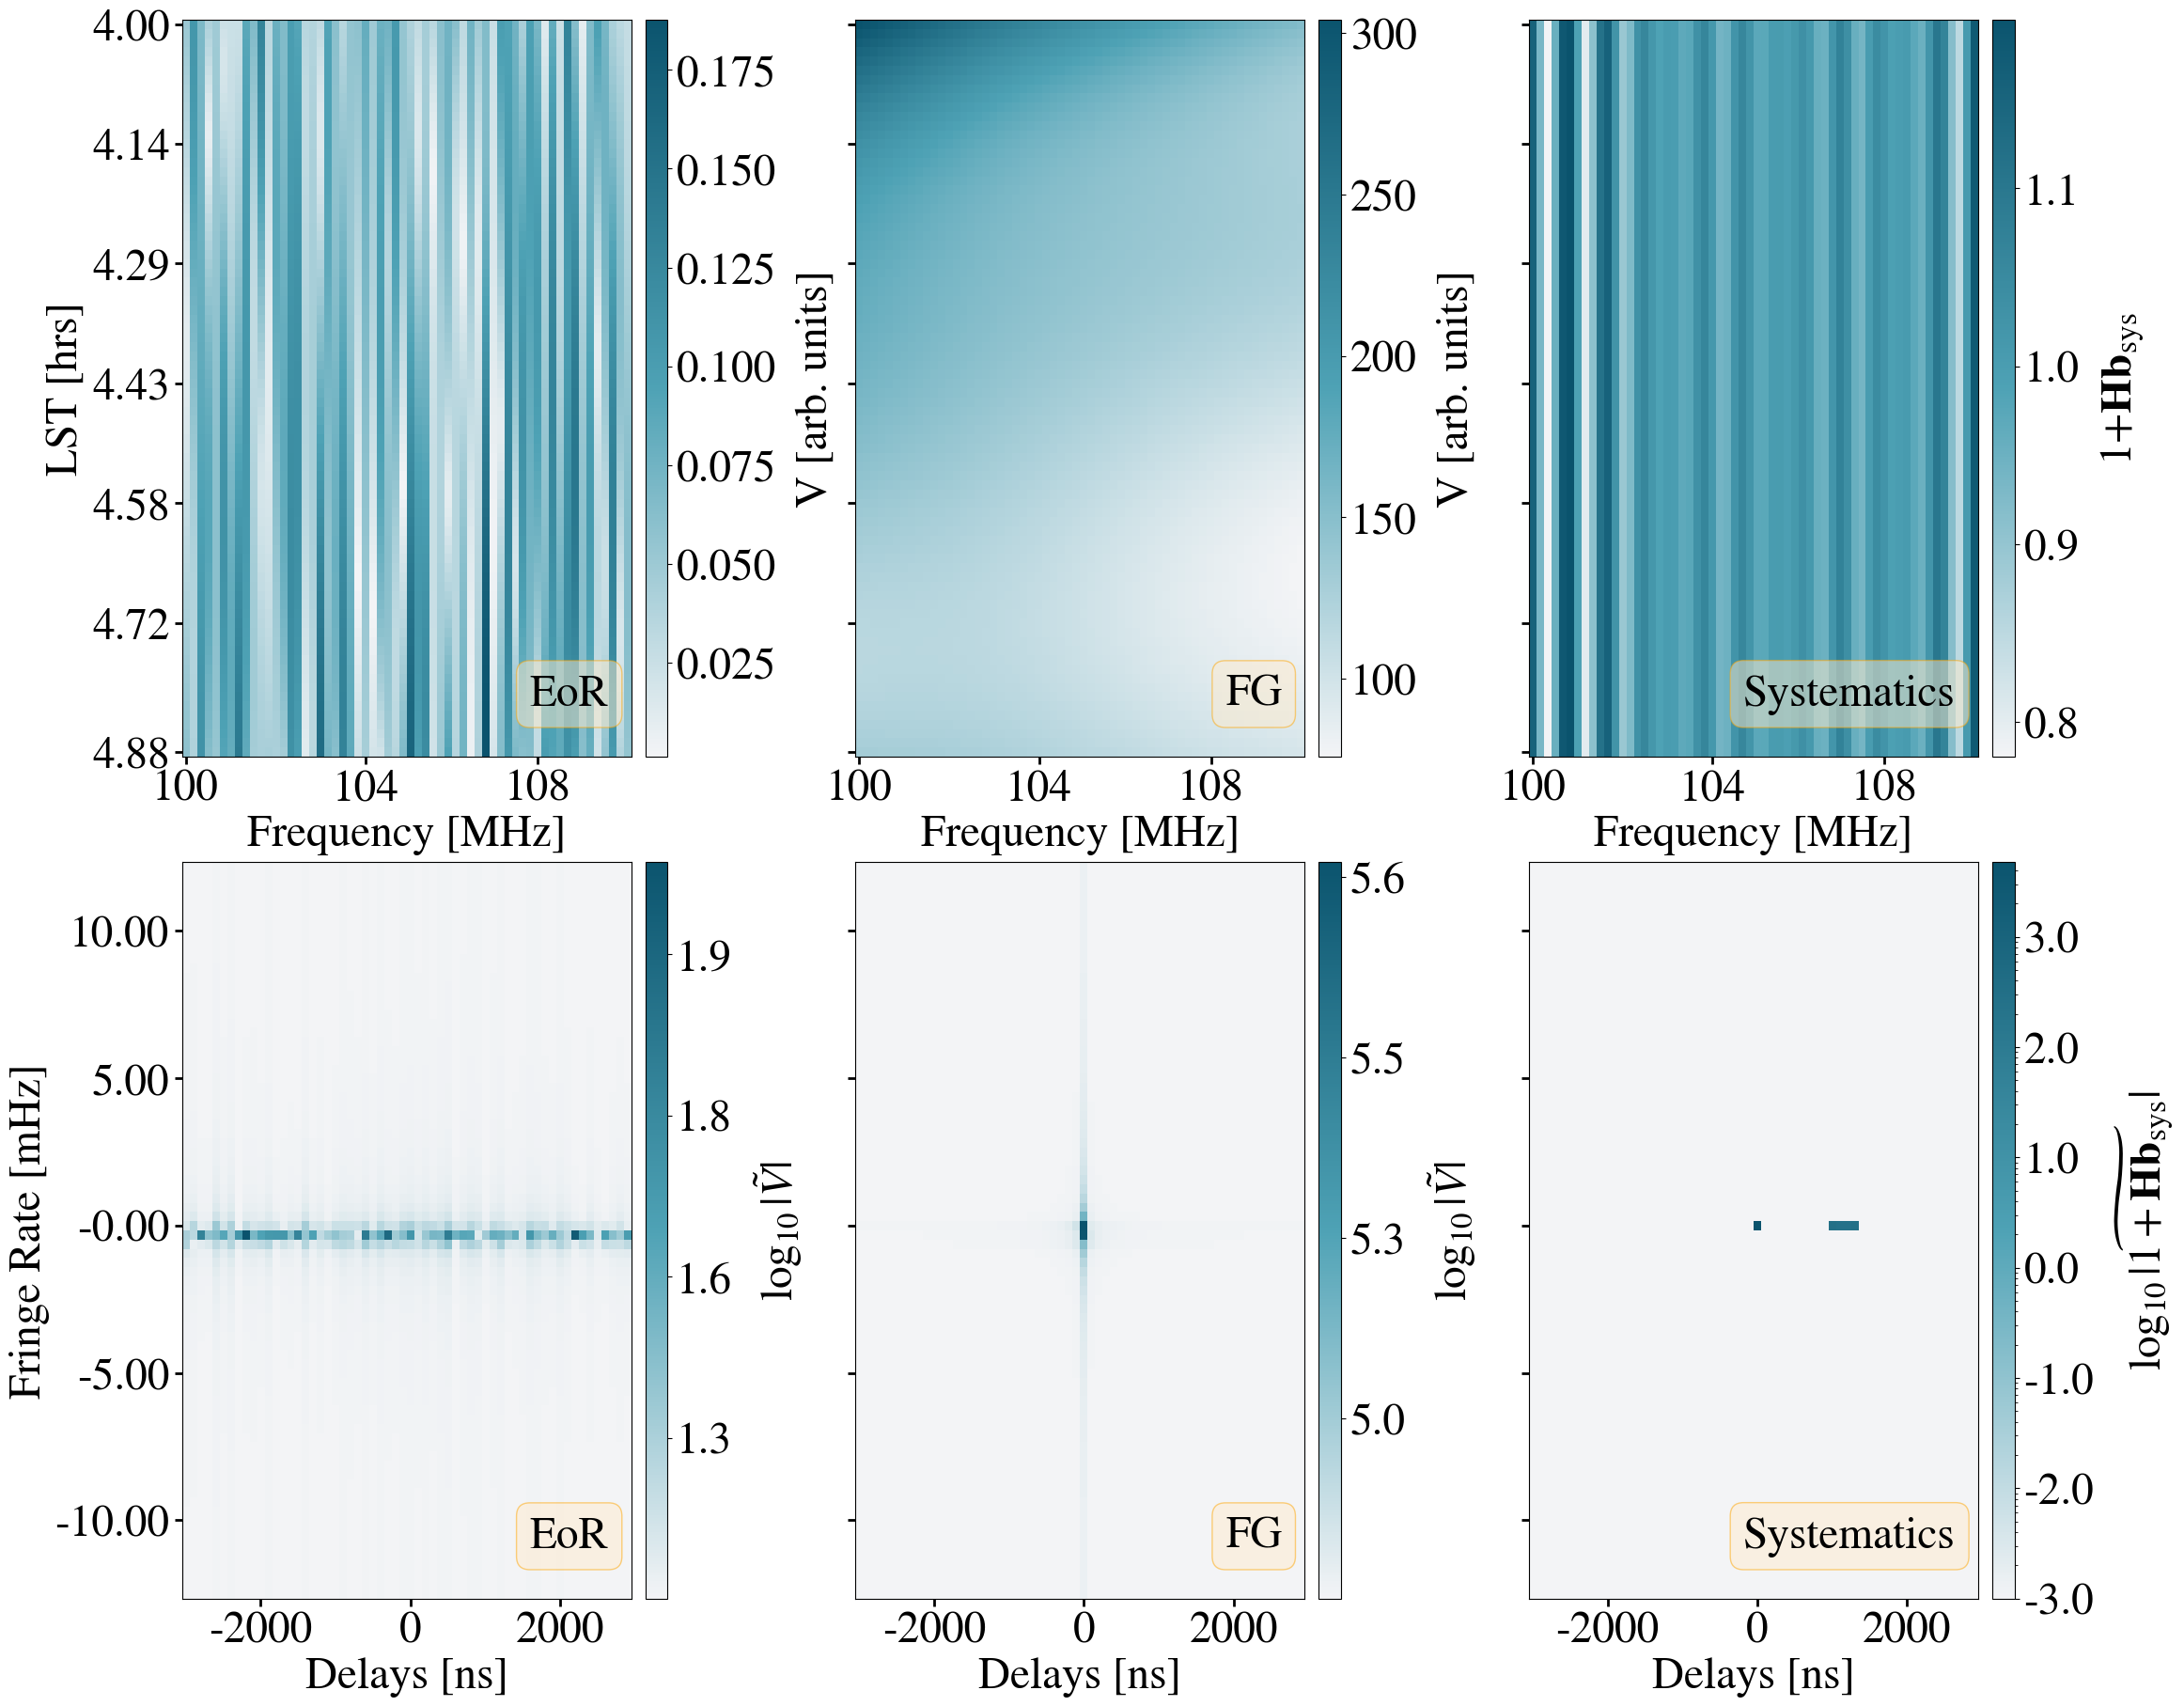

In [14]:
fig = plt.figure(figsize=(25., 28.))

grid_kwargs = dict(
    nrows_ncols = (1, 3),
    axes_pad    = 2.0,
    cbar_mode   = 'each',
    cbar_pad    = 0.15,
    cbar_size   = '5%',
    label_mode  = 'L',        # y-labels only on leftmost panel — avoids colorbar collision
    aspect      = False,
)

axs_top = ImageGrid(fig, rect=(0.06, 0.38, 0.78, 0.28), **grid_kwargs)
axs_bot = ImageGrid(fig, rect=(0.06, 0.06, 0.78, 0.28), **grid_kwargs)

cbar_labels_top = [r'V [arb. units]', r'V [arb. units]', r'1+$\mathbf{Hb}_\text{sys}$']
cbar_labels_bot = [r'$\log_{10}|\tilde{V}|$', r'$\log_{10}|\tilde{V}|$',
                   r'$\log_{10}|\widetilde{1+\mathbf{Hb}}_\text{sys}|$']

# --- Plot top row ---
data_top = [eor_true, fg_true, 1 + delta_g_true]
for ax, cbar_ax, label in zip(axs_top, axs_top.cbar_axes, cbar_labels_top):
    im = ax.imshow(np.abs(data_top.pop(0)), cmap=paper_map_blue, aspect='auto')
    cbar = plt.colorbar(im, cax=cbar_ax)
    cbar.set_label(label, fontsize=34, labelpad=15)
    cbar.ax.tick_params(which='both', color='black', labelcolor='black')
    ax.tick_params(direction='out', length=6, width=2, colors='black')

# --- Plot bottom row ---
data_bot = [dlfr_sys(eor_true), dlfr_sys(fg_true), dlfr_ones + delta_g_dlfr_true]
for i, (ax, cbar_ax, label) in enumerate(zip(axs_bot, axs_bot.cbar_axes, cbar_labels_bot)):
    im = ax.imshow(np.abs(data_bot.pop(0)), aspect='auto', cmap=paper_map_blue)
    if i == 2:
        vmin, vmax = im.get_clim()
        im.set_norm(mcolors.LogNorm(vmin=max(vmin, 1e-3), vmax=vmax))
    cbar = plt.colorbar(im, cax=cbar_ax)
    cbar.set_label(label, fontsize=34, labelpad=15)
    cbar.ax.yaxis.set_major_formatter(log10_formatter)
    cbar.ax.tick_params(which='both', color='black', labelcolor='black')
    ax.tick_params(direction='out', length=6, width=2, colors='black')

# --- Ticks top ---
for ax in axs_top:
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    ax.set_xticks(xticklocs_freq, labels=xticklabels_freqs)
    ax.set_yticks(yticklocs_time[::-1], labels=yticklabels_times[::-1])
    ax.set_xlim(x0, x1)        # restore — pixel-index ticks expand limits without this
    ax.set_ylim(y0, y1)
    ax.set_xlabel("Frequency [MHz]")

# --- Ticks bottom ---
for ax in axs_bot:
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    ax.set_xticks(xticklocs_dl, labels=xticklabels_dl)
    ax.set_yticks(yticklocs_fr, labels=yticklabels_fr)
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)
    ax.invert_yaxis()
    ax.set_xlabel("Delays [ns]")

axs_top[0].set_ylabel("LST [hrs]")
axs_bot[0].set_ylabel("Fringe Rate [mHz]")

bbox_labels = ['EoR', 'FG', 'Systematics']
for ax, label in zip(axs_top, bbox_labels):
    ax.text(0.95, 0.07, label, bbox=bbox, transform=ax.transAxes, horizontalalignment='right')
for ax, label in zip(axs_bot, bbox_labels):
    ax.text(0.95, 0.07, label, bbox=bbox, transform=ax.transAxes, horizontalalignment='right')

save_fig('data_components_nfg.pdf')
print("Data components, (1/9)")

---
# Figure 2: Input and recovered data in delay–fringe-rate space → `data_in_dlfr_nfg.pdf`

The `paper_plots_c_v2.ipynb` version of this figure showed the true data once
per case, which distinguished the cases because they had different
systematic-mode locations.  Here the true data is identical for every case, so
the first two panels show the shared inputs (true sky, true data) and the
remaining panels show the **mean recovered data model**
$\langle (1 + \mathbf{Hb}_\mathrm{sys})(\mathrm{EoR} + \mathrm{FG})\rangle$ for
each `Nfgmodes`.

  saved /nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures/nfgmodes/data_in_dlfr_nfg.pdf
Data in delay-fringe-rate space, (2/9)


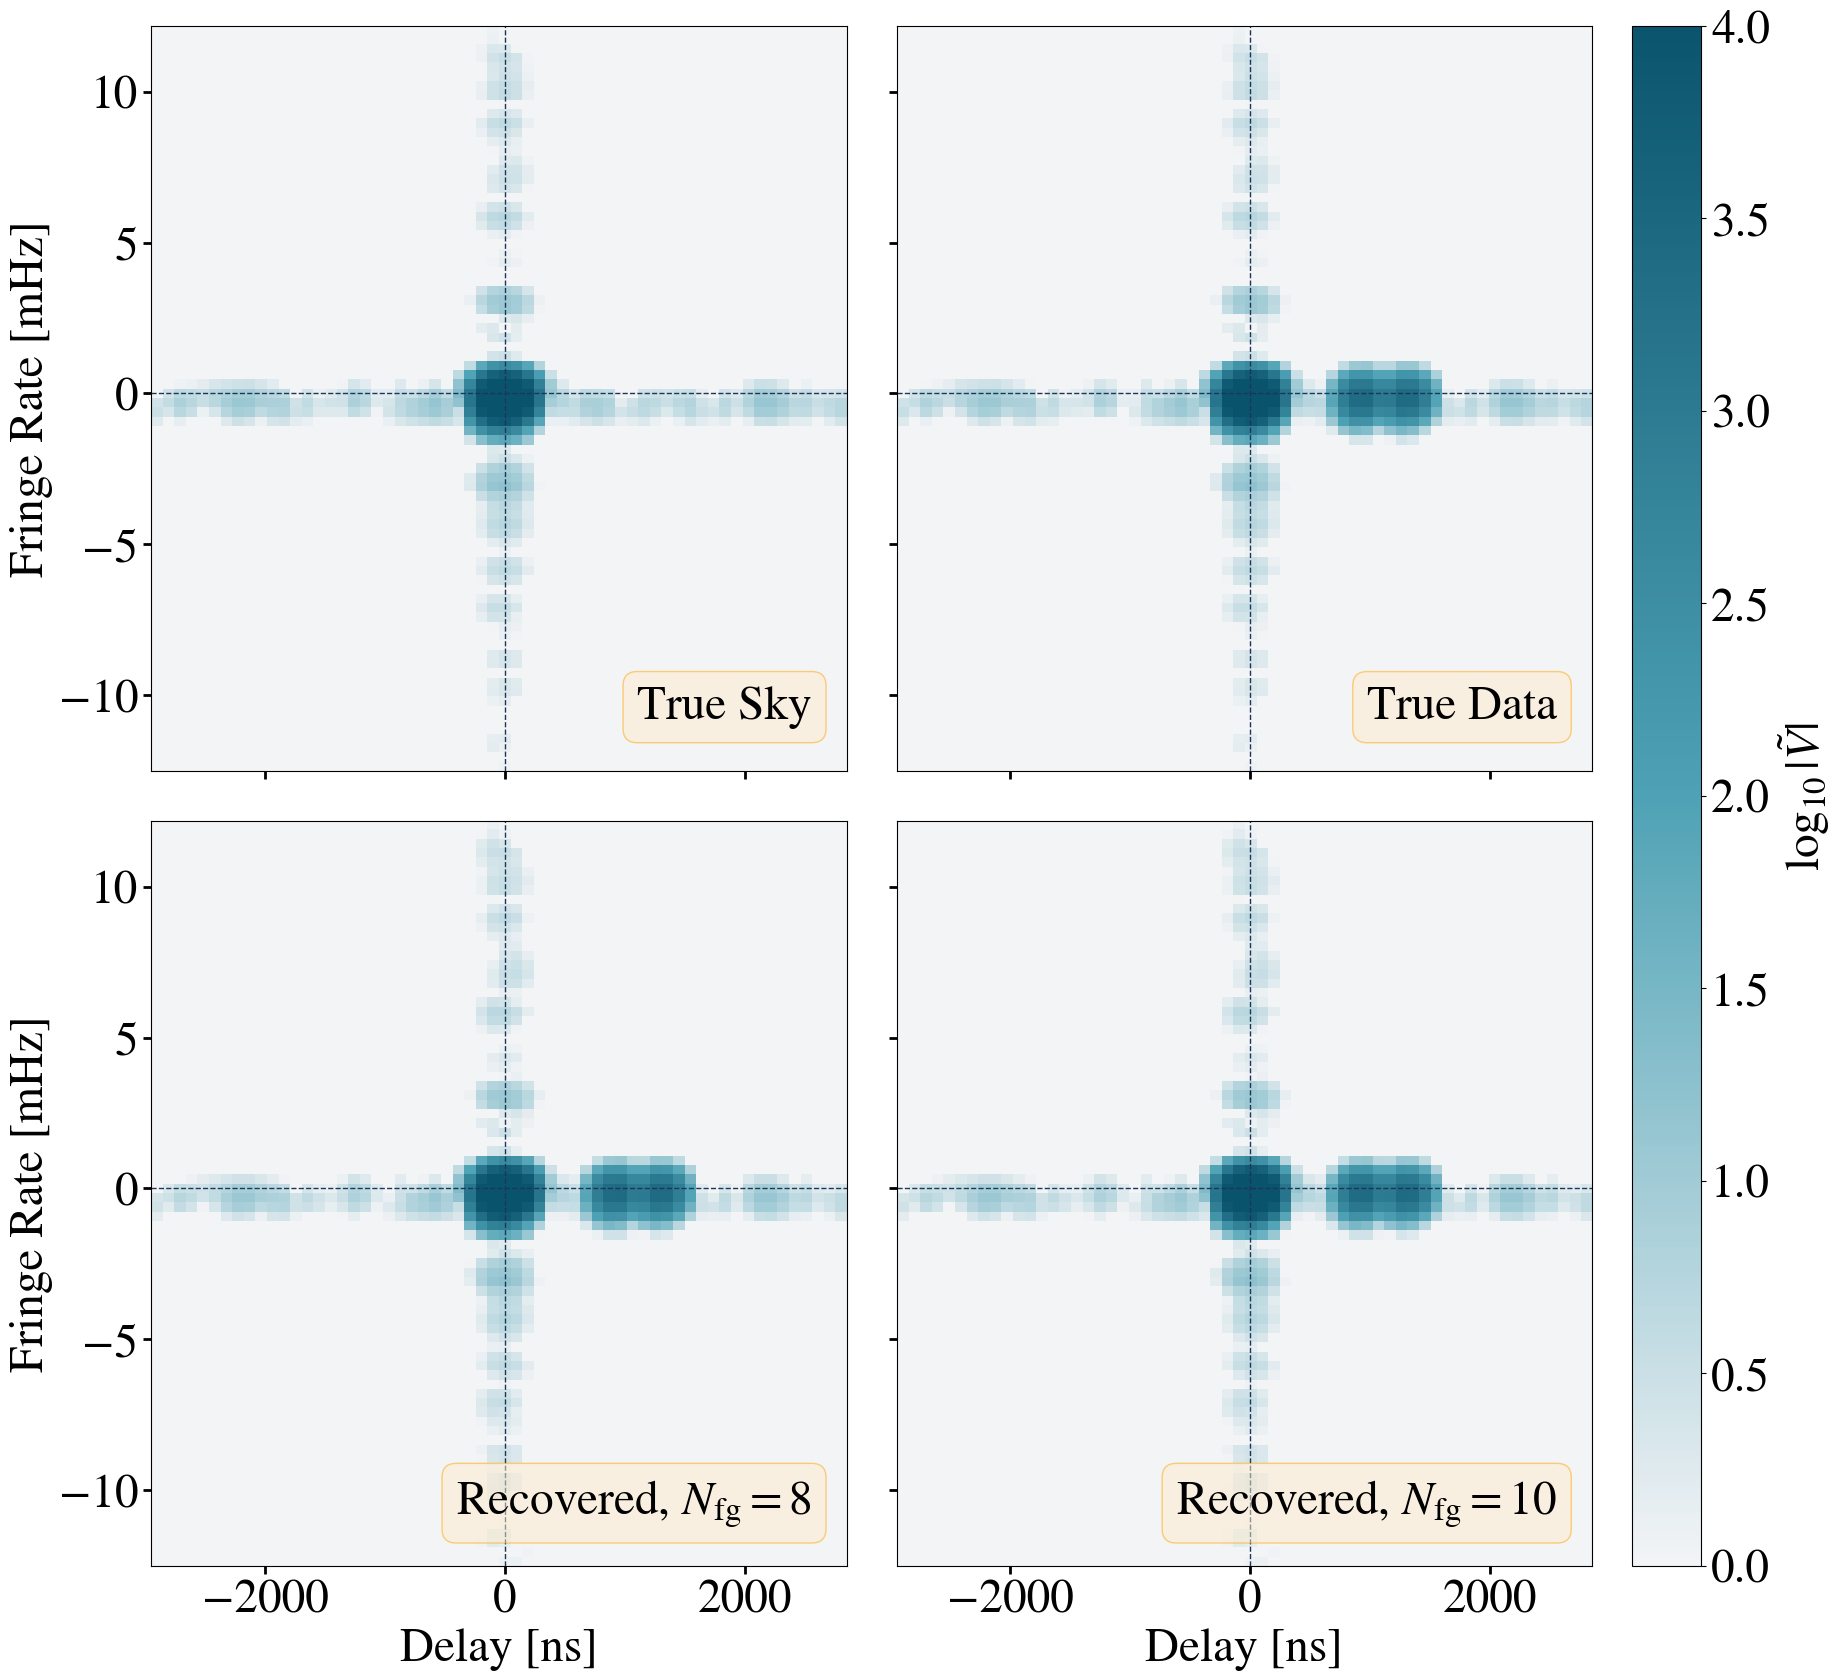

In [15]:
panels = (
    [('True Sky', sky_true_dlfr), ('True Data', data_true_dlfr)]
    + [(f'Recovered, {case_labels[i]}', mean_data_dlfr_all[i]) for i in range(Ncases)]
)

npanels = len(panels)
ncols   = 2 if npanels <= 4 else 3
nrows   = int(np.ceil(npanels / ncols))

fig = plt.figure(figsize=(10. * ncols, 10. * nrows))
axs = ImageGrid(
    fig, 111,
    nrows_ncols=(nrows, ncols),
    axes_pad=0.5,
    cbar_mode='single',
    cbar_location='right',
    cbar_pad=0.4,
    label_mode='L',
    aspect=False,
)

plot_op = None
for k, (label, data_dlfr_k) in enumerate(panels):
    plot_op = plot_waterfalls_from_dlfr(
        data_dlfr_k, freqs * 1e6, times_jd[:Ntimes], fig=fig, ax=axs[k], mode='log',
        vmin=0, vmax=4, cmap=paper_map_blue, dynamic_range=5, limit_drng='all',
        colorbar_flag=False, baseline=None, horizon_color='magenta',
    )
    axs[k].text(0.95, 0.07, label, bbox=bbox, transform=axs[k].transAxes,
                horizontalalignment='right')
    axs[k].invert_yaxis()   # flip so -ve fringe rates at the bottom
    axs[k].axvline(0, color=colors[0], linestyle='--', linewidth=1)
    axs[k].axhline(0, color=colors[0], linestyle='--', linewidth=1)

for k in range(npanels, nrows * ncols):
    axs[k].set_axis_off()

axs.cbar_axes[0].colorbar(plot_op, label=r'$\log_{10}|\tilde{V}|$')

save_fig('data_in_dlfr_nfg.pdf')
print("Data in delay-fringe-rate space, (2/9)")

---
# Figure 3: Sky result waterfalls (all cases) → `result_waterfalls_nfg.pdf`

Columns = `Nfgmodes` case; rows = True / mean / std / residual sky in
delay–fringe-rate space.  The top row is the same in every column (the true sky
is shared) and is kept as a visual reference for the rows below.

  saved /nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures/nfgmodes/result_waterfalls_nfg.pdf
Sky result waterfalls (all cases), (3/9)


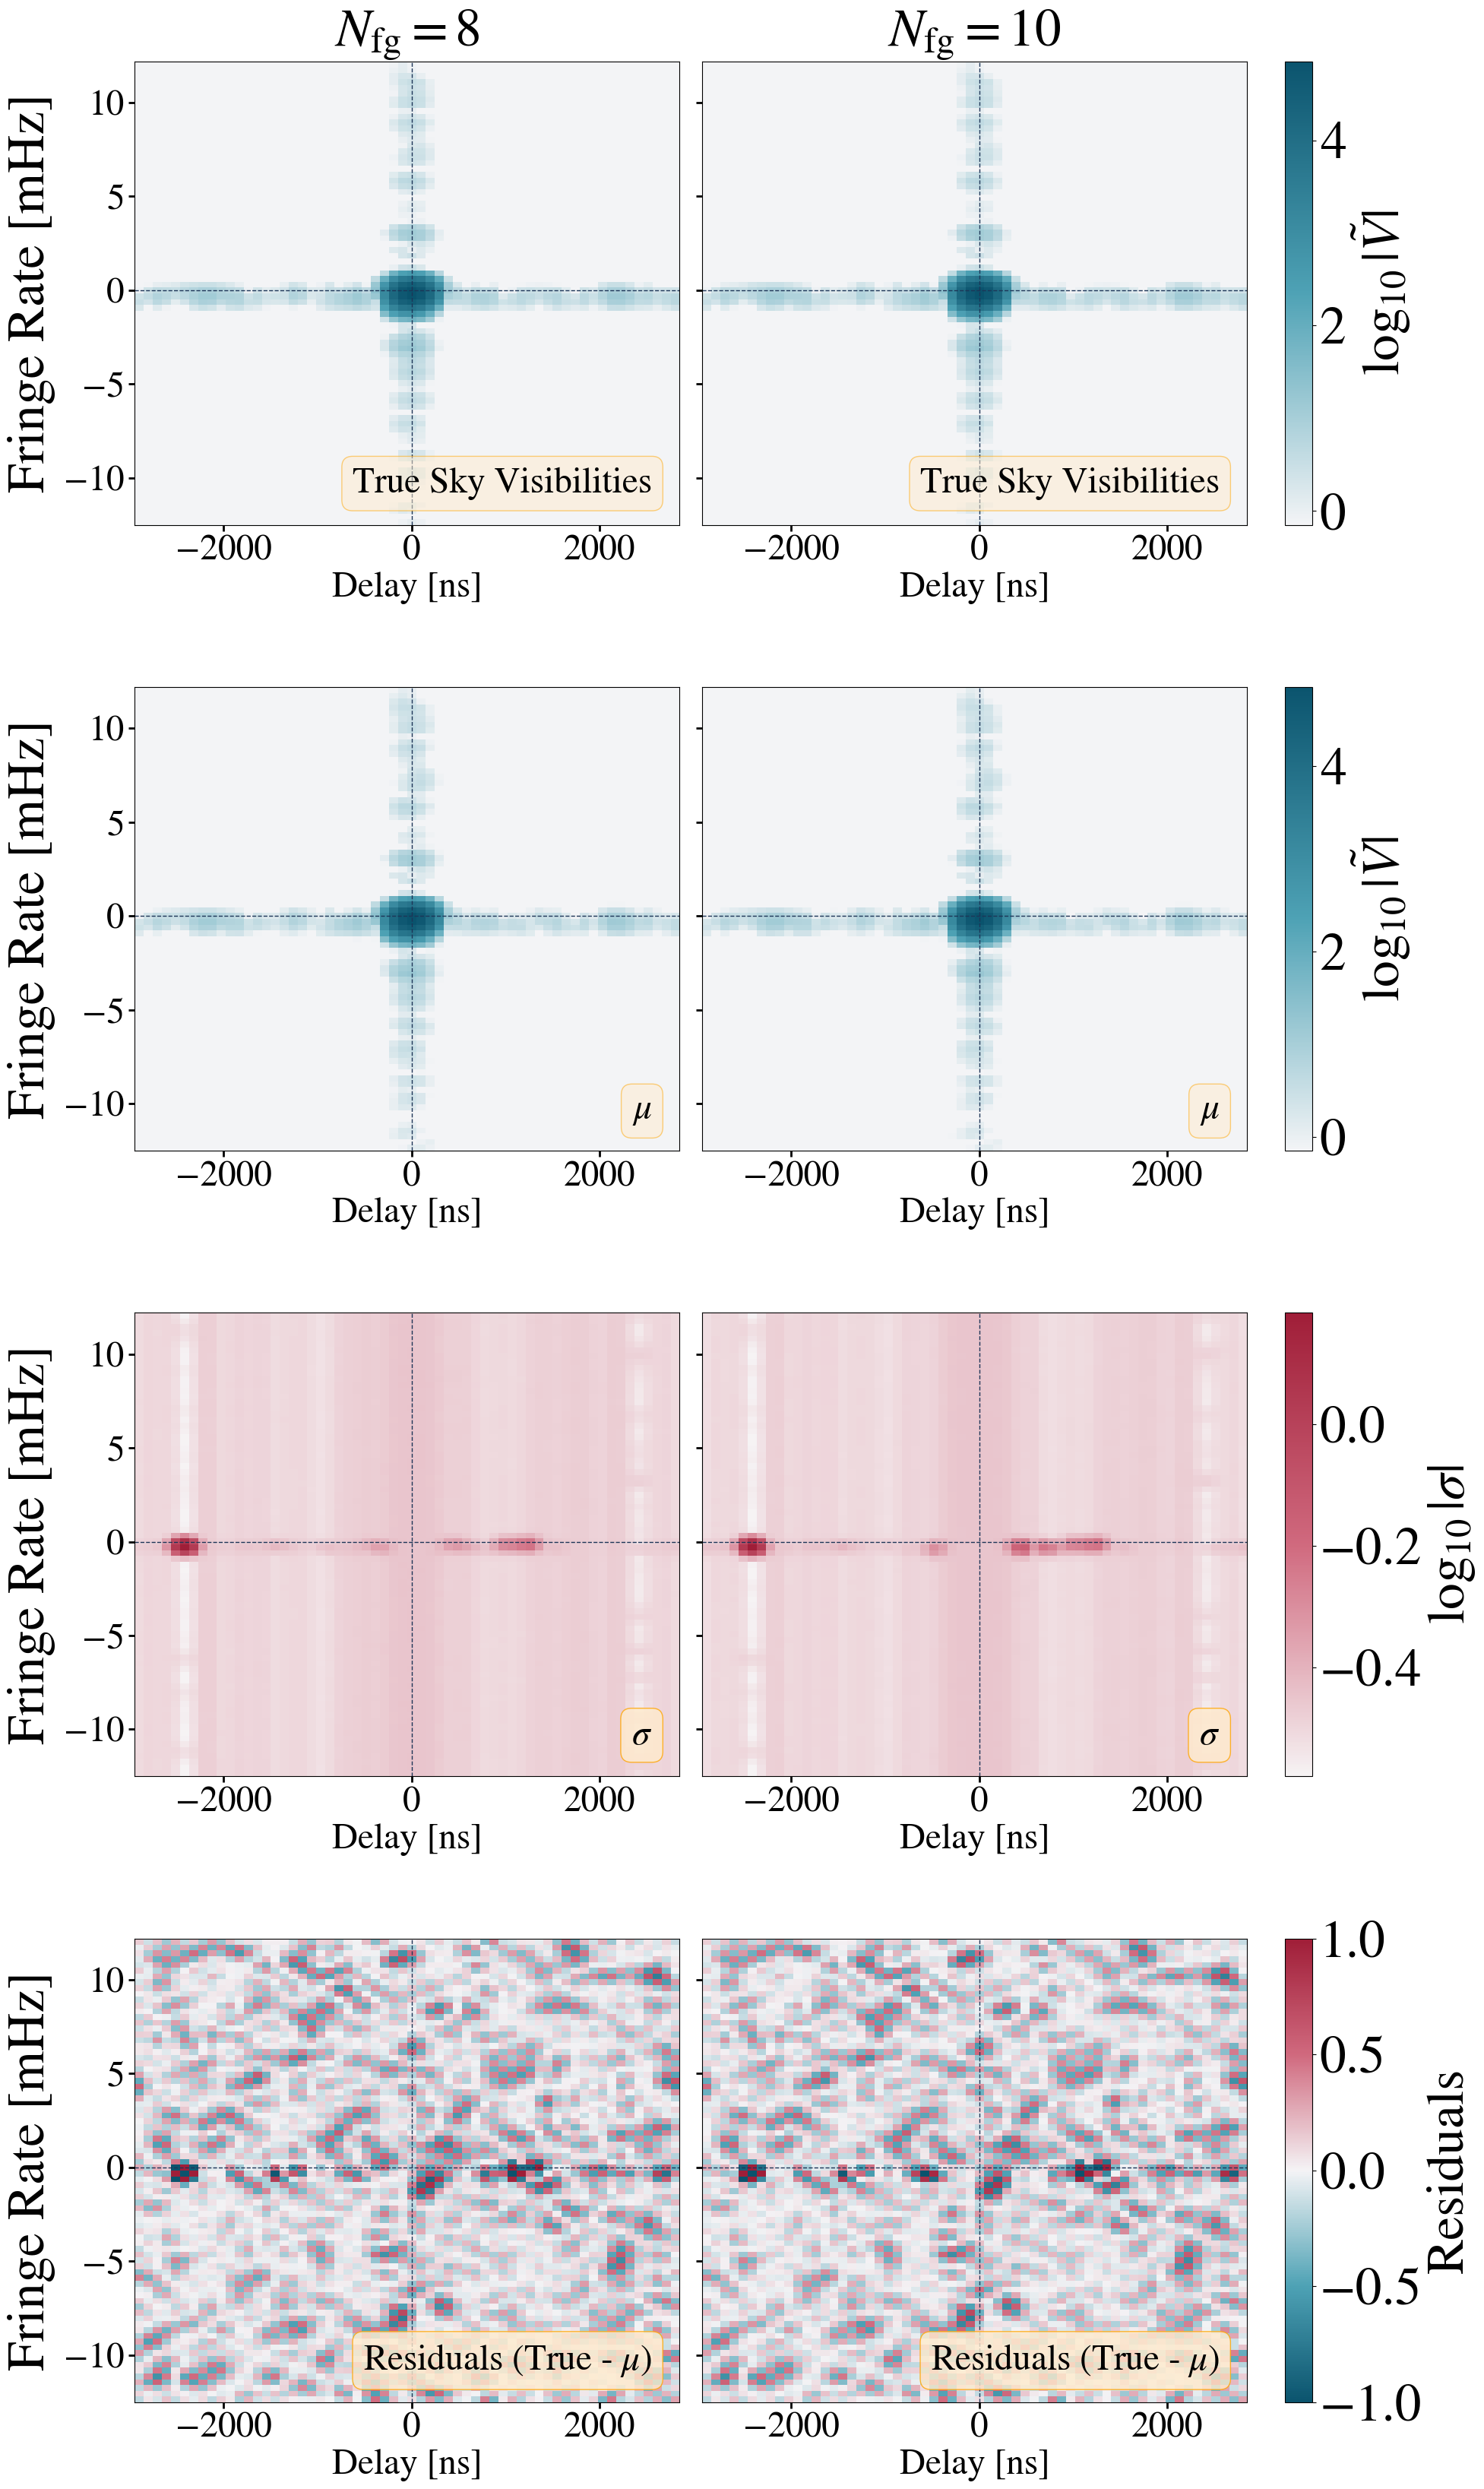

In [16]:
row_labels    = ['Fringe Rate [mHz]'] * 4
annots_sky    = ['True Sky Visibilities', r'$\mu$', r'$\sigma$', r'Residuals (True - $\mu$)']

fig_sky = plt.figure(figsize=(10. * Ncases, 40.))
outer_gs = gridspec.GridSpec(4, 1, figure=fig_sky, hspace=0.35)

grids = []
for row in range(4):
    grid = ImageGrid(
        fig_sky, outer_gs[row],
        nrows_ncols=(1, Ncases),
        axes_pad=0.3,
        share_all=True,
        cbar_location='right',
        cbar_mode='single',
        cbar_size='5%',
        cbar_pad=0.5,
        aspect=False,
    )
    grids.append(grid)

cmap_list  = [paper_map_blue, paper_map_blue, paper_map_pink, paper_map]
mode_list  = ['log', 'log', 'log', 'real']
vmin_list  = [None, None, None, -1]
vmax_list  = [None, None, None,  1]
cbar_labels = [
    r'$\log_{10}|\tilde{V}|$',
    r'$\log_{10}|\tilde{V}|$',
    r'$\log_{10}|\sigma|$',
    'Residuals',
]
data_all = [
    sky_true_dlfr_all,
    mean_sky_dlfr_all,
    std_sky_dlfr_all,
    res_sky_dlfr_all,
]

for row, grid in enumerate(grids):
    im = None
    for col in range(Ncases):
        im = plot_waterfalls_from_dlfr(
            data_all[row][col], freqs * 1e6, times_jd[:Ntimes],
            fig=fig_sky, ax=grid[col],
            mode=mode_list[row],
            vmin=vmin_list[row], vmax=vmax_list[row],
            cmap=cmap_list[row], dynamic_range=5 if row < 2 else None,
            limit_drng='all', colorbar_flag=False,
            baseline=None, horizon_color='magenta',
        )
        # Crosshairs
        grid[col].axvline(0, color=colors[0], linestyle='--', linewidth=1)
        grid[col].axhline(0, color=colors[0], linestyle='--', linewidth=1)

        bbox_use = bbox_res if row >= 2 else bbox
        grid[col].text(
            0.95, 0.07, annots_sky[row], bbox=bbox_use,
            transform=grid[col].transAxes, ha='right',
        )
        grid[col].invert_yaxis()   # flip so -ve fringe rates at the bottom
        if row == 0:
            grid[col].set_title(case_labels[col], fontsize=50, pad=15)

    cbar = grid.cbar_axes[0].colorbar(im, pad=15)
    cbar.set_label(cbar_labels[row], fontsize=50)
    grid.cbar_axes[0].tick_params(labelsize=50)

    grid[0].set_ylabel(row_labels[row], fontsize=50, labelpad=8)

save_fig('result_waterfalls_nfg.pdf')
print("Sky result waterfalls (all cases), (3/9)")

---
# Figure 4: Systematics result waterfalls (all cases) → `sys_result_dlfr_waterfalls_nfg.pdf`

Recovery of $\mathbf{Hb}_\mathrm{sys}$ for each `Nfgmodes`.  Because all cases
share the same systematic modes, differences between columns are entirely due
to how the foreground model soaks up (or fails to soak up) power at the
systematic delays.

  saved /nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures/nfgmodes/sys_result_dlfr_waterfalls_nfg.pdf
Systematics result waterfalls (all cases), (4/9)


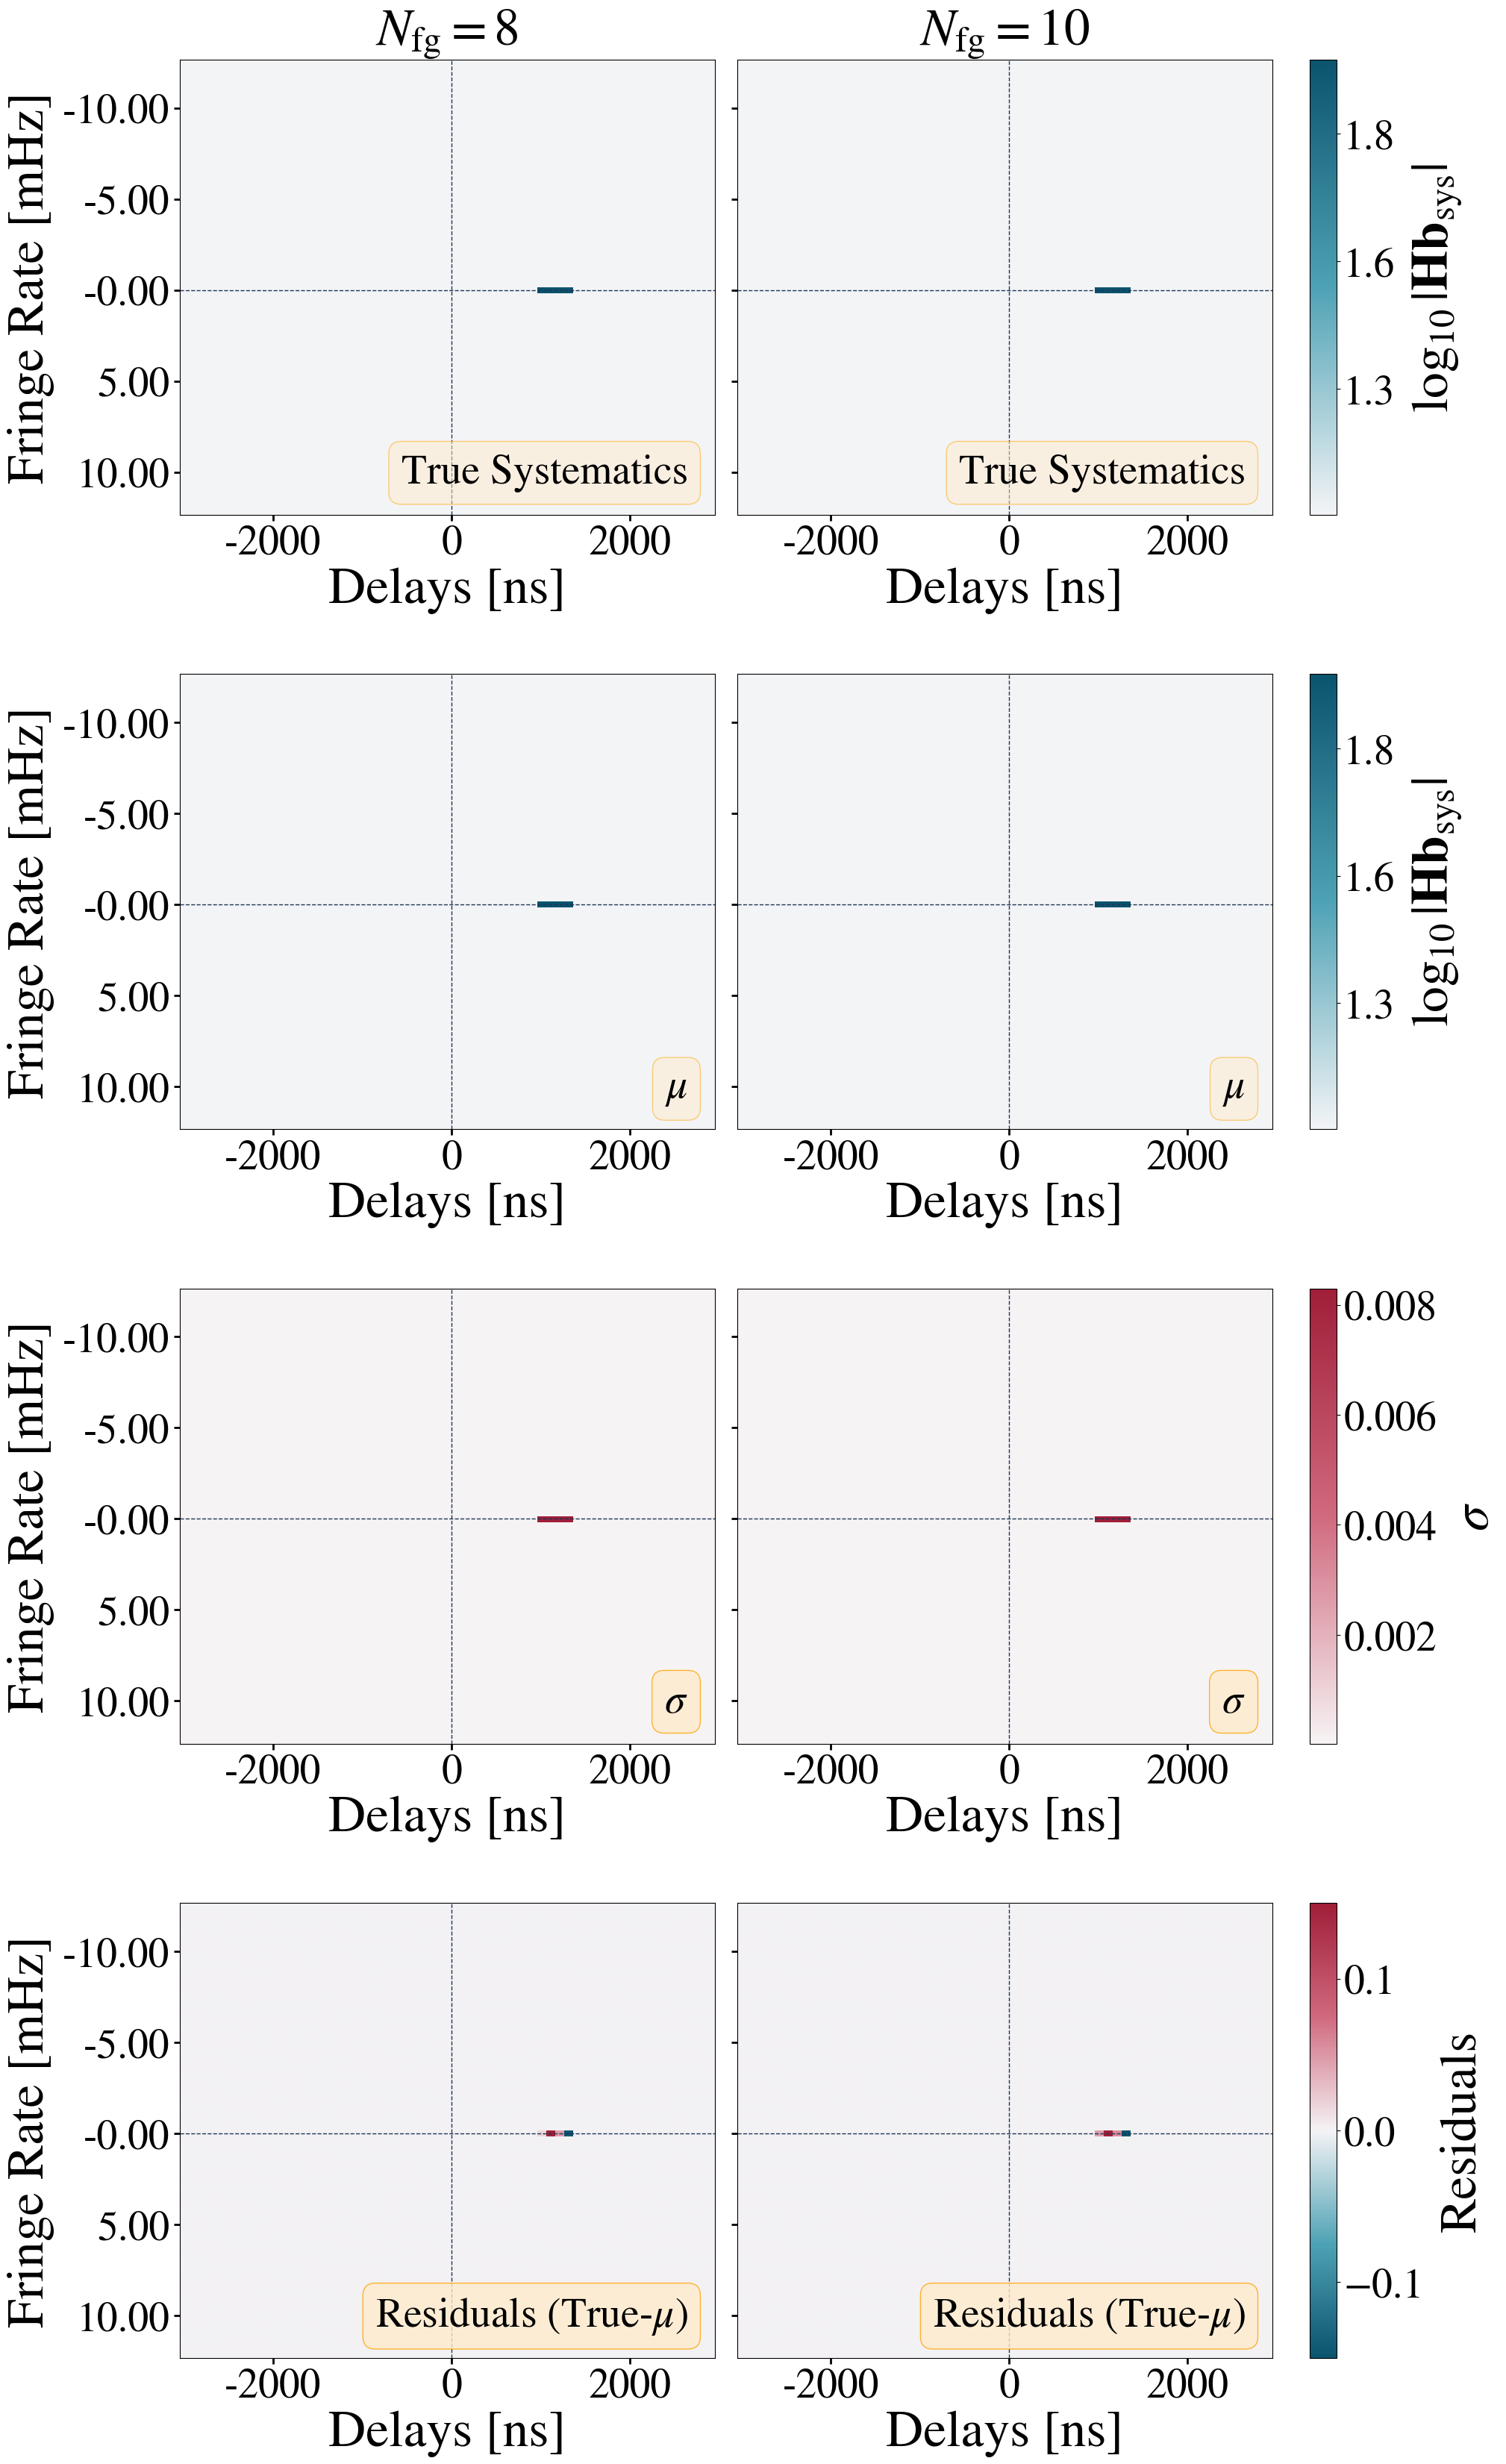

In [17]:
annots_sys = [
    'True Systematics',
    r'$\mu$',
    r'$\sigma$',
    'Residuals (True-' + r'$\mu$' + ')',
]

fig_sys = plt.figure(figsize=(10. * Ncases, 40.))
outer_gs = gridspec.GridSpec(4, 1, figure=fig_sys, hspace=0.35)

grids = []
for row in range(4):
    grid = ImageGrid(
        fig_sys, outer_gs[row],
        nrows_ncols=(1, Ncases),
        axes_pad=0.3,
        share_all=True,
        cbar_location='right',
        cbar_mode='single',
        cbar_size='5%',
        cbar_pad=0.5,
        aspect=False,
    )
    grids.append(grid)

cmap_list  = [paper_map_blue, paper_map_blue, paper_map_pink, paper_map]
mode_list  = ['abs', 'abs', 'abs', 'real']
vmin_list  = [None, None, None, -0.15]
vmax_list  = [None, None, None,  0.15]
cbar_labels = [
    r'$\log_{10}|\mathbf{Hb}_\mathrm{sys}|$',
    r'$\log_{10}|\mathbf{Hb}_\mathrm{sys}$|',
    r'$\sigma$',
    'Residuals',
]
data_all = [
    delta_g_dlfr_true_all,
    delta_g_dlfr_mean_all,
    delta_g_dlfr_std_all,
    [delta_g_dlfr_true_all[c] - delta_g_dlfr_mean_all[c] for c in range(Ncases)],
]

for row, grid in enumerate(grids):
    cmap = cmap_list[row]
    mode = mode_list[row]

    # --- Per-row data transform ---
    if mode == 'real':
        row_data = [np.real(data_all[row][col]) for col in range(Ncases)]
    else:
        row_data = [np.abs(data_all[row][col]) for col in range(Ncases)]

    # --- Per-row shared vmin/vmax ---
    if vmin_list[row] is None or vmax_list[row] is None:
        all_vals = np.concatenate([d.ravel() for d in row_data])
        vmin = all_vals.mean() - 0.25 * np.abs(all_vals.min()) if vmin_list[row] is None else vmin_list[row]
        vmax = all_vals.mean() + 0.25 * np.abs(all_vals.max()) if vmax_list[row] is None else vmax_list[row]
    else:
        vmin = vmin_list[row]
        vmax = vmax_list[row]

    im = None
    for col in range(Ncases):
        im = grid[col].imshow(
            row_data[col],
            aspect='auto',
            cmap=cmap, vmin=vmin, vmax=vmax,
        )
        grid[col].invert_yaxis()
        grid[col].tick_params(direction='out', length=6, width=2, colors='black', labelsize=40)
        x0, x1 = grid[col].get_xlim()
        y0, y1 = grid[col].get_ylim()
        grid[col].set_xticks(xticklocs_dl, labels=xticklabels_dl)
        grid[col].set_yticks(yticklocs_fr, labels=yticklabels_fr)
        grid[col].set_xlim(x0, x1)
        grid[col].set_ylim(y0, y1)
        grid[col].axvline(dl_zero, color=colors[0], linestyle='--', linewidth=1)
        grid[col].axhline(fr_zero, color=colors[0], linestyle='--', linewidth=1)

        bbox_use = bbox_res if row >= 2 else bbox
        grid[col].text(
            0.95, 0.07, annots_sys[row], bbox=bbox_use,
            transform=grid[col].transAxes, ha='right', fontsize=40,
        )
        if row == 0:
            grid[col].set_title(case_labels[col], fontsize=50, pad=15)
        grid[col].set_xlabel('Delays [ns]', fontsize=50)

    cbar = grid.cbar_axes[0].colorbar(im)
    cbar.set_label(cbar_labels[row], fontsize=50, labelpad=15)
    if row < 2:
        cbar.ax.yaxis.set_major_formatter(log10_formatter)
    cbar.ax.tick_params(which='both', color='black', labelcolor='black', labelsize=40)

    grid[0].set_ylabel(row_labels[row], fontsize=50, labelpad=8)

save_fig('sys_result_dlfr_waterfalls_nfg.pdf')
print("Systematics result waterfalls (all cases), (4/9)")

---
# Figure 5: Component power spectra and EoR residuals → `errors_components_nfg.pdf`

Top: the true EoR and noise delay power spectra with, for each `Nfgmodes`, the
sample-mean EoR and EoR+FG spectra.
Bottom: the EoR residual in units of the sample scatter,
$(P_\mathrm{true} - P_\mathrm{sample}) / \sigma_\mathrm{samples}$, averaged over
samples.  Unlike `paper_plots_c_v2.ipynb`, $\sigma_\mathrm{samples}$ is taken
**per delay bin** rather than as a single global scalar, which is what the axis
label describes.  The delay bins covered by the foreground wedge (`rm`) are
dropped.

  saved /nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures/nfgmodes/errors_components_nfg.pdf
Component errors (all cases), (5/9)


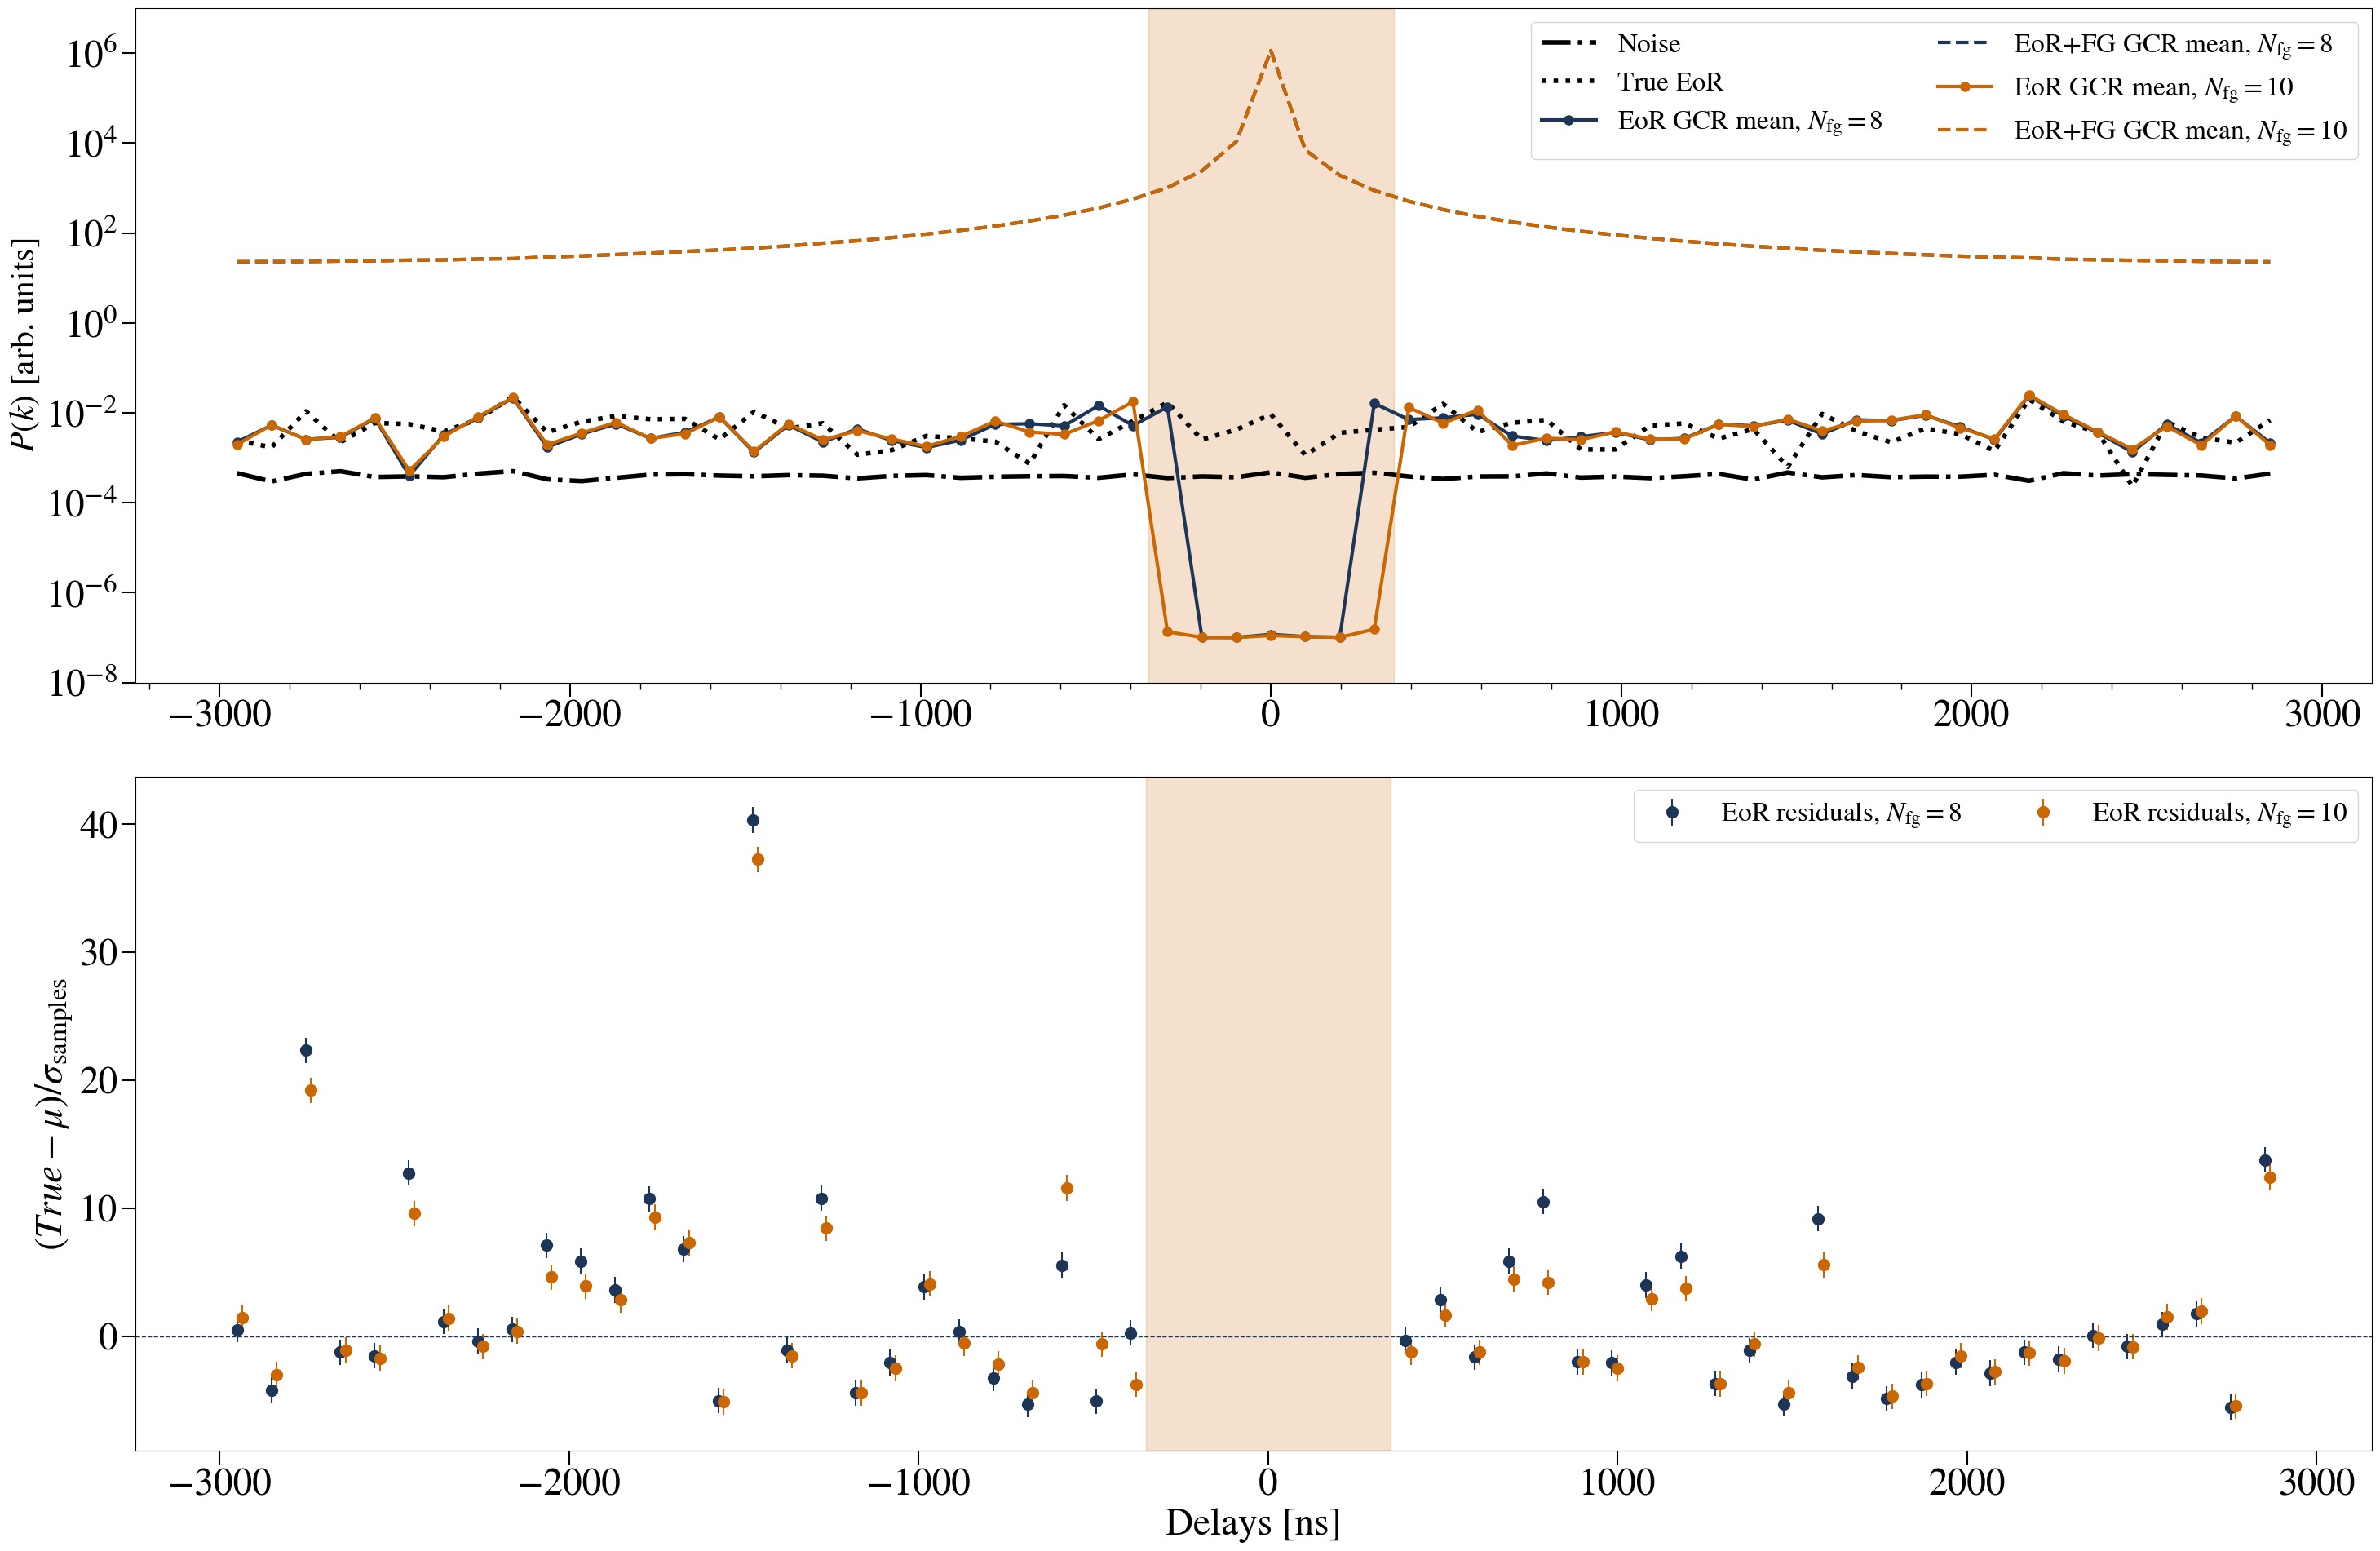

In [18]:
fig, axs = plt.subplots(2, 1, figsize=(30, 20))

rm   = np.arange(27, 34)
keep = np.ones(Nfreqs, dtype=bool)
keep[rm] = False

# --------------- top plot ----------------
axs[0].set_yscale('log')
axs[0].plot(delays, n_pspec,        ls='-.',    c='k', label='Noise',    lw=4)
axs[0].plot(delays, eor_pspec_true, ls='dotted', c='k', label='True EoR', lw=4)
for i in range(Ncases):
    axs[0].plot(delays, ps_sample_all[i].mean(axis=0), marker='o', ms=8, c=case_colors[i],
                label=f'EoR GCR mean, {case_labels[i]}', lw=3)
    axs[0].plot(delays, ps_sky_mean_all[i], ls='--', c=case_colors[i],
                label=f'EoR+FG GCR mean, {case_labels[i]}', lw=3)
axs[0].legend(fontsize=24, ncol=2)
axs[0].set_ylim(1e-8, 1e7)
axs[0].axvspan(-350, 350, facecolor=colors[1], ec=colors[1], alpha=0.2, zorder=0.1)
axs[0].set_ylabel(r'$P(k)$ [arb. units]', fontsize=30)
axs[0].minorticks_on()
axs[0].tick_params(which='major', direction='out', length=12, width=1.5)
axs[0].tick_params(which='minor', direction='out', length=6,  width=1.0)

# --------------- bottom plot ----------------
for i in range(Ncases):
    z_i = (eor_pspec_true - ps_sample_all[i]) / np.std(ps_sample_all[i], axis=0)
    axs[1].errorbar(
        delays[keep].value + i * 15, z_i.mean(axis=0)[keep], yerr=np.ones(keep.sum()),
        fmt='o', color=case_colors[i], label=f'EoR residuals, {case_labels[i]}', markersize=10,
    )
axs[1].legend(fontsize=24, ncol=Ncases)
axs[1].axhline(0, color=colors[0], linestyle='--', linewidth=1)
axs[1].axvspan(-350, 350, facecolor=colors[1], ec=colors[1], alpha=0.2, zorder=0.1)
axs[1].set_xlabel('Delays [ns]')
axs[1].set_ylabel(r'$(True - \mu)/ \sigma_\text{samples}$')
axs[1].minorticks_on()
axs[1].tick_params(which='major', direction='out', length=12, width=1.5)
axs[1].tick_params(which='minor', direction='out', length=0)

plt.tight_layout()
save_fig('errors_components_nfg.pdf')
print("Component errors (all cases), (5/9)")

---
# Figure 6: Corner plot of $b_\mathrm{sys}$ → `bsys_corner_plot_nfg.pdf`

All cases overplotted.  The red truth lines are drawn once (the true systematic
amplitudes are shared).

  saved /nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures/nfgmodes/bsys_corner_plot_nfg.pdf
Corner plot of b_sys, (6/9)


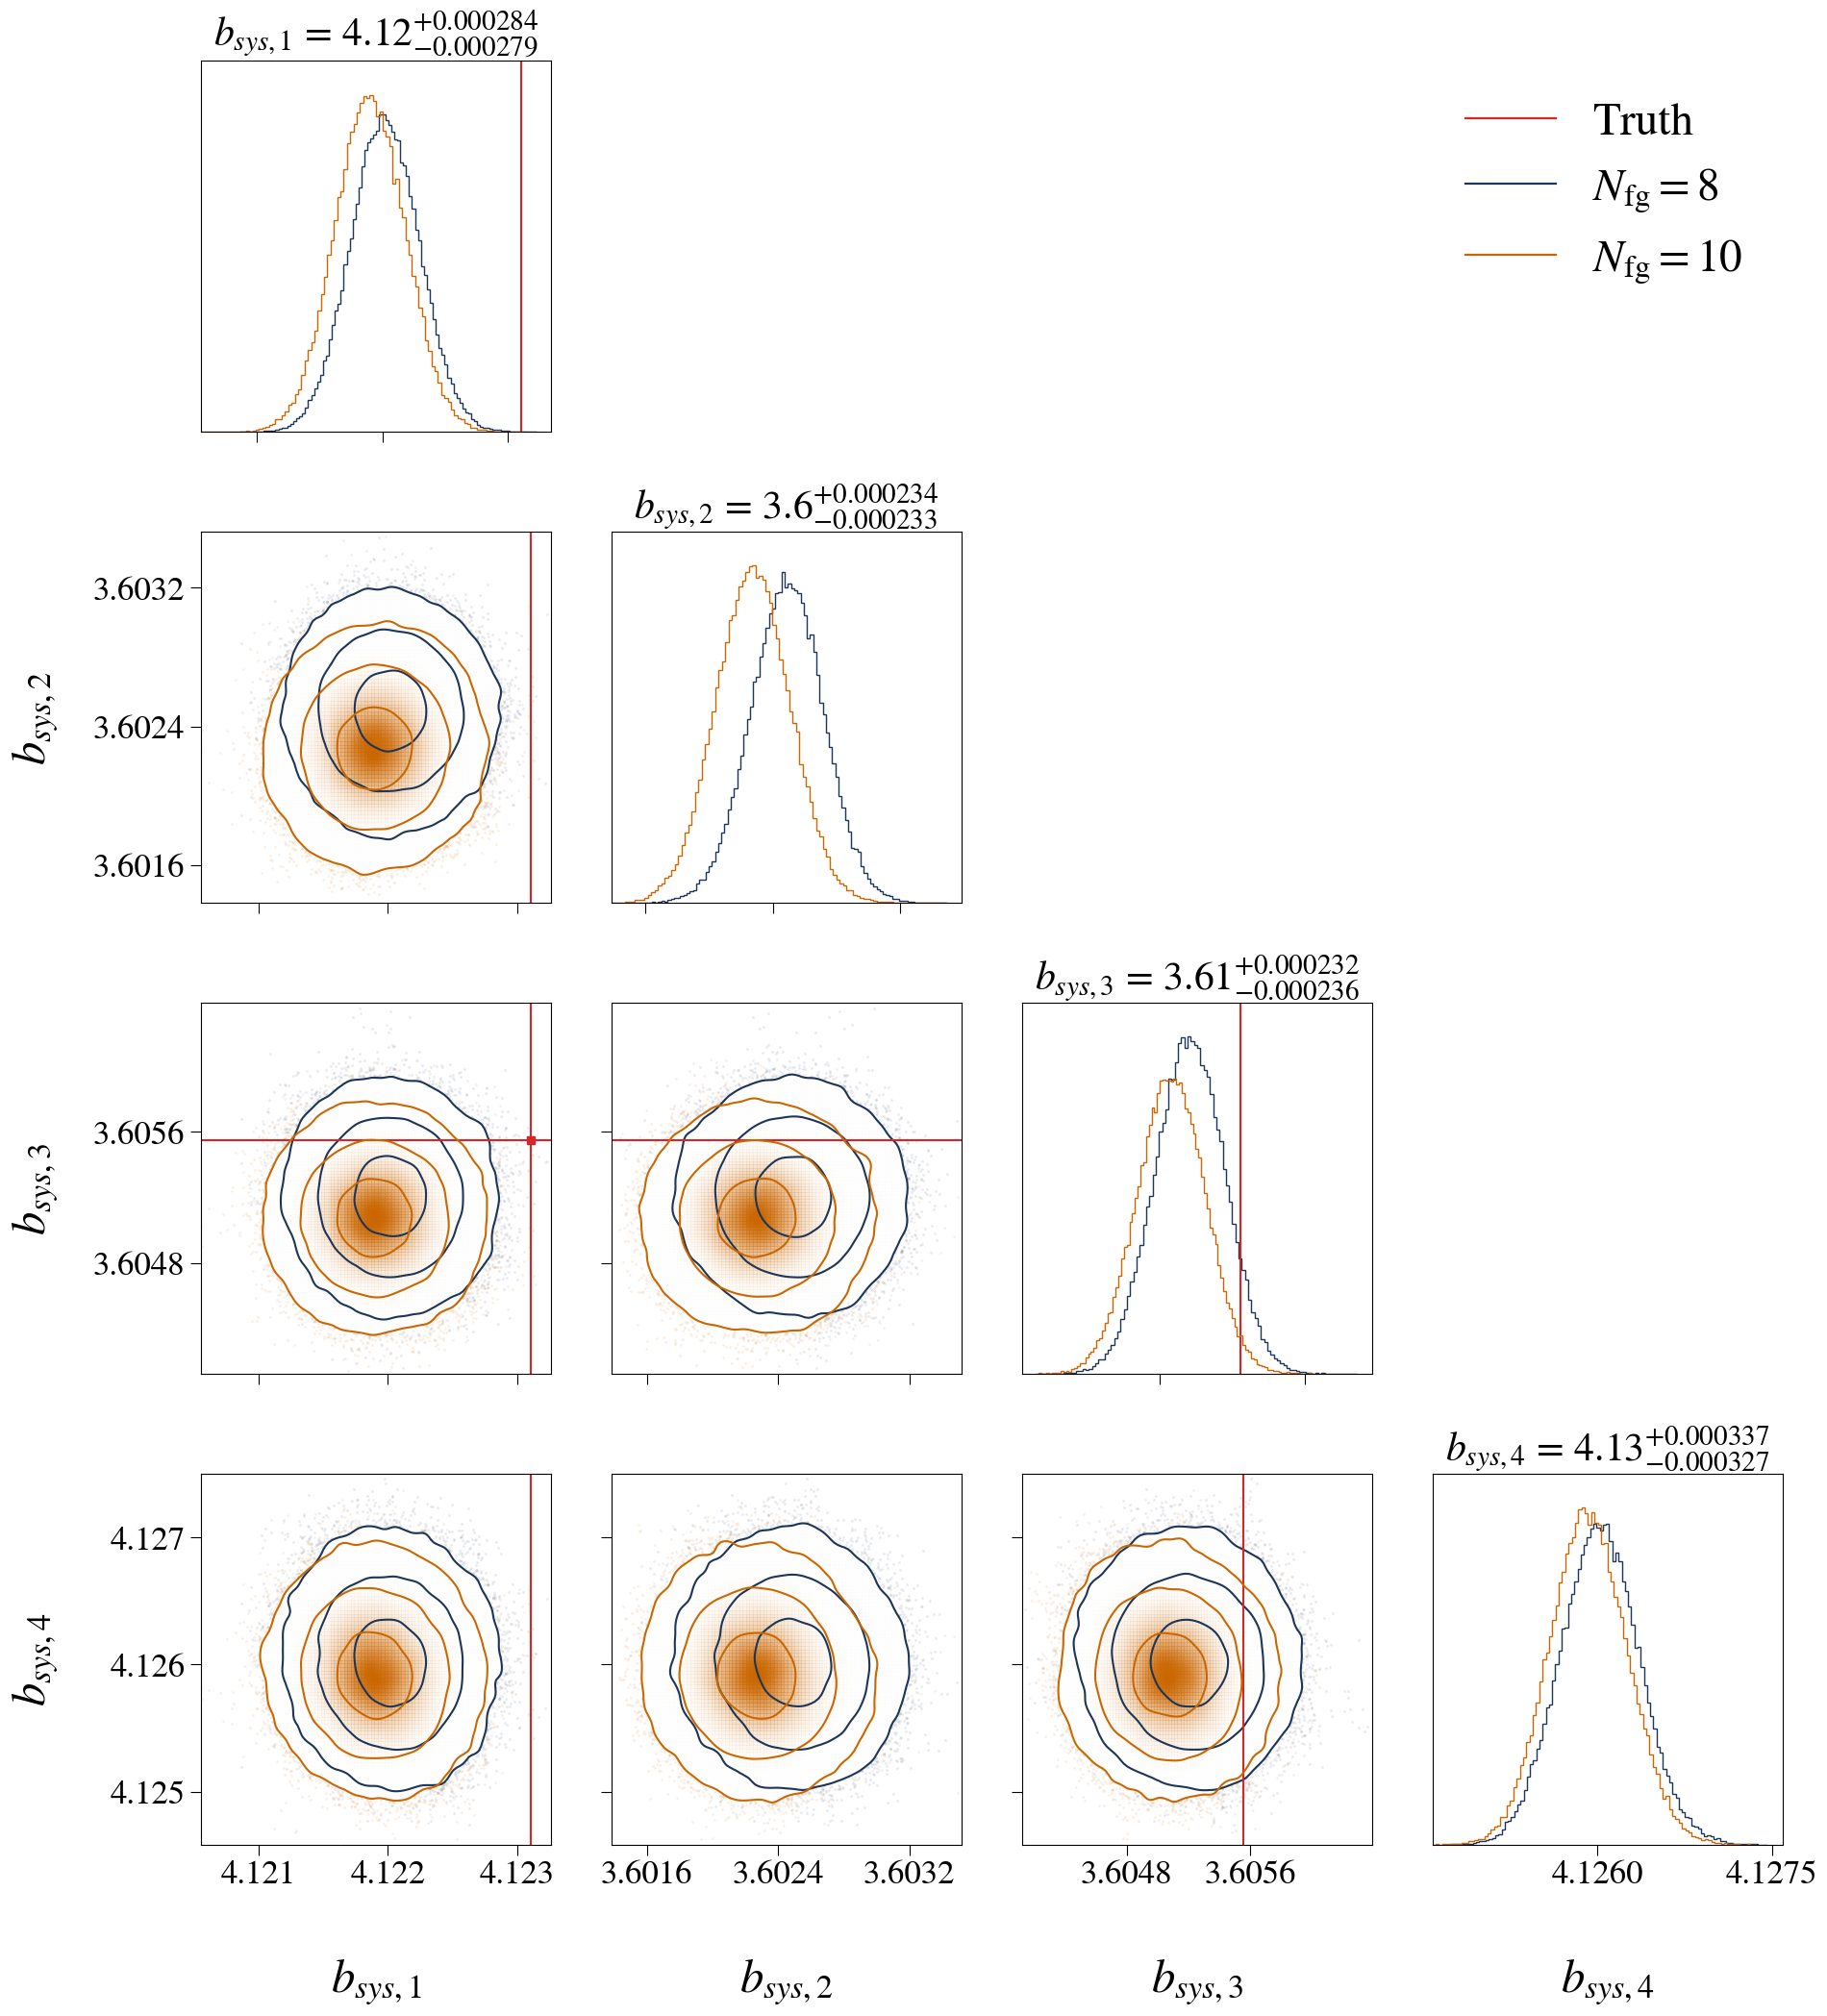

In [19]:
fig, ax = plt.subplots(Nsysmodes, Nsysmodes, figsize=(20, 22))
for a in ax.flatten():
    a.tick_params(length=8)

for i, run_ver in enumerate(run_version_arr):
    b_sys_i = np.load(result_dir + run_ver + '/b-sys.npy')[:Niter_all[i]]
    corner_plot(
        np.abs(b_sys_i),
        truths=np.abs(sys_amps_true) if i == 0 else None,
        labels=[rf'$b_{{sys,{k + 1}}}$' for k in range(Nsysmodes)],
        color=case_colors[i],
        fig=fig,
        nsigma=3,
        title=None,
        case_label=case_labels[i],
    )

save_fig('bsys_corner_plot_nfg.pdf', dpi=100)
print("Corner plot of b_sys, (6/9)")

---
# Figure 7: Delay power spectra (all cases) → `delay_power_spectrum_combined_nfg.pdf`

Top: the full recovered EoR delay power spectrum for each `Nfgmodes`, offset
slightly in delay for legibility.  Bottom: a zoom on the delays occupied by the
systematics.  The hatched band and dotted vertical lines mark the shared
systematic-mode delays.

Mean fractional error for $N_\mathrm{fg} = 8$: 0.5887866430359295
Mean fractional error for $N_\mathrm{fg} = 10$: 0.5106791970969902
  saved /nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures/nfgmodes/delay_power_spectrum_combined_nfg.pdf
Delay power spectra (all cases), (7/9)


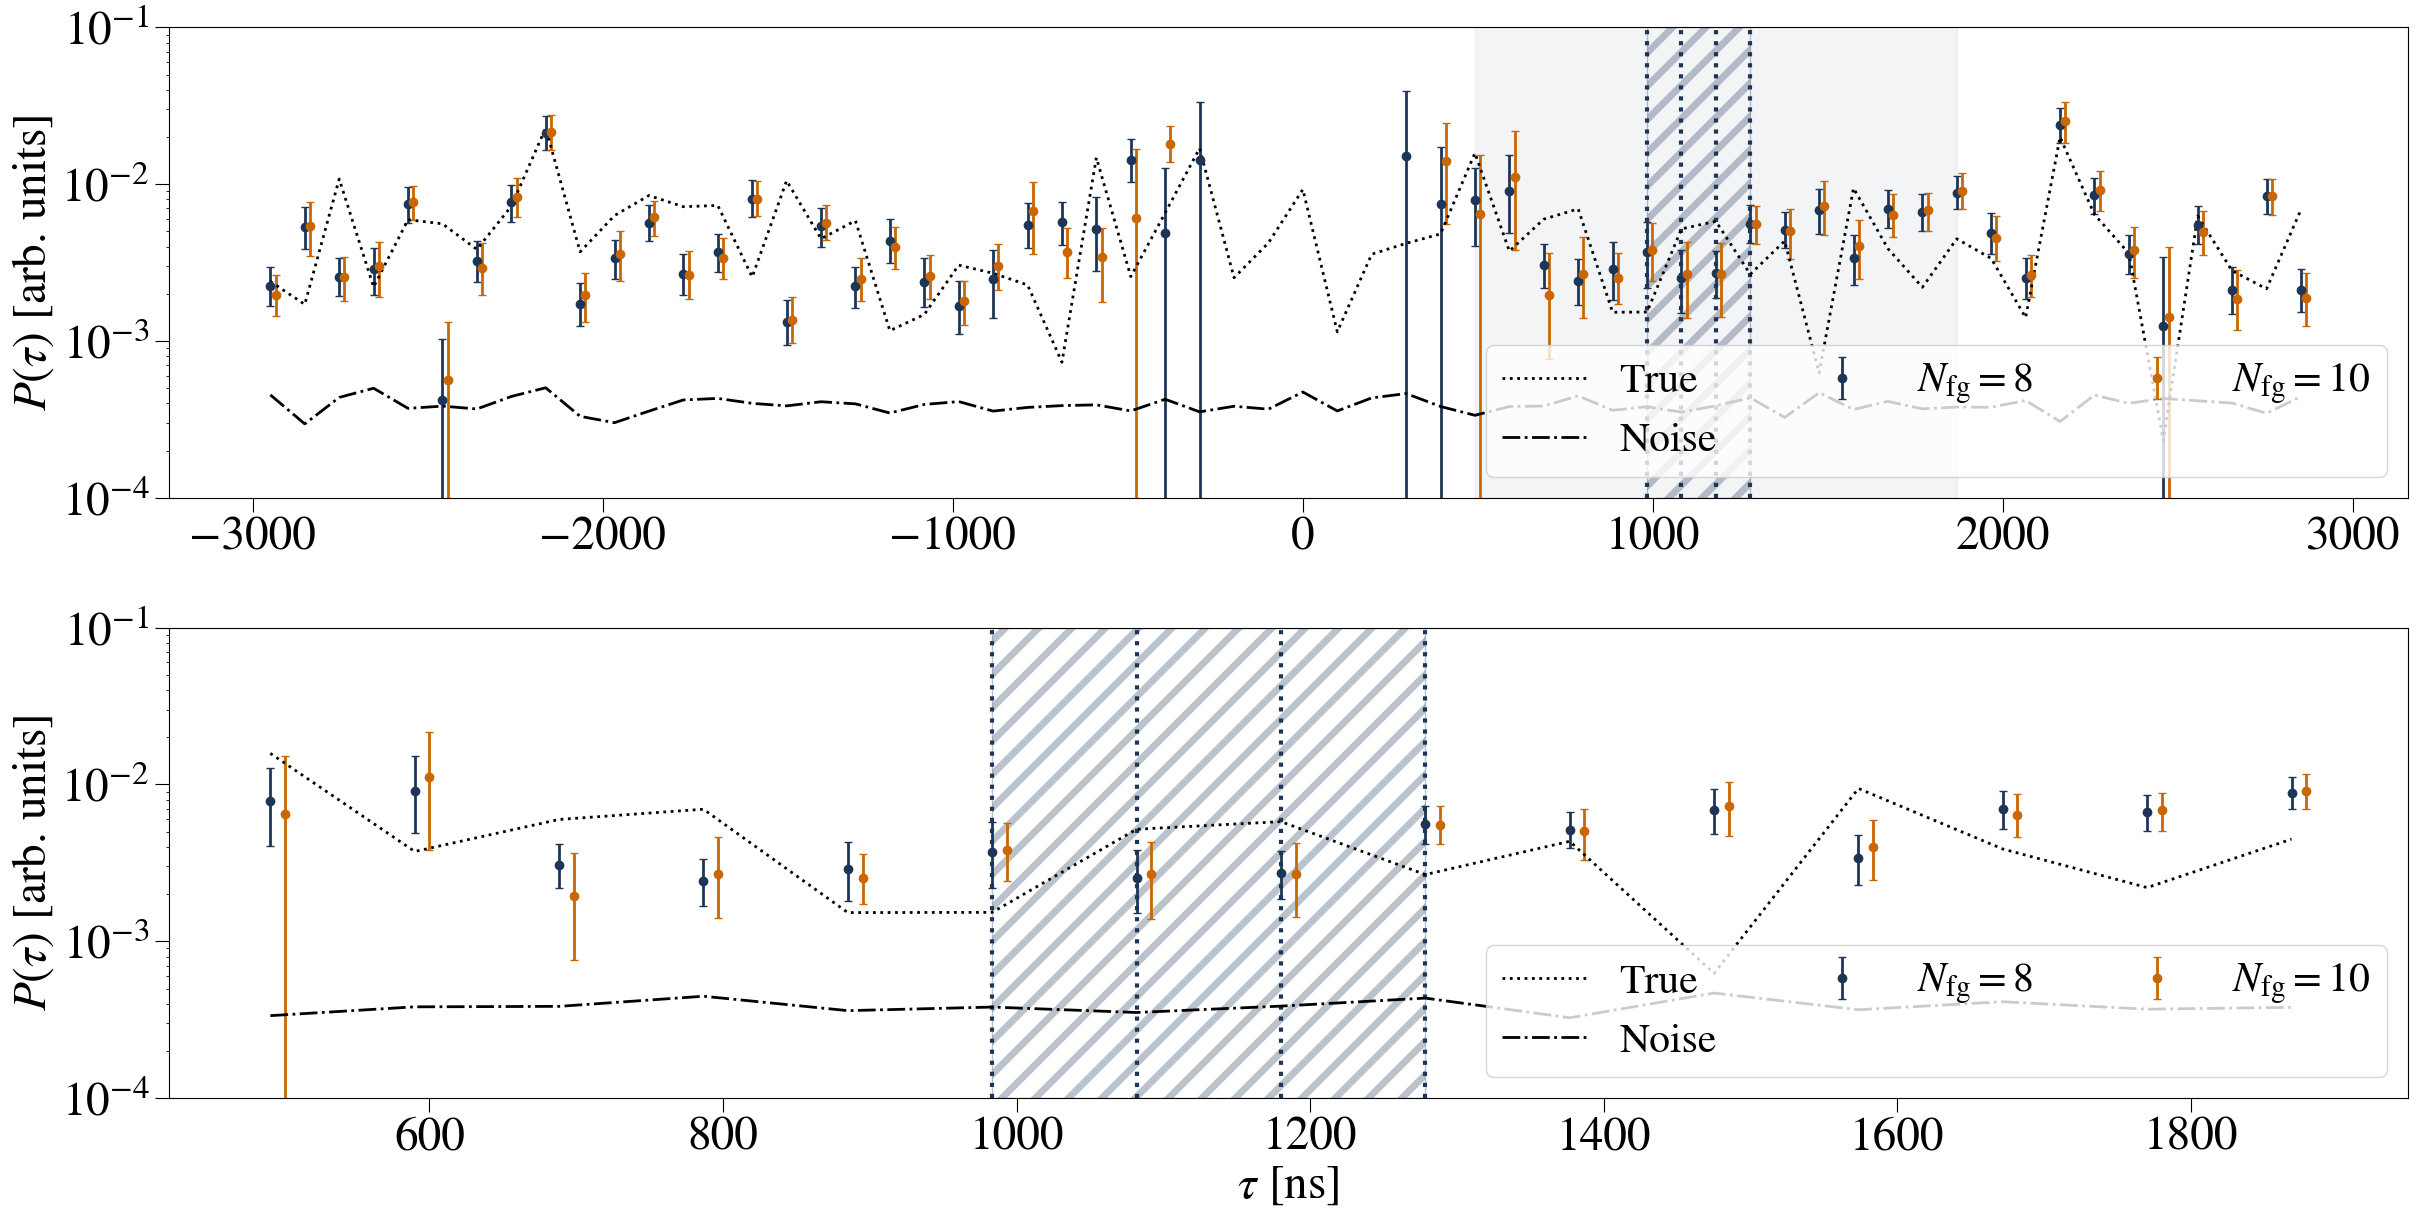

In [20]:
fig, ax = plt.subplots(2, 1, figsize=(25, 13))

sys_dl_idx = np.unique(dl_inds) + int(Nfreqs / 2)
sys_delays = delays[sys_dl_idx].value

zoom_lo = max(0, int(sys_dl_idx.min()) - 5)
zoom_hi = min(Nfreqs, int(sys_dl_idx.max()) + 7)
zoom    = slice(zoom_lo, zoom_hi)

for i, run_ver in enumerate(run_version_arr):
    ps_sample_i = ps_sample_all[i]
    ln_post_i   = ln_post_all[i]

    if Nburn > 0:
        ps_sample_i = ps_sample_i[Nburn:]
        ln_post_i   = ln_post_i[Nburn:]

    dps_pwm    = np.average(ps_sample_i, weights=ln_post_i, axis=0)
    percentile = conf_interval / 2 + 50
    dps_ubound = np.percentile(ps_sample_i, percentile,       axis=0)
    dps_lbound = np.percentile(ps_sample_i, 100 - percentile, axis=0)
    dps_err    = np.vstack((dps_pwm - dps_lbound, dps_ubound - dps_pwm))

    ax[0].errorbar(
        delays.value + i * 15, dps_pwm, yerr=np.abs(dps_err),
        color=case_colors[i], ls='', marker='o', elinewidth=2, capsize=3,
        label=case_labels[i],
    )
    ax[1].errorbar(
        delays[zoom].value + i * 10, dps_pwm[zoom], yerr=np.abs(dps_err[:, zoom]),
        color=case_colors[i], ls='', marker='o', elinewidth=2, capsize=3,
        label=case_labels[i],
    )
    print('Mean fractional error for {}: {}'.format(
        case_labels[i], np.mean((dps_pwm - eor_pspec_true) / eor_pspec_true)))

# ── Shared systematic-mode delays (identical for every case) ─────────────────
for a in ax:
    a.axvspan(sys_delays.min(), sys_delays.max(), facecolor='none', ec=colors[0],
              hatch='/', hatch_linewidth=5, alpha=0.3, zorder=0.1)
    for dl in sys_delays:
        a.axvline(dl, ls='dotted', c=colors[0], lw=3)

ax[0].plot(delays, eor_pspec_true, 'k:', label='True', lw=2)
ax[0].plot(delays, n_pspec, 'k', ls='-.', label='Noise', lw=2)
ax[0].legend(loc='lower right', ncol=3, fontsize=30)
ax[0].set_ylabel(r'$P(\tau)$ [arb. units]')
ax[0].set_ylim(1e-4, 1e-1)
ax[0].set_yscale('log')
ax[0].axvspan(delays[zoom_lo].value, delays[zoom_hi - 1].value,
              facecolor=colors[0], ec=colors[0], alpha=0.05, zorder=0.1)

ax[1].plot(delays[zoom], eor_pspec_true[zoom], 'k:', label='True', lw=2)
ax[1].plot(delays[zoom], n_pspec[zoom], 'k', ls='-.', label='Noise', lw=2)
ax[1].legend(loc='lower right', ncol=3, fontsize=30)
ax[1].set_ylabel(r'$P(\tau)$ [arb. units]')
ax[1].set_xlabel(r'$\tau$ [ns]')
ax[1].set_ylim(1e-4, 1e-1)
ax[1].set_yscale('log')

for a in ax.flatten():
    a.tick_params(length=10)
fig.tight_layout()
save_fig('delay_power_spectrum_combined_nfg.pdf')
print("Delay power spectra (all cases), (7/9)")

---
# Table 1: ESS and autocorrelation time

In [21]:
print("-------ESS TABLES------- \n")
for i, run_ver in enumerate(run_version_arr):
    print(f'Case {i}: {run_ver}  (Nfgmodes = {Nfgmodes_arr[i]})')
    b_sys_i = np.load(result_dir + run_ver + '/b-sys.npy')[:Niter_all[i]]
    taus = emcee.autocorr.integrated_time(b_sys_i, c=5, tol=50, quiet=True, has_walkers=False)
    ess  = Niter_all[i] / taus
    print('\n Taus: {}\nEss:{}\n'.format(taus, ess))

-------ESS TABLES------- 

Case 0: 8fg_caseii_100k  (Nfgmodes = 8)

 Taus: [20.00039094 13.53161608 15.07865966 28.66970527]
Ess:[4999.9022667  7390.10029462 6631.8891907  3488.00237256]

Case 1: high_dl_fr_0  (Nfgmodes = 10)

 Taus: [22.32236011 15.9370257  14.24851621 28.16567808]
Ess:[4479.81304331 6274.69653743 7018.27464424 3550.42046914]



---
# Convergence diagnostics

Table 1 above quotes the effective sample size of $b_\mathrm{sys}$.  This
section asks the broader question directly: **for which `Nfgmodes` case did the
Gibbs sampler converge best?**

The sampler produces a *single* chain per run, so the diagnostics used here are
the ones that work on one chain:

* **Integrated autocorrelation time** $\tau_\mathrm{int}$ and **effective
  sample size** $N_\mathrm{eff} = N/\tau_\mathrm{int}$ (Sokal automatic
  windowing, via `emcee.autocorr`).  $\tau_\mathrm{int}$ is how many Gibbs
  iterations it takes the chain to forget where it was; $N_\mathrm{eff}$ is how
  many independent draws the chain is worth.  Because the cases need not have
  run for the same number of iterations, the comparison below uses the
  **efficiency** $N_\mathrm{eff}/N$.
* **Rank-normalised split-$\hat{R}$** (Vehtari et al. 2021).  The chain is cut
  into `CONV_NSPLIT` consecutive segments which are then compared as if they
  were independent chains, so a chain that is still drifting, or that is stuck
  in different regions at different times, gives $\hat{R} > 1$.  The
  conventional threshold is $\hat{R} \lesssim 1.01$.
* **Geweke $z$**.  Compares the mean of the first 10 % of the chain with the
  mean of the last 50 %, in units of the autocorrelation-corrected standard
  error of the two windows.  For a stationary chain $z \sim \mathcal{N}(0,1)$,
  so $|z| > 2$ means burn-in is not complete.
* **Monte Carlo standard error** $\mathrm{MCSE} = \sigma/\sqrt{N_\mathrm{eff}}$
  — the sampling noise left on a posterior mean.

Monitored parameter blocks: the joint log-posterior $\ln\mathcal{L}$, the
systematic amplitudes $b_\mathrm{sys}$, the EoR delay power spectrum in the
delay bins occupied by the systematics, and the foreground amplitudes
$a_\mathrm{fg}$ at LST index `fg_amp_time_idx`.  Every case is scored by its
*worst* monitored scalar: a sampler has only converged if all of its parameters
have.

**Caveats.**  These statistics can only ever *detect* non-convergence, never
prove convergence.  With one chain per run they are blind to a mode the sampler
never visited, and blocked Gibbs updates correlate all of the parameter blocks,
so the numbers below are more useful for *ranking* the cases against each other
than as absolute statements about any single run.

## Convergence estimators

Same pattern as the online-estimator self-test above: the diagnostics are
defined here and then checked against cases with a known answer.

In [22]:
# ── Convergence-diagnostic helpers ───────────────────────────────────────────
# All diagnostics below are defined for *real scalar* chains, so complex
# parameters are split into their real and imaginary parts first.  A Gibbs
# sampler produces a single chain per run, so the multi-chain diagnostics use
# the split-chain construction (the chain is cut into `CONV_NSPLIT` consecutive
# segments that are then compared with each other).

from scipy.stats import norm as _norm, rankdata as _rankdata

CONV_NSPLIT       = 4     # segments used by the split-Rhat statistic
CONV_BURN         = Nburn # leading samples discarded before the diagnostics
CONV_GEWEKE_FIRST = 0.1   # Geweke: fraction of the chain in the first window
CONV_GEWEKE_LAST  = 0.5   # Geweke: fraction of the chain in the last window
CONV_INCLUDE_FG   = True  # include the foreground-amplitude chains (extra I/O)
CONV_RHAT_OK      = 1.01  # split-Rhat threshold for "converged"
CONV_Z_OK         = 2.0   # |Geweke z| threshold for "stationary"


def real_columns(chain, name):
    """
    Flatten a sample chain into named real-valued scalar chains.

    Complex parameters contribute a separate real and imaginary chain, because
    the autocorrelation/ESS machinery below is only defined for real scalars.

    Parameters
    ----------
    chain : array_like, shape (Nsamples,) or (Nsamples, ...)
        Gibbs samples of one parameter block.
    name : str
        Base label; element index and Re/Im are appended as needed.

    Returns
    -------
    cols : np.ndarray, shape (Nsamples, Ncols), float
    labels : list of str
    """
    arr = np.asarray(chain)
    arr = arr.reshape(arr.shape[0], -1) if arr.ndim > 1 else arr[:, None]
    cplx = np.iscomplexobj(arr)
    cols, labels = [], []
    for k in range(arr.shape[1]):
        tag = name if arr.shape[1] == 1 else f'{name}[{k}]'
        if cplx:
            cols += [arr[:, k].real.astype(float), arr[:, k].imag.astype(float)]
            labels += [f'Re {tag}', f'Im {tag}']
        else:
            cols.append(arr[:, k].astype(float))
            labels.append(tag)
    return np.column_stack(cols), labels


def _as_columns(x):
    x = np.asarray(x, dtype=float)
    return x[:, None] if x.ndim == 1 else x


def tau_int(chain, c=5.0):
    """
    Integrated autocorrelation time of each column, with Sokal's automatic
    windowing (``emcee.autocorr``).  ``tol=0`` so that short chains return a
    number rather than raising; whether the chain is long enough (N > 50 tau)
    is reported separately by `convergence_table`.

    Constant columns have no autocorrelation function and return NaN.
    """
    x = _as_columns(chain)
    out = np.full(x.shape[1], np.nan)
    good = x.std(axis=0) > 0
    if good.any():
        out[good] = np.atleast_1d(emcee.autocorr.integrated_time(
            x[:, good], c=c, tol=0, quiet=True, has_walkers=False))
    return out


def split_rhat(chain, nsplit=CONV_NSPLIT, rank_normalise=True):
    """
    Rank-normalised split-Rhat (Vehtari et al. 2021) for a single chain.

    The chain is split into `nsplit` consecutive segments which play the role of
    independent chains in the usual Gelman-Rubin statistic, so a drifting or
    non-stationary chain gives Rhat > 1 even though only one chain was run.
    Rank normalisation makes the statistic insensitive to the heavy tails and
    non-Gaussianity of the amplitude parameters.

    Returns one Rhat per column; values <~ 1.01 are conventionally "converged".
    """
    x = _as_columns(chain)
    n_seg = x.shape[0] // nsplit
    out = np.full(x.shape[1], np.nan)
    if n_seg < 2:
        return out
    ndrop = x.shape[0] - nsplit * n_seg     # drop the *leading* remainder so
    x = x[ndrop:]                           # the newest samples are always used
    for k in range(x.shape[1]):
        col = x[:, k]
        if not np.all(np.isfinite(col)) or col.std() == 0:
            continue
        if rank_normalise:
            ranks = _rankdata(col)
            col = _norm.ppf((ranks - 3. / 8.) / (col.size - 1. / 4.))
        segs = col.reshape(nsplit, n_seg)
        W = segs.var(axis=1, ddof=1).mean()
        B = n_seg * segs.mean(axis=1).var(ddof=1)
        if W <= 0:
            continue
        var_plus = ((n_seg - 1) * W + B) / n_seg
        out[k] = np.sqrt(var_plus / W)
    return out


def geweke_z(chain, first=CONV_GEWEKE_FIRST, last=CONV_GEWEKE_LAST):
    """
    Geweke (1992) stationarity z-score per column.

    Compares the mean of the first `first` fraction of the chain with the mean
    of the last `last` fraction, standardised by the autocorrelation-corrected
    standard error of each window.  For a stationary chain z ~ N(0, 1), so
    |z| > 2 flags a chain whose start and end are still sampling different
    distributions (i.e. burn-in is not complete).
    """
    x = _as_columns(chain)
    n = x.shape[0]
    na, nb = int(first * n), int(last * n)
    if na < 2 or nb < 2:
        return np.full(x.shape[1], np.nan)
    a, b = x[:na], x[-nb:]
    var_a = a.var(axis=0, ddof=1) * np.clip(tau_int(a), 1., None) / na
    var_b = b.var(axis=0, ddof=1) * np.clip(tau_int(b), 1., None) / nb
    se = np.sqrt(var_a + var_b)
    with np.errstate(invalid='ignore', divide='ignore'):
        return np.where(se > 0, (a.mean(axis=0) - b.mean(axis=0)) / se, np.nan)


def convergence_table(chain, name):
    """
    Full diagnostic set for one parameter block.

    Returns a dict of per-scalar arrays: integrated autocorrelation time `tau`,
    effective sample size `ess`, efficiency `ess_frac = ESS / Nsamples`, Monte
    Carlo standard error of the mean `mcse`, rank-normalised split-Rhat `rhat`,
    Geweke `z`, and `reliable` (N > 50 tau, the regime where the tau estimate
    itself can be trusted).
    """
    cols, labels = real_columns(chain, name)
    n = cols.shape[0]
    tau = tau_int(cols)
    with np.errstate(invalid='ignore', divide='ignore'):
        ess = n / tau
    return dict(
        group=name, labels=labels, n=n, tau=tau, ess=ess, ess_frac=ess / n,
        mcse=cols.std(axis=0, ddof=1) / np.sqrt(ess),
        sd=cols.std(axis=0, ddof=1),
        rhat=split_rhat(cols), z=geweke_z(cols),
        reliable=n > 50 * tau,
    )


def _nanagg(func, arr):
    """np.nanmin/max/median that returns NaN instead of warning on all-NaN."""
    arr = np.asarray(arr, dtype=float)
    return func(arr) if np.isfinite(arr).any() else np.nan

In [23]:
# ── Self-test of the convergence estimators ──────────────────────────────────
# AR(1) with correlation rho has integrated autocorrelation time
# tau = (1 + rho) / (1 - rho) and ESS = N / tau, which gives an exact reference
# for `tau_int`.  An independent chain must give split-Rhat ~ 1 and |z| < 3,
# while a chain with a slow drift must be caught by both diagnostics.

_rng = np.random.default_rng(0)
_n, _rho = 200000, 0.8
_e = _rng.normal(size=_n)
_ar = np.empty(_n)
_ar[0] = _e[0]
for _t in range(1, _n):
    _ar[_t] = _rho * _ar[_t - 1] + np.sqrt(1 - _rho ** 2) * _e[_t]

_tau_true = (1 + _rho) / (1 - _rho)
_tau_est  = tau_int(_ar)[0]
assert abs(_tau_est - _tau_true) / _tau_true < 0.15, \
    f'tau_int: got {_tau_est:.2f}, expected {_tau_true:.2f}'

_iid   = _rng.normal(size=_n)
_drift = _iid + np.linspace(0, 3, _n)     # non-stationary: mean walks by 3 sigma

assert split_rhat(_iid)[0]   < 1.01, 'split_rhat flags an independent chain'
assert split_rhat(_drift)[0] > 1.05, 'split_rhat misses a drifting chain'
assert abs(geweke_z(_iid)[0])   < 3.,  'geweke_z flags an independent chain'
assert abs(geweke_z(_drift)[0]) > 5.,  'geweke_z misses a drifting chain'

# Complex chains are split into real and imaginary scalar chains.
_cols, _labels = real_columns((_iid + 1j * _ar)[:, None], 'x')
assert _labels == ['Re x', 'Im x'] and np.allclose(_cols[:, 1], _ar)

print(f'tau_int on AR(1): {_tau_est:.2f} (exact {_tau_true:.2f})')
print(f'split-Rhat  independent {split_rhat(_iid)[0]:.4f}   drifting {split_rhat(_drift)[0]:.4f}')
print(f'Geweke z    independent {geweke_z(_iid)[0]:+.2f}     drifting {geweke_z(_drift)[0]:+.2f}')
print('Convergence estimators pass their self-test.')
del _rng, _e, _ar, _iid, _drift, _cols, _labels

tau_int on AR(1): 9.16 (exact 9.00)
split-Rhat  independent 1.0000   drifting 1.3711
Geweke z    independent +0.20     drifting -8.78
Convergence estimators pass their self-test.


## Per-case diagnostics

Reloads only the small chains (`b-sys`, `ln-post`, `dps-eor` are already in
memory from the all-cases loop; `fg-amps` is read as one LST slice), so this is
cheap compared with the sample loop above.

In [24]:
# ── Per-case diagnostics ─────────────────────────────────────────────────────
# Monitored blocks: the joint log-posterior (the natural global scalar), the
# systematic amplitudes b_sys (the parameters the systematics model is built
# from), the EoR delay power spectrum in the delay bins occupied by the
# systematics (the science parameters most at risk), and — optionally — the
# foreground amplitudes at one LST.  The number of foreground amplitudes is
# what differs between the cases, so the fg block is summarised, never compared
# element by element.

sys_dl_idx_conv = np.unique(dl_inds) + int(Nfreqs / 2)   # delay bins of the systematics

# Pretty names for the monitored blocks, used by the figures below.
conv_group_tex = {
    'ln_post':   r'$\ln \mathcal{L}$',
    'b_sys':     r'$b_\mathrm{sys}$',
    'P_EoR_sys': r'$P_\mathrm{EoR}$(sys)',
    'a_fg':      r'$a_\mathrm{fg}$',
}

conv_stats   = [None] * Ncases   # list of per-block diagnostic dicts, per case
conv_chains  = [None] * Ncases   # the monitored chains themselves (for the figures)
ess_dps_all  = [None] * Ncases   # ESS of the EoR DPS in every delay bin

for i, run_ver in enumerate(run_version_arr):
    Niter_i = Niter_all[i]
    print(f'\n=== Case {i} — {run_ver} (Nfgmodes = {Nfgmodes_arr[i]}) ===')

    b_sys_i   = np.load(result_dir + run_ver + '/b-sys.npy')[CONV_BURN:Niter_i]
    ln_post_i = np.asarray(ln_post_all[i])[CONV_BURN:].reshape(-1)
    dps_i     = np.asarray(ps_sample_all[i])[CONV_BURN:]

    chains = [
        ('ln_post',  ln_post_i),
        ('b_sys',    b_sys_i),
        ('P_EoR_sys', dps_i[:, sys_dl_idx_conv]),
    ]

    if CONV_INCLUDE_FG:
        _fg = np.load(result_dir + run_ver + '/fg-amps.npy',
                      mmap_mode='r' if USE_MMAP else None)
        _fg = np.asarray(_fg[CONV_BURN:Niter_i, fg_amp_time_idx, :Nfgmodes_arr[i]])
        chains.append(('a_fg', _fg))
        del _fg

    conv_chains[i] = dict(chains)
    conv_stats[i]  = [convergence_table(ch, name) for name, ch in chains]

    # ESS per delay bin, used by Figure C3
    ess_dps_all[i] = (dps_i.shape[0] / tau_int(dps_i))

    for st in conv_stats[i]:
        print(f'  {st["group"]:<12s} '
              f'ESS/N min {_nanagg(np.nanmin, st["ess_frac"]):.3f}  '
              f'med {_nanagg(np.nanmedian, st["ess_frac"]):.3f}   '
              f'max Rhat {_nanagg(np.nanmax, st["rhat"]):.4f}   '
              f'max |z| {_nanagg(np.nanmax, np.abs(st["z"])):.2f}')

    del b_sys_i, ln_post_i, dps_i

print('\nDone.')


=== Case 0 — 8fg_caseii_100k (Nfgmodes = 8) ===


invalid value encountered in sqrt


  ln_post      ESS/N min 1.867  med 1.867   max Rhat 1.0000   max |z| 1.76
  b_sys        ESS/N min 0.034  med 0.057   max Rhat 1.0016   max |z| 0.98
  P_EoR_sys    ESS/N min -2.494  med -0.774   max Rhat 1.0000   max |z| 0.75
  a_fg         ESS/N min -6.691  med -0.054   max Rhat 1.0000   max |z| 1.33

=== Case 1 — high_dl_fr_0 (Nfgmodes = 10) ===
  ln_post      ESS/N min 4.978  med 4.978   max Rhat 1.0000   max |z| 1.25
  b_sys        ESS/N min 0.036  med 0.058   max Rhat 1.0034   max |z| 1.67
  P_EoR_sys    ESS/N min -18.244  med -1.684   max Rhat 1.0000   max |z| 0.28
  a_fg         ESS/N min -2.302  med 1.001   max Rhat 1.0000   max |z| 1.95

Done.


## Convergence summary and ranking

The verdict printed at the end of this cell is the answer to *which case
converged best*.

In [25]:
# ── Summary table and ranking ────────────────────────────────────────────────
# ESS/N (efficiency) rather than raw ESS is the fair comparison, because the
# cases need not have run for the same number of iterations.  The ranking uses
# the *worst* monitored scalar in each case: a sampler is only converged if all
# of its parameters are.

summary = []
for i, run_ver in enumerate(run_version_arr):
    ess_frac = np.concatenate([s['ess_frac'] for s in conv_stats[i]])
    tau      = np.concatenate([s['tau']      for s in conv_stats[i]])
    rhat     = np.concatenate([s['rhat']     for s in conv_stats[i]])
    zed      = np.abs(np.concatenate([s['z'] for s in conv_stats[i]]))
    rel      = np.concatenate([s['reliable'] for s in conv_stats[i]])
    summary.append(dict(
        case=i, run=run_ver, nfg=Nfgmodes_arr[i], n=Niter_all[i] - CONV_BURN,
        min_ess_frac=_nanagg(np.nanmin, ess_frac),
        med_ess_frac=_nanagg(np.nanmedian, ess_frac),
        min_ess=_nanagg(np.nanmin, ess_frac) * (Niter_all[i] - CONV_BURN),
        max_tau=_nanagg(np.nanmax, tau),
        max_rhat=_nanagg(np.nanmax, rhat),
        n_rhat_bad=int(np.sum(rhat > CONV_RHAT_OK)),
        max_z=_nanagg(np.nanmax, zed),
        frac_z_bad=float(np.mean(zed[np.isfinite(zed)] > CONV_Z_OK)) if np.isfinite(zed).any() else np.nan,
        nparams=ess_frac.size,
        frac_unreliable=float(np.mean(~rel)),
    ))

hdr = (f'{"case":<5s}{"Nfg":>5s}{"Nsamp":>9s}{"Npar":>6s}{"minESS/N":>10s}'
       f'{"medESS/N":>10s}{"minESS":>9s}{"max tau":>9s}{"max Rhat":>10s}'
       f'{"Rhat>1.01":>11s}{"max|z|":>8s}{"|z|>2":>8s}')
print('----- Convergence summary (burn-in of '
      f'{CONV_BURN} samples removed) -----\n')
print(hdr)
print('-' * len(hdr))
for s in summary:
    print(f'{s["case"]:<5d}{s["nfg"]:>5d}{s["n"]:>9d}{s["nparams"]:>6d}'
          f'{s["min_ess_frac"]:>10.4f}{s["med_ess_frac"]:>10.4f}{s["min_ess"]:>9.0f}'
          f'{s["max_tau"]:>9.1f}{s["max_rhat"]:>10.4f}{s["n_rhat_bad"]:>11d}'
          f'{s["max_z"]:>8.2f}{s["frac_z_bad"]:>8.2f}')

# ── Ranking ──────────────────────────────────────────────────────────────────
# Three independent criteria, each turned into a rank (0 = best) and averaged:
#   * efficiency   : worst ESS/N over all monitored scalars   (larger is better)
#   * mixing       : worst rank-normalised split-Rhat         (smaller is better)
#   * stationarity : fraction of scalars failing Geweke |z|<2 (smaller is better)
def _ranks(values, larger_is_better):
    v = np.asarray(values, dtype=float)
    v = np.where(np.isfinite(v), v, -np.inf if larger_is_better else np.inf)
    order = np.argsort(-v if larger_is_better else v, kind='stable')
    r = np.empty(v.size, dtype=float)
    r[order] = np.arange(v.size)
    return r

rank_eff  = _ranks([s['min_ess_frac'] for s in summary], True)
rank_rhat = _ranks([s['max_rhat']     for s in summary], False)
rank_z    = _ranks([s['frac_z_bad']   for s in summary], False)
rank_avg  = (rank_eff + rank_rhat + rank_z) / 3.

print('\n----- Ranking (0 = best) -----\n')
print(f'{"case":<5s}{"Nfg":>5s}{"efficiency":>12s}{"mixing":>9s}{"stationarity":>14s}{"mean rank":>11s}')
for i, s in enumerate(summary):
    print(f'{s["case"]:<5d}{s["nfg"]:>5d}{rank_eff[i]:>12.0f}{rank_rhat[i]:>9.0f}'
          f'{rank_z[i]:>14.0f}{rank_avg[i]:>11.2f}')

best = int(np.argmin(rank_avg))
print(f'\nBest-converged case: {best} — {run_version_arr[best]} '
      f'(Nfgmodes = {Nfgmodes_arr[best]})')
print(f'  worst ESS/N over {summary[best]["nparams"]} monitored scalars: '
      f'{summary[best]["min_ess_frac"]:.4f} '
      f'({summary[best]["min_ess"]:.0f} effective samples)')
print(f'  worst split-Rhat: {summary[best]["max_rhat"]:.4f}   '
      f'worst |Geweke z|: {summary[best]["max_z"]:.2f}')
if summary[best]['max_rhat'] > CONV_RHAT_OK:
    print(f'  CAUTION: even the best case has split-Rhat > {CONV_RHAT_OK}; no case '
          'is fully converged by that criterion.')

# ── Slowest-mixing scalar in each case ───────────────────────────────────────
print('\n----- Slowest-mixing monitored scalar per case -----\n')
for i in range(Ncases):
    labels = sum([s['labels'] for s in conv_stats[i]], [])
    ess_f  = np.concatenate([s['ess_frac'] for s in conv_stats[i]])
    taus   = np.concatenate([s['tau'] for s in conv_stats[i]])
    k = int(np.nanargmin(np.where(np.isfinite(ess_f), ess_f, np.inf)))
    print(f'  case {i} (Nfg = {Nfgmodes_arr[i]:>2d}): {labels[k]:<18s} '
          f'tau = {taus[k]:.1f}, ESS/N = {ess_f[k]:.4f}')

----- Convergence summary (burn-in of 10000 samples removed) -----

case   Nfg    Nsamp  Npar  minESS/N  medESS/N   minESS  max tau  max Rhat  Rhat>1.01  max|z|   |z|>2
----------------------------------------------------------------------------------------------------
0        8    90000    29   -6.6913    0.0651  -602217     29.0    1.0016          0    1.76    0.00
1       10    90000    33  -18.2439    0.0714 -1641954     27.5    1.0034          0    1.95    0.00

----- Ranking (0 = best) -----

case   Nfg  efficiency   mixing  stationarity  mean rank
0        8           0        0             0       0.00
1       10           1        1             1       1.00

Best-converged case: 0 — 8fg_caseii_100k (Nfgmodes = 8)
  worst ESS/N over 29 monitored scalars: -6.6913 (-602217 effective samples)
  worst split-Rhat: 1.0016   worst |Geweke z|: 1.76

----- Slowest-mixing monitored scalar per case -----

  case 0 (Nfg =  8): Re a_fg[6]         tau = -0.1, ESS/N = -6.6913
  case 1 (Nfg =

## Convergence is not accuracy

A chain can mix perfectly and still sit on the wrong answer.  The table below
separates the two: `|bias|/sd` is how far the posterior mean of each systematic
amplitude sits from the truth in units of the posterior scatter (a property of
the *model* — how well `Nfgmodes` lets the sampler separate foregrounds from
systematics), while `MCSE/sd` is how much of that offset the *chain length*
could explain.

In [26]:
# ── Convergence is not accuracy ──────────────────────────────────────────────
# A chain can mix perfectly and still sit on the wrong answer, so the table
# below reports, for every systematic amplitude, how far the posterior mean is
# from the truth in units of the posterior scatter, together with the Monte
# Carlo error on that mean.  `bias/sd` is a property of the model (how well
# Nfgmodes lets the sampler separate foregrounds from systematics); `MCSE/sd`
# is a property of the chain (how long it ran).

print(f'{"case":<5s}{"Nfg":>5s}{"mode":>18s}{"|bias|/sd":>12s}{"MCSE/sd":>10s}{"ESS":>10s}')
print('-' * 60)
for i, run_ver in enumerate(run_version_arr):
    b = np.asarray(conv_chains[i]['b_sys'])
    st = [s for s in conv_stats[i] if s['group'] == 'b_sys'][0]
    for k in range(Nsysmodes):
        for part, tag in ((np.real, 'Re'), (np.imag, 'Im')):
            col   = part(b[:, k])
            truth = part(sys_amps_true[k])
            sd    = col.std(ddof=1)
            j     = 2 * k + (0 if tag == 'Re' else 1)
            print(f'{i:<5d}{Nfgmodes_arr[i]:>5d}{f"{tag} b_sys,{k + 1}":>18s}'
                  f'{abs(col.mean() - truth) / sd:>12.2f}'
                  f'{st["mcse"][j] / sd:>10.4f}{st["ess"][j]:>10.0f}')
    print('-' * 60)

case   Nfg              mode   |bias|/sd   MCSE/sd       ESS
------------------------------------------------------------
0        8        Re b_sys,1        0.75    0.0150      4443
0        8        Im b_sys,1        3.90    0.0151      4378
0        8        Re b_sys,2       10.71    0.0122      6698
0        8        Im b_sys,2        8.90    0.0121      6804
0        8        Re b_sys,3        2.78    0.0131      5859
0        8        Im b_sys,3        1.49    0.0128      6065
0        8        Re b_sys,4        8.14    0.0178      3172
0        8        Im b_sys,4        3.11    0.0179      3104
------------------------------------------------------------
1       10        Re b_sys,1        2.44    0.0150      4415
1       10        Im b_sys,1        3.85    0.0153      4291
1       10        Re b_sys,2       11.48    0.0128      6091
1       10        Im b_sys,2        9.34    0.0125      6359
1       10        Re b_sys,3        3.51    0.0125      6427
1       10        Im b_s

---
### Figure C1: traces and running means → `convergence_traces_nfg.pdf`

The visual check behind the numbers.  Top: the log-posterior trace of each case
(relative to its own median, since the absolute value depends on `Nfgmodes`) —
look for drift or long excursions.  Middle and bottom: running means of
$\mathrm{Re}\,b_{\mathrm{sys},1}$ and of $P_\mathrm{EoR}$ at the first
systematic delay.  A converged chain's running mean flattens out; one that is
still wandering at the end of the run has not converged.

  saved /nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures/nfgmodes/convergence_traces_nfg.pdf
Convergence traces and running means, (C1/C3)


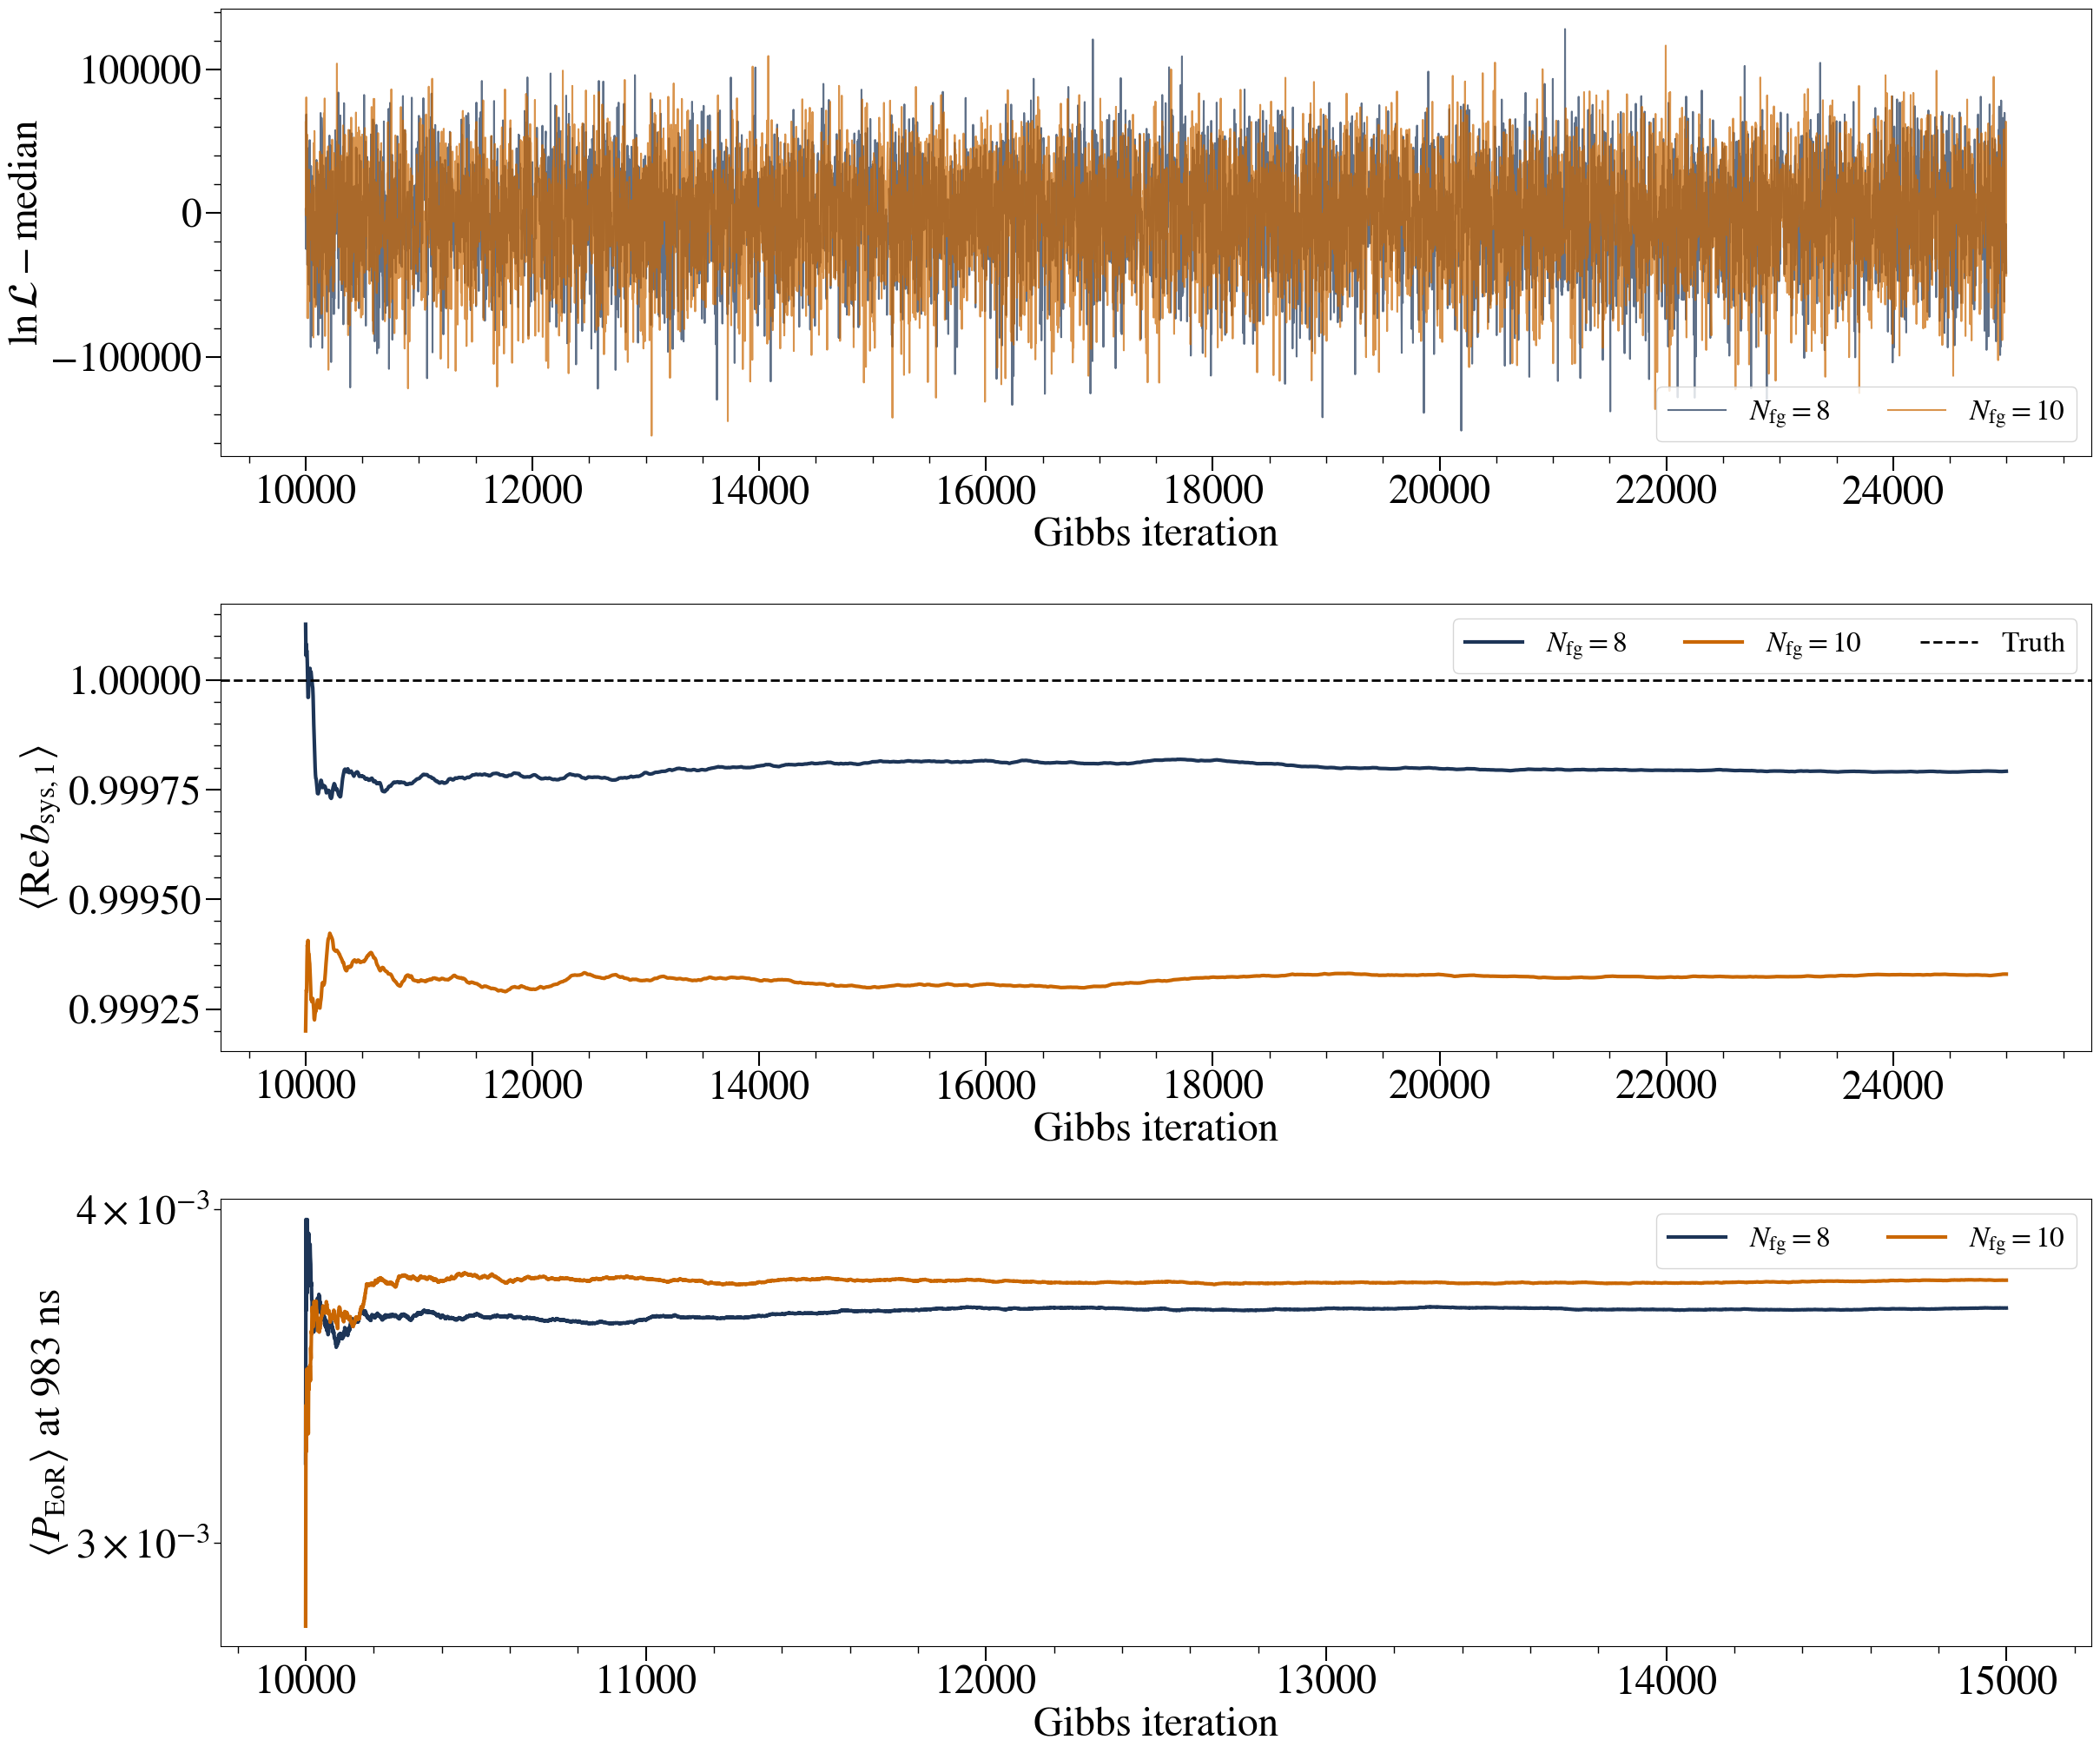

In [27]:
def _running_mean(x):
    x = np.asarray(x, dtype=float)
    return np.cumsum(x) / np.arange(1, x.size + 1)


def _thin(n, nmax=4000):
    return slice(None, None, max(1, n // nmax))


fig, axs = plt.subplots(3, 1, figsize=(25, 21))

# --------------- log-posterior trace ----------------
# The absolute value of ln L depends on the number of foreground modes, so each
# case is shown relative to its own median: what matters here is the shape of
# the trace (drift, sticking, excursions), not the offset between cases.
for i in range(Ncases):
    y = np.asarray(conv_chains[i]['ln_post'][14000:29000], dtype=float).reshape(-1)
    y = y - np.median(y)
    s = _thin(y.size)
    axs[0].plot(np.arange(y.size)[s] + CONV_BURN, y[s], color=case_colors[i],
                lw=1.5, alpha=0.7, label=case_labels[i])
axs[0].set_ylabel(r'$\ln \mathcal{L} - \mathrm{median}$')
axs[0].legend(fontsize=24, ncol=Ncases, loc='lower right')

# --------------- running mean of Re b_sys,1 ----------------
for i in range(Ncases):
    b = np.asarray(conv_chains[i]['b_sys'][14000:29000])
    y = _running_mean(b[:, 0].real)
    s = _thin(y.size)
    axs[1].plot(np.arange(y.size)[s] + CONV_BURN, y[s], color=case_colors[i], lw=3,
                label=case_labels[i])
axs[1].axhline(sys_amps_true[0].real, color='k', ls='--', lw=2, label='Truth')
axs[1].set_ylabel(r'$\langle \mathrm{Re}\, b_{\mathrm{sys},1} \rangle$')
axs[1].legend(fontsize=24, ncol=Ncases + 1, loc='best')

# --------------- running mean of P_EoR at the first systematic delay ----------
_dl0 = int(sys_dl_idx_conv[0])
for i in range(Ncases):
    p = np.asarray(ps_sample_all[i][14000:29000])[CONV_BURN:, _dl0]
    y = _running_mean(p)
    s = _thin(y.size)
    axs[2].plot(np.arange(y.size)[s] + CONV_BURN, y[s], color=case_colors[i], lw=3,
                label=case_labels[i])
axs[2].set_ylabel(rf'$\langle P_\mathrm{{EoR}} \rangle$ at {delays_ns[_dl0]:.0f} ns')
axs[2].set_yscale('log')
axs[2].legend(fontsize=24, ncol=Ncases, loc='best')

for ax in axs:
    ax.set_xlabel('Gibbs iteration')
    ax.minorticks_on()
    ax.tick_params(which='major', direction='out', length=12, width=1.5)
    ax.tick_params(which='minor', direction='out', length=6, width=1.0)

plt.tight_layout()
save_fig('convergence_traces_nfg.pdf')
print('Convergence traces and running means, (C1/C3)')

---
### Figure C2: autocorrelation and efficiency → `convergence_acf_ess_nfg.pdf`

Left: the autocorrelation function of $b_\mathrm{sys}$ (averaged over the real
and imaginary parts of all `Nsysmodes` amplitudes) — how many iterations each
case needs to forget its previous sample.  Right: the worst efficiency
$N_\mathrm{eff}/N$ in each monitored block, per case.

  saved /nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures/nfgmodes/convergence_acf_ess_nfg.pdf
b_sys autocorrelation and per-block efficiency, (C2/C3)


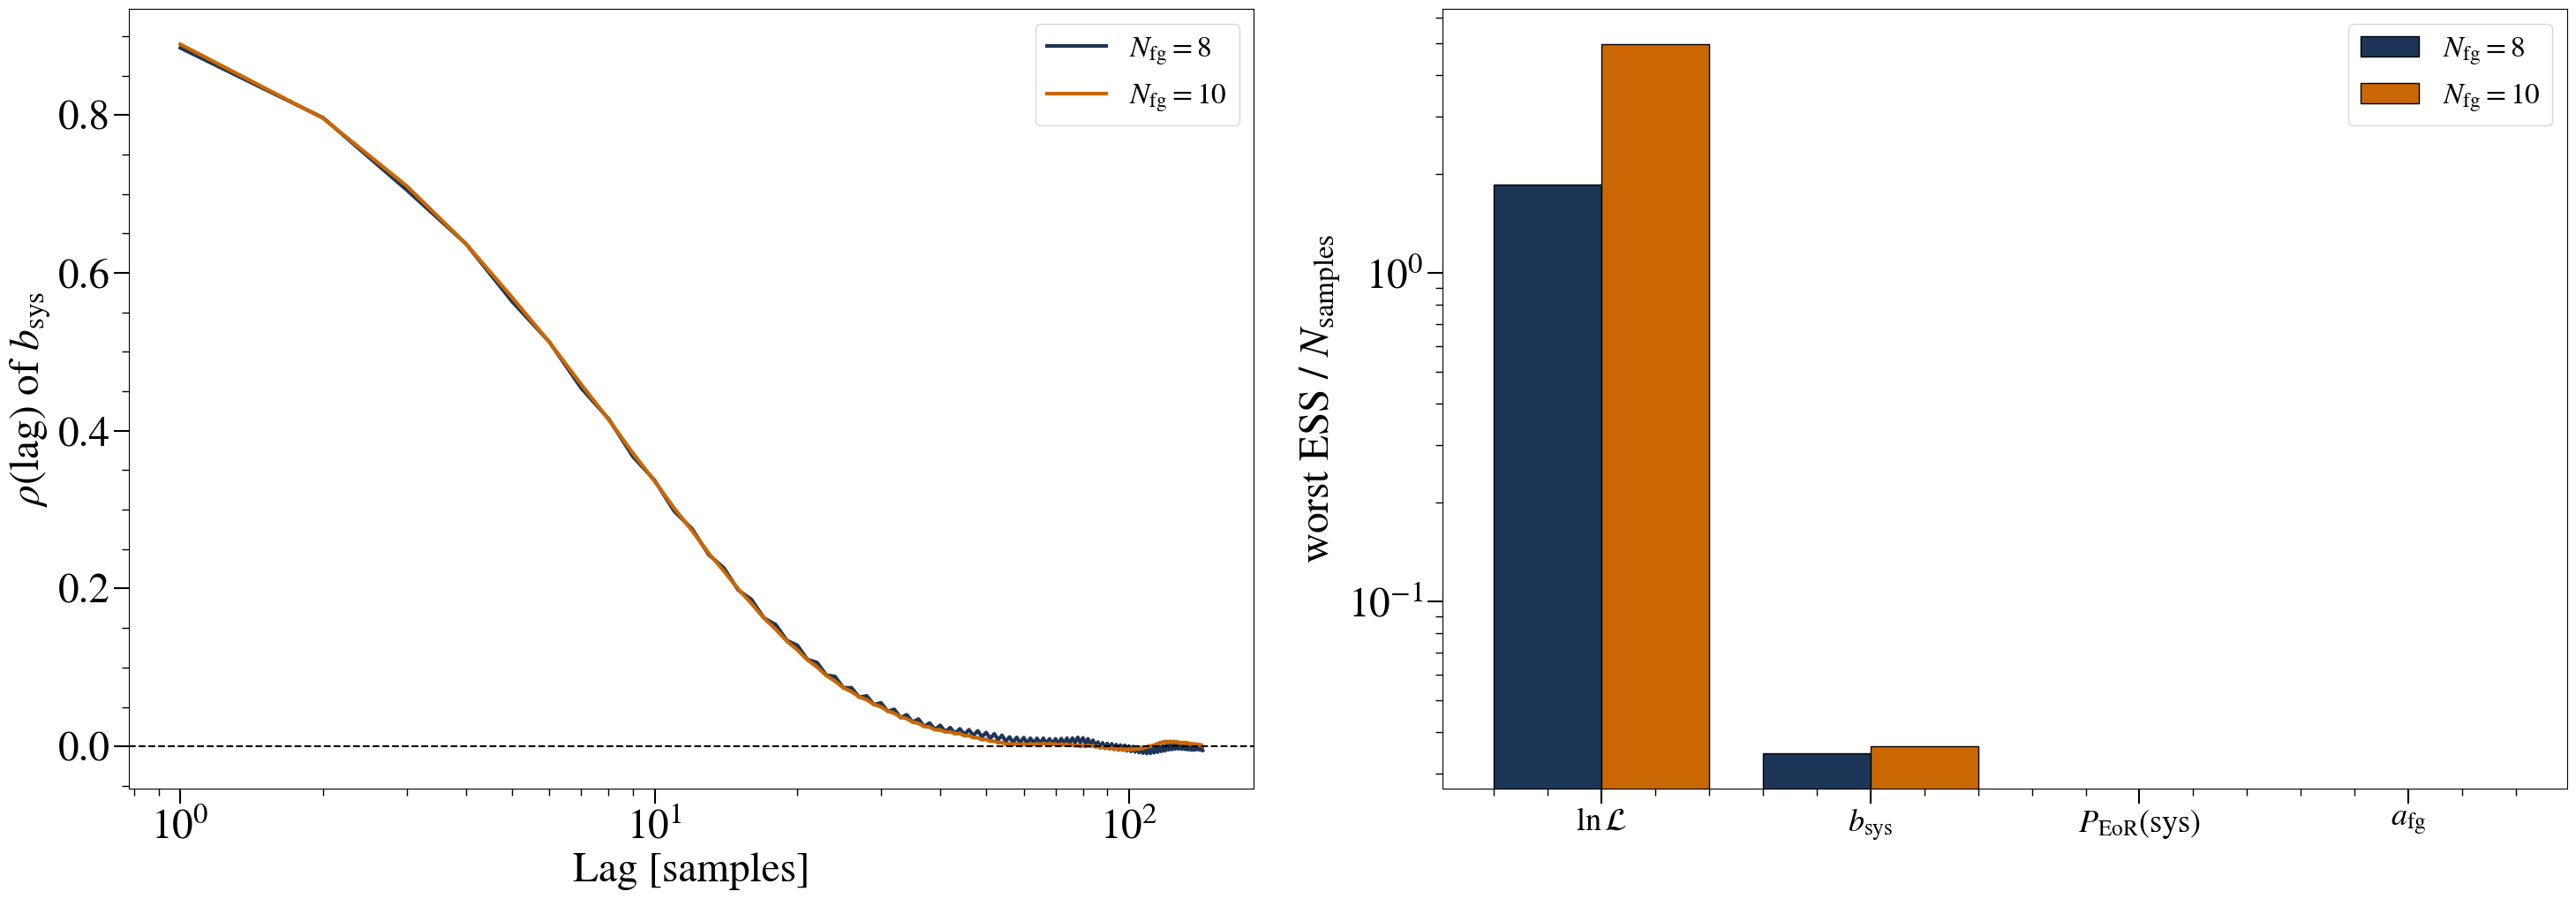

In [52]:
fig, axs = plt.subplots(1, 2, figsize=(30, 11))

# --------------- autocorrelation of b_sys ----------------
# Mean over the real and imaginary parts of all systematic amplitudes, so one
# curve per case summarises how fast that case forgets its previous sample.
maxlag = 1
acfs   = []
for i in range(Ncases):
    cols, _ = real_columns(conv_chains[i]['b_sys'], 'b')
    acf = np.mean([emcee.autocorr.function_1d(cols[:, k]) for k in range(cols.shape[1])], axis=0)
    acfs.append(acf)
    tau_max = _nanagg(np.nanmax, np.concatenate(
        [s['tau'] for s in conv_stats[i] if s['group'] == 'b_sys']))
    maxlag = max(maxlag, int(5 * tau_max) if np.isfinite(tau_max) else 100)
maxlag = int(np.clip(maxlag, 50, min(len(a) for a in acfs)))

for i, acf in enumerate(acfs):
    axs[0].plot(np.arange(1, maxlag), acf[1:maxlag], color=case_colors[i], lw=3,
                label=case_labels[i])
axs[0].axhline(0, color='k', ls='--', lw=1.5)
axs[0].set_xscale('log')       # the mixing times differ by orders of magnitude
axs[0].set_xlabel('Lag [samples]')
axs[0].set_ylabel(r'$\rho(\mathrm{lag})$ of $b_\mathrm{sys}$')
axs[0].legend(fontsize=24)

# --------------- efficiency per monitored block ----------------
groups = [conv_group_tex[s['group']] for s in conv_stats[0]]
xpos   = np.arange(len(groups))
width  = 0.8 / Ncases
for i in range(Ncases):
    vals = [_nanagg(np.nanmin, s['ess_frac']) for s in conv_stats[i]]
    axs[1].bar(xpos + (i - (Ncases - 1) / 2.) * width, vals, width,
               color=case_colors[i], edgecolor='k', label=case_labels[i])
axs[1].set_xticks(xpos)
axs[1].set_xticklabels(groups, fontsize=26)
axs[1].set_ylabel(r'worst ESS / $N_\mathrm{samples}$')
axs[1].set_yscale('log')
axs[1].legend(fontsize=24)

for ax in axs:
    ax.minorticks_on()
    ax.tick_params(which='major', direction='out', length=12, width=1.5)
    ax.tick_params(which='minor', direction='out', length=6, width=1.0)

plt.tight_layout()
save_fig('convergence_acf_ess_nfg.pdf')
print('b_sys autocorrelation and per-block efficiency, (C2/C3)')

---
### Figure C3: EoR power-spectrum efficiency per delay → `convergence_ess_dps_nfg.pdf`

Efficiency of the sampled EoR delay power spectrum, delay bin by delay bin.
The dotted lines and shaded band mark the delays occupied by the systematics,
where the degeneracy between the foreground model and the systematics model is
strongest and where mixing is therefore expected to be slowest.

  saved /nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures/nfgmodes/convergence_ess_dps_nfg.pdf
EoR delay-power-spectrum sampling efficiency, (C3/C3)


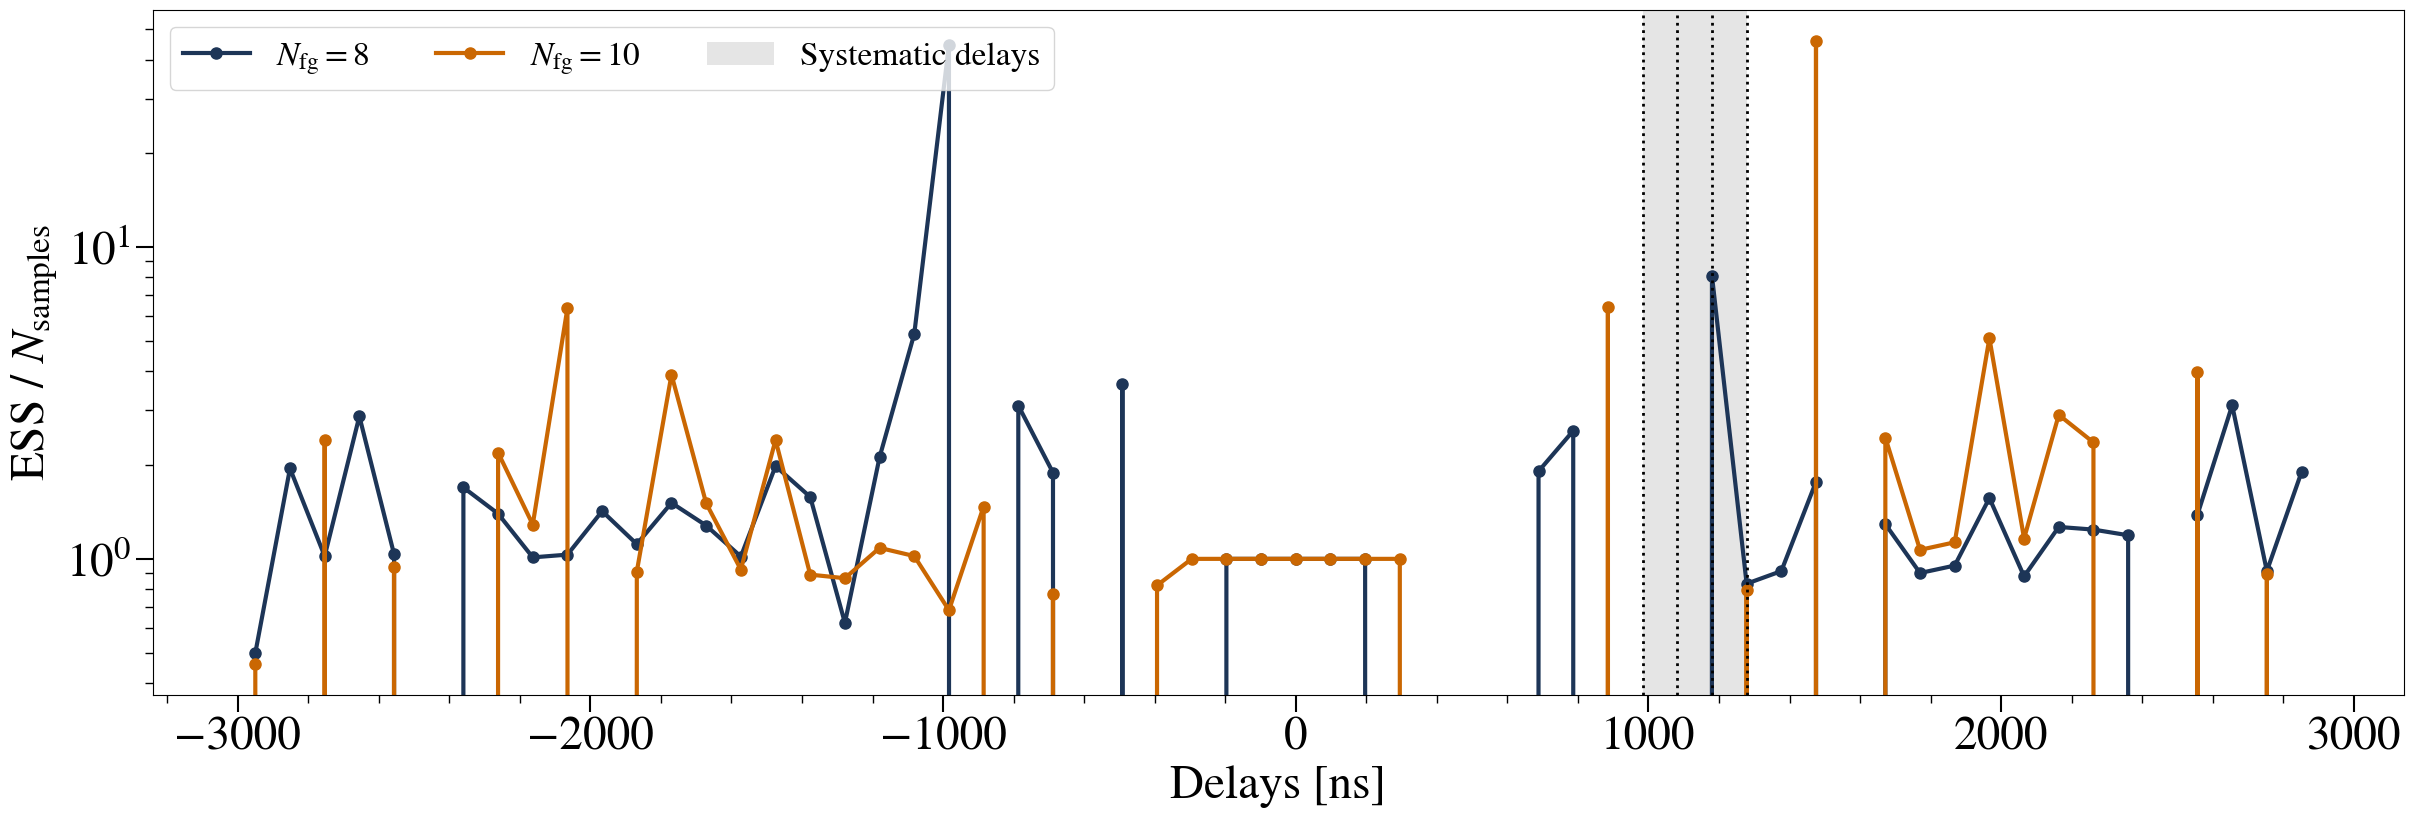

In [53]:
fig, ax = plt.subplots(1, 1, figsize=(25, 9))

_n_dps = np.array([Niter_all[i] - CONV_BURN for i in range(Ncases)], dtype=float)
for i in range(Ncases):
    ax.plot(delays.value, ess_dps_all[i] / _n_dps[i], marker='o', ms=8, lw=3,
            color=case_colors[i], label=case_labels[i])

for dl in delays_ns[sys_dl_idx_conv]:
    ax.axvline(dl, color='k', ls=':', lw=2)
ax.axvspan(delays_ns[sys_dl_idx_conv].min(), delays_ns[sys_dl_idx_conv].max(),
           facecolor='grey', alpha=0.2, zorder=0.1, label='Systematic delays')

ax.set_yscale('log')
ax.set_xlabel('Delays [ns]')
ax.set_ylabel(r'ESS / $N_\mathrm{samples}$')
ax.legend(fontsize=24, ncol=Ncases + 1)
ax.minorticks_on()
ax.tick_params(which='major', direction='out', length=12, width=1.5)
ax.tick_params(which='minor', direction='out', length=6, width=1.0)

plt.tight_layout()
save_fig('convergence_ess_dps_nfg.pdf')
print('EoR delay-power-spectrum sampling efficiency, (C3/C3)')

---
# Figure 8: FG–systematics Pearson correlation (all cases) → `fg_sys_corr_nfg.pdf`

Element-wise Pearson $r$ between the sampled foreground model and the sampled
gain $1 + \mathbf{Hb}_\mathrm{sys}$, in delay–fringe-rate space.  Increasing
`Nfgmodes` gives the foreground model more freedom to absorb systematic power,
which shows up here as stronger correlation at the systematic delays.

  saved /nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures/nfgmodes/fg_sys_corr_nfg.pdf
FG-systematics Pearson correlation, (8/9)


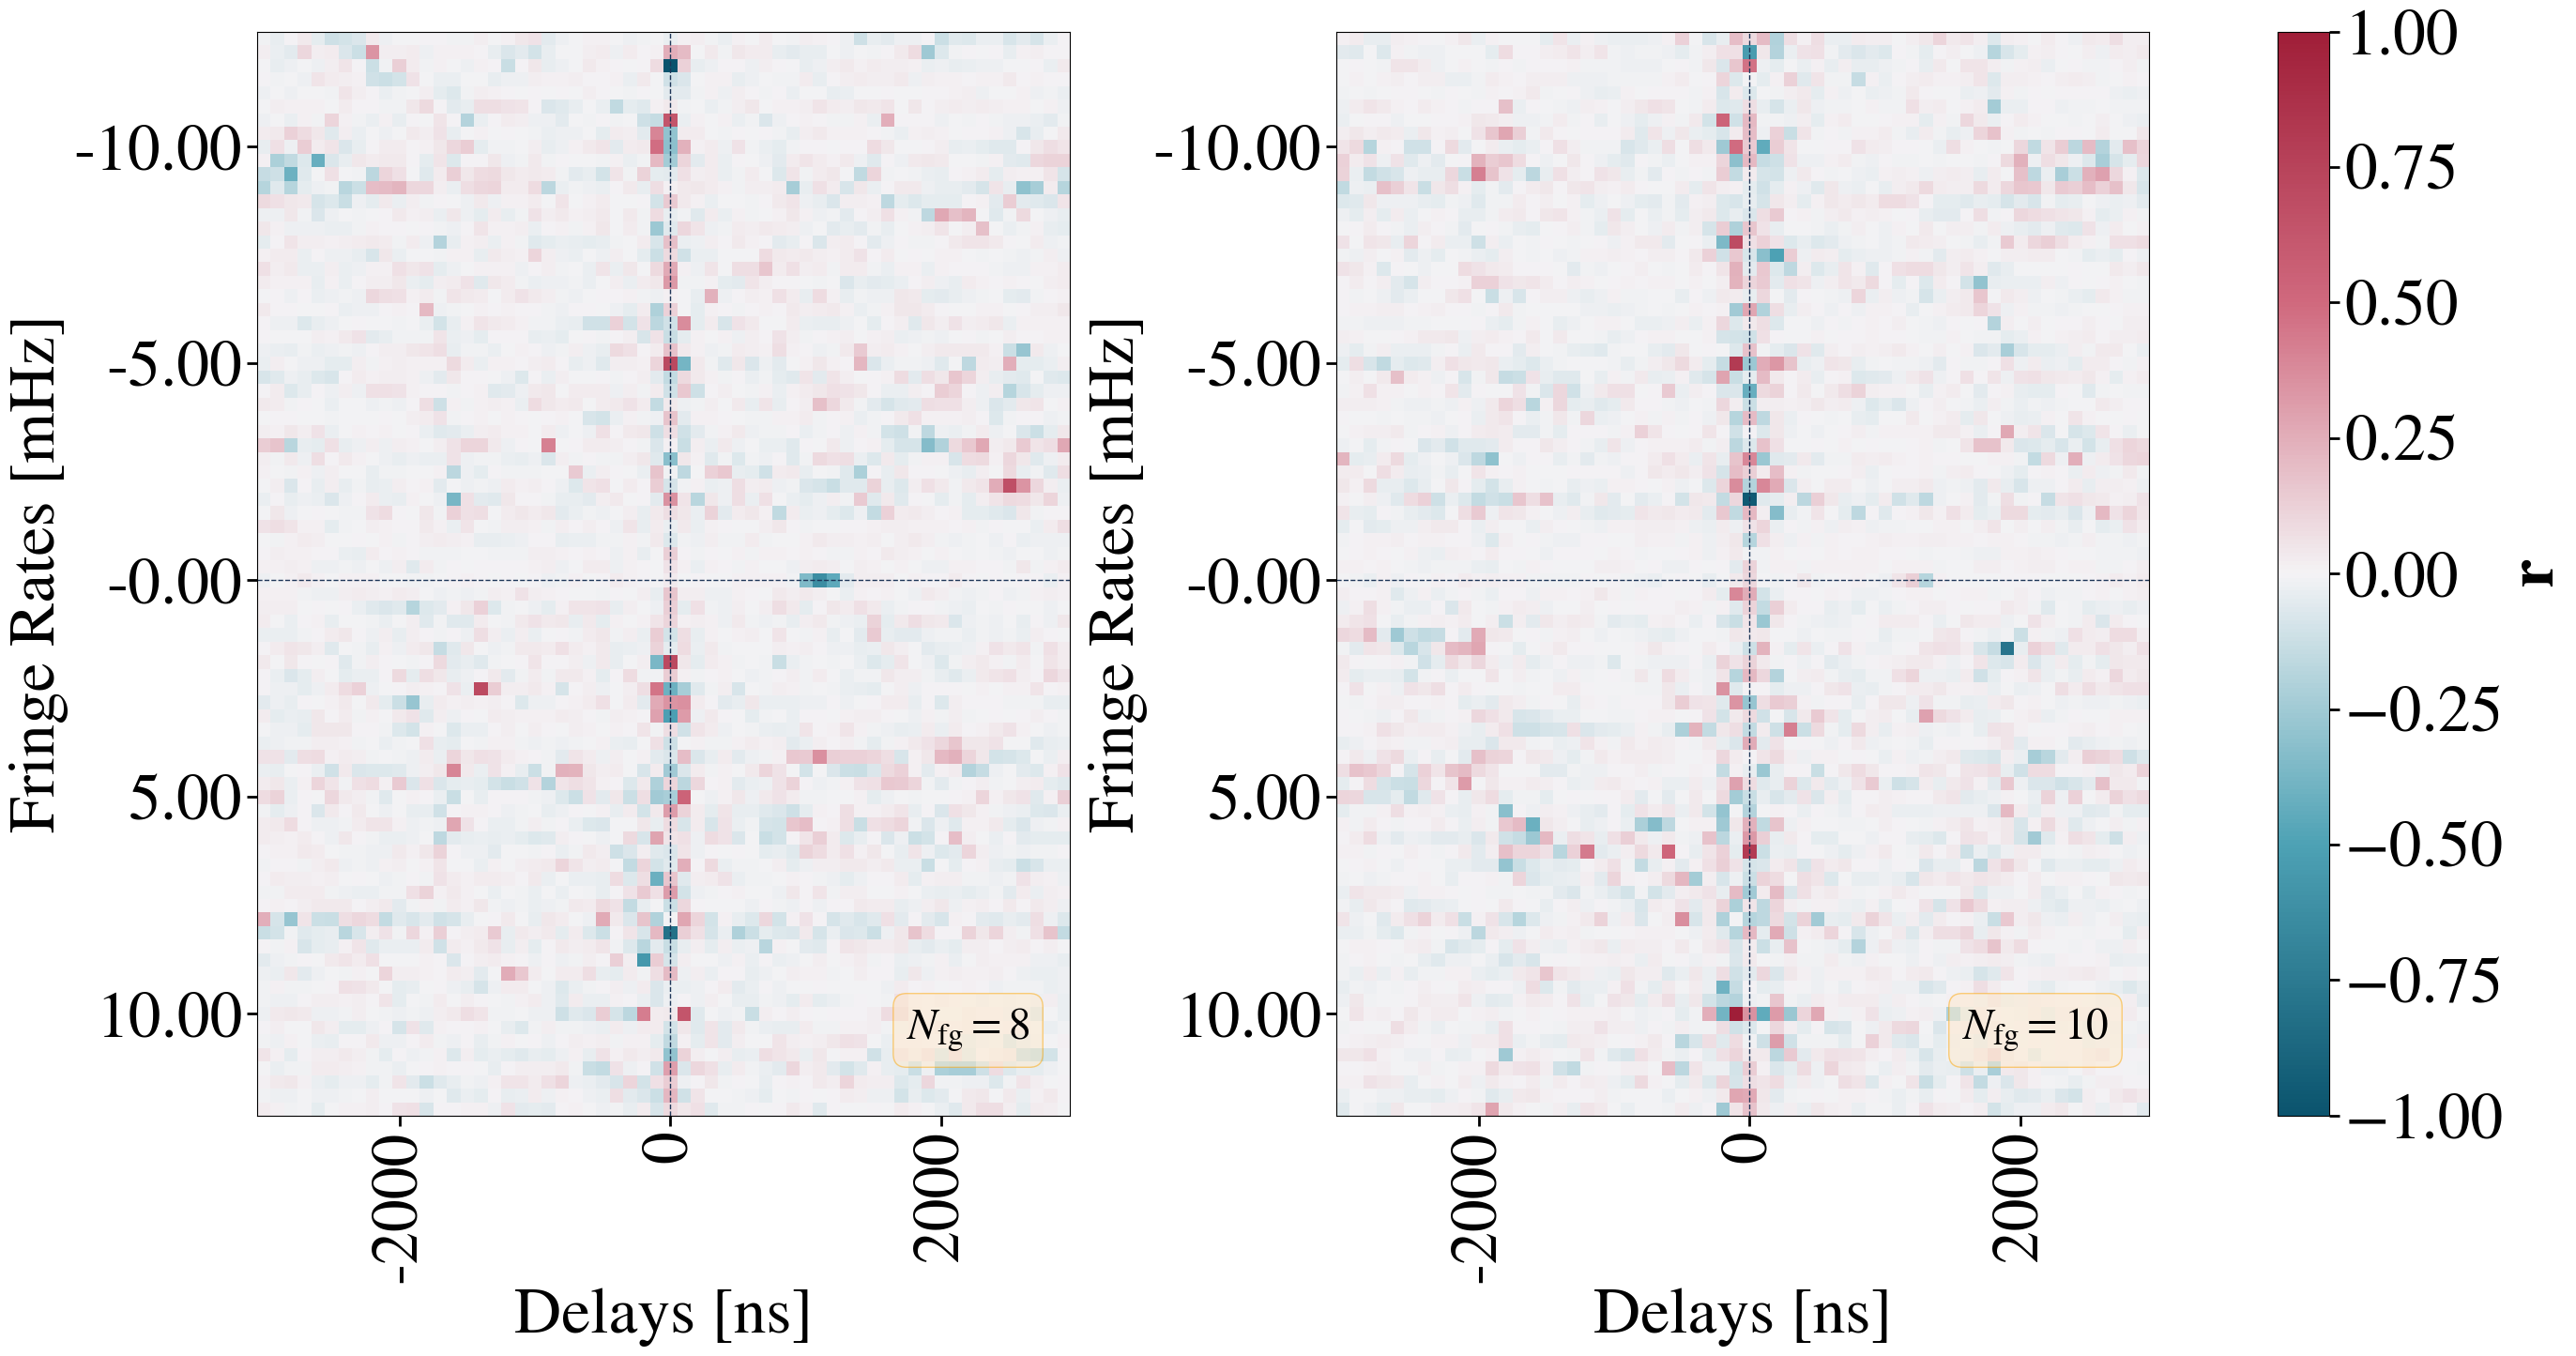

In [54]:
fig = plt.figure(figsize=(15. * Ncases, 15.))
axs = ImageGrid(
    fig, 111,
    nrows_ncols=(1, Ncases),
    axes_pad=0.5,
    share_all=True,
    label_mode='all',
    cbar_location='right',
    cbar_mode='single',
    cbar_size='5%',
    cbar_pad=0.2,
    aspect=False,
)

for i in range(Ncases):
    im = axs[i].imshow(corr_maps[i].real, cmap=paper_map, vmin=-1, vmax=1)
    axs[i].text(0.95, 0.07, case_labels[i], bbox=bbox,
                transform=axs[i].transAxes, horizontalalignment='right')

cbar = axs.cbar_axes[0].colorbar(im)
cbar.set_label(r'$\mathbf{r}$', size=50)
cbar.ax.tick_params(labelsize=50, length=8, width=2, colors='black')

for a in axs:
    a.set_xlabel('Delays [ns]', fontsize=50)
    a.set_ylabel('Fringe Rates [mHz]', fontsize=50)
    a.tick_params(direction='out', length=8, width=2, colors='black', labelsize=50)
    a.set_xticks(xticklocs_dl, labels=xticklabels_dl, rotation=90)
    a.set_yticks(yticklocs_fr, labels=yticklabels_fr)
    a.axvline(dl_zero, color=colors[0], linestyle='--', linewidth=1)
    a.axhline(fr_zero, color=colors[0], linestyle='--', linewidth=1)

save_fig('fg_sys_corr_nfg.pdf')
print("FG-systematics Pearson correlation, (8/9)")

---
# Figure 9: Parameter correlation matrices → `correlation_matrix_nfg.pdf`

$\langle a_\mathrm{fg}, b_\mathrm{sys}\rangle$ correlation matrices.  The
foreground block grows with `Nfgmodes`, so the matrices have different sizes
between panels; the dashed lines mark the FG / systematics block boundary.

  saved /nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures/nfgmodes/correlation_matrix_nfg.pdf
Correlation matrix, (9/9)


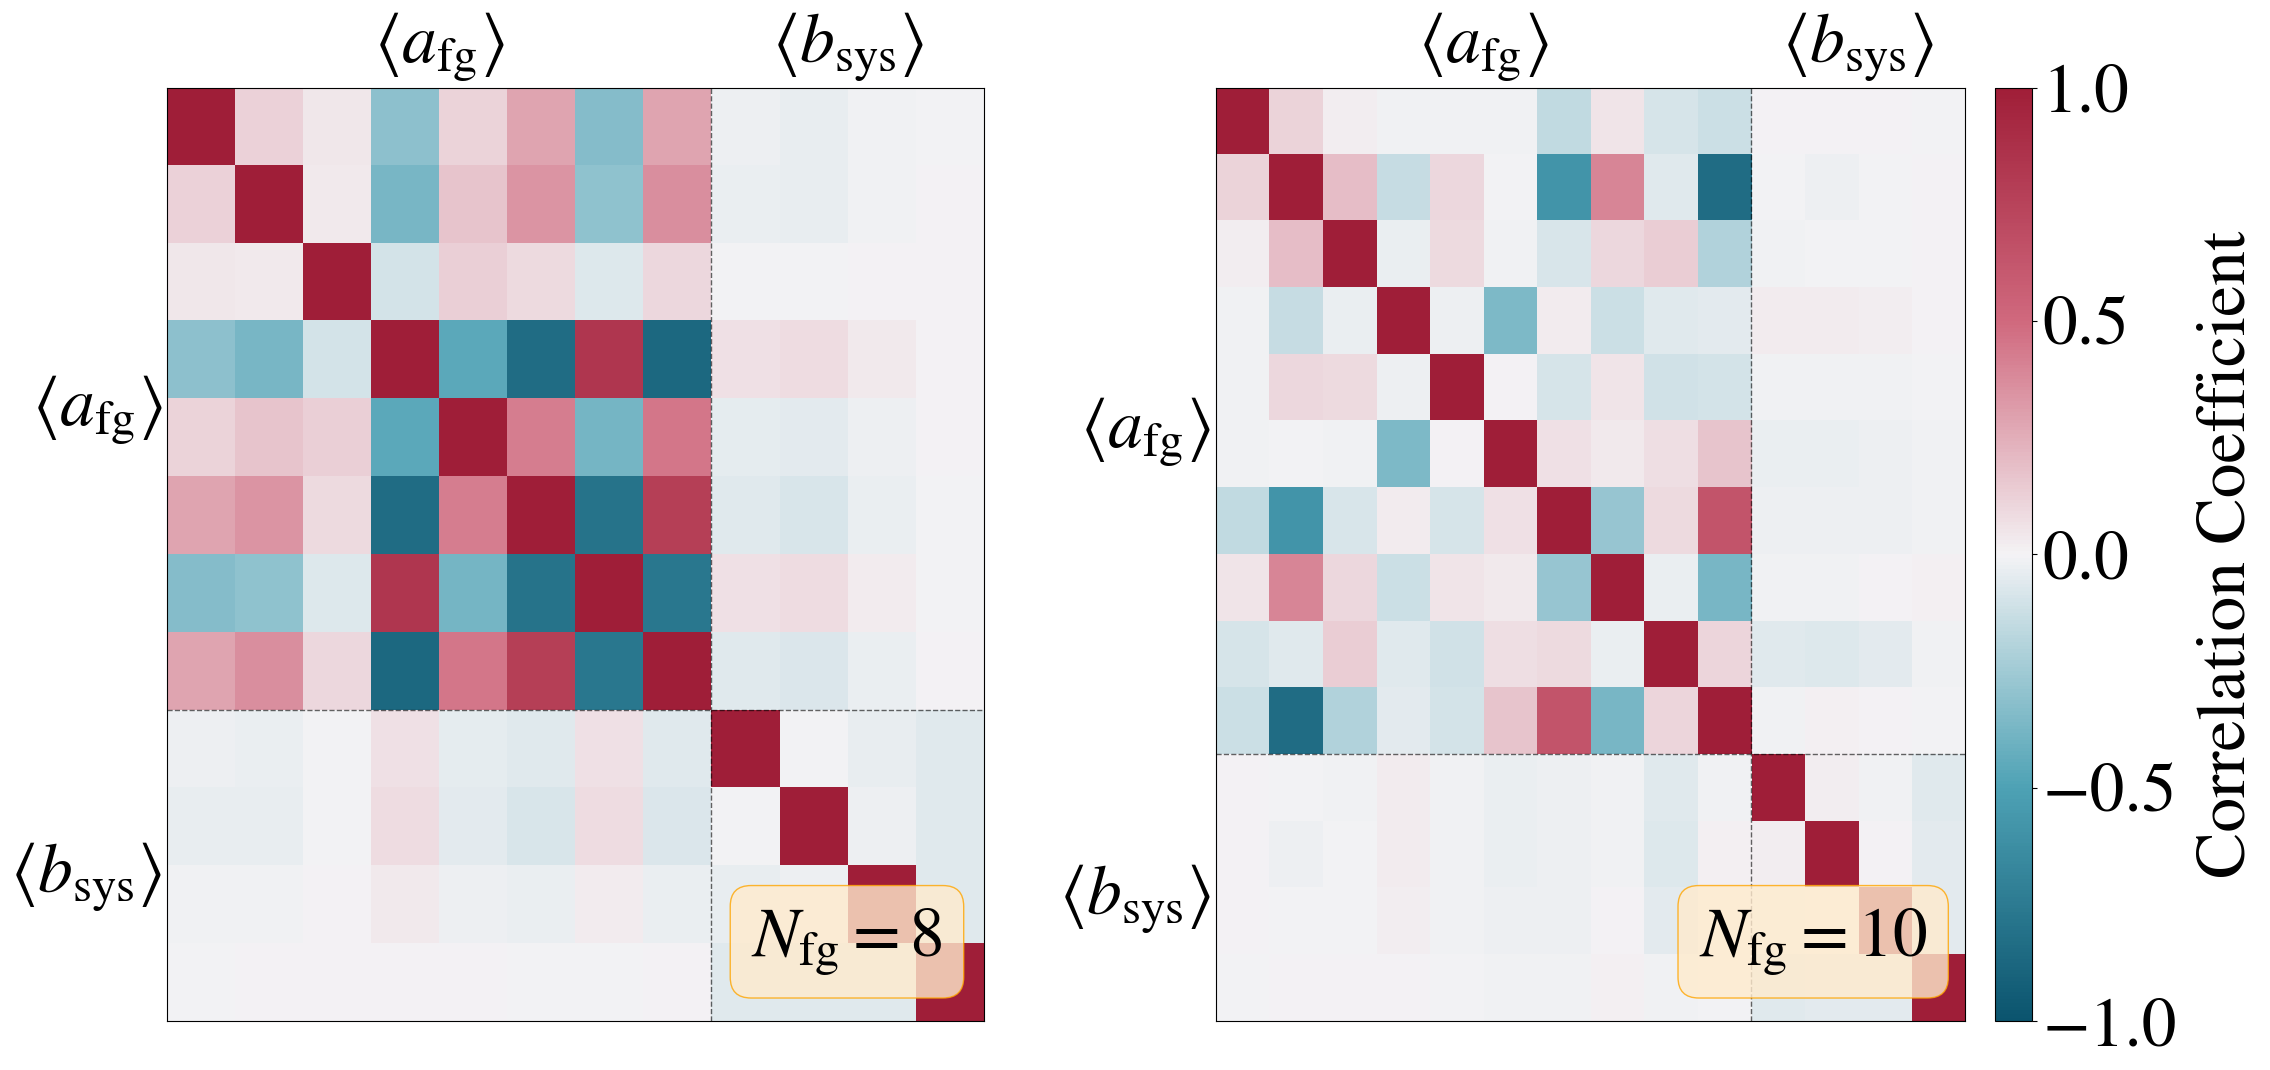

In [55]:
def plot_correlation_matrix(corr, ax, param_names, param_sizes, fontsize=40, cmap="RdBu"):
    """
    Plot a formatted correlation matrix into a given Axes object.

    Parameters
    ----------
    corr : np.ndarray, shape (N, N)
        Correlation matrix.
    ax : matplotlib.axes.Axes
        Axes to plot into.
    param_names : list of str
        Parameter block names, e.g. ['a_fg', 'b_sys'].
    param_sizes : list of int
        Number of elements per parameter block.
    cmap : str
        Colormap.

    Returns
    -------
    im : AxesImage
        The image object (used externally for the shared colorbar).
    """
    im = ax.matshow(corr, cmap=cmap, vmin=-1, vmax=1, aspect="auto", interpolation="none")

    # --- Block dividing lines ---
    boundaries = np.cumsum(param_sizes)[:-1] - 0.5
    for b in boundaries:
        ax.axhline(b, color="k", linewidth=1.0, linestyle="--", alpha=0.6)
        ax.axvline(b, color="k", linewidth=1.0, linestyle="--", alpha=0.6)

    # --- Block centre positions for labels ---
    centres = []
    start = 0
    for size in param_sizes:
        centres.append(start + size / 2 - 0.5)
        start += size

    ax.set_xticks(centres)
    ax.set_xticklabels([rf"$\langle {n} \rangle$" for n in param_names], fontsize=fontsize)
    ax.set_yticks(centres)
    ax.set_yticklabels([rf"$\langle {n} \rangle$" for n in param_names], fontsize=fontsize)
    ax.tick_params(length=0)

    return im


param_names = [r'a_\text{fg}', r'b_\text{sys}']

_font_size_backup = plt.rcParams['font.size']
plt.rcParams.update({'font.size': 50})

fig, axes = plt.subplots(1, Ncases, figsize=(12. * Ncases, 12.))
axes = np.atleast_1d(axes)

for i, ax in enumerate(axes):
    im = plot_correlation_matrix(
        corr        = corr_mats[i],
        ax          = ax,
        param_names = param_names,
        param_sizes = [Nfgmodes_arr[i], Nsysmodes],
        cmap        = paper_map,
        fontsize    = 50,
    )
    ax.text(0.95, 0.07, case_labels[i], bbox=bbox_res, transform=ax.transAxes,
            horizontalalignment='right')

# --- Colorbar anchored exactly to the last axes ---
divider = make_axes_locatable(axes[-1])
cax = divider.append_axes("right", size="5%", pad=0.3)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(label="Correlation Coefficient", fontsize=50, labelpad=15)
cax.yaxis.label.set_size(50)
cax.tick_params(labelsize=50)

fig.tight_layout()
save_fig('correlation_matrix_nfg.pdf')
plt.rcParams.update({'font.size': _font_size_backup})
print("Correlation matrix, (9/9)")

# Time elapsed

In [56]:
elapsed = time.time() - _notebook_start
hours, rem = divmod(elapsed, 3600)
mins, secs = divmod(rem, 60)
print(f"Total notebook runtime: {int(hours):02d}h {int(mins):02d}m {secs:.1f}s")

Total notebook runtime: 00h 15m 8.2s
